# Neural network: CyberGlove estàtic → Allegro Hand robot

Aquest notebook entrena una xarxa neuronal per predir els **16 joints del robot** a partir de les dades estàtiques del **CyberGlove**.

Cada mostra temporal de les gravacions estàtiques del guant és una entrada.  
La sortida és el vector fix del robot corresponent a aquella postura.

El pipeline fa:

1. Llegeix `A_*Stat*.yaml`.
2. Aplica l’ordre correcte del guant.
3. Normalitza el guant a 0–100 amb `AA_Rangs1.yaml`.
4. Normalitza el robot a 0–100 amb els seus joint limits.
5. Crea el dataset supervisat.
6. Entrena una xarxa neuronal.
7. Avalua l’error i genera plots.


In [1]:
import yaml
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


In [2]:
from pathlib import Path
import zipfile

# Nom del ZIP que has pujat a Colab
zip_path = Path("/content/TFM.zip")

# Carpeta on es descomprimirà
base_dir = Path("/content/TFM")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(base_dir)

print("ZIP descomprimit a:", base_dir)
print(list(base_dir.iterdir()))

ZIP descomprimit a: /content/TFM
[PosixPath('/content/TFM/CyberGlove_multi_moviments_0_100.ipynb'), PosixPath('/content/TFM/Static_glove_to_robot.ipynb'), PosixPath('/content/TFM/Moviments Ma Robot'), PosixPath('/content/TFM/Moviments guant'), PosixPath('/content/TFM/Movements_glove_to_robot.ipynb'), PosixPath('/content/TFM/CyberGlove_static_vs_robot_0_100.ipynb'), PosixPath('/content/TFM/Estatic Guant')]


In [3]:
glove_movements_dir = base_dir / "Moviments guant"
robot_movements_dir = base_dir / "Moviments Ma Robot"
glove_static_dir = base_dir / "Estatic Guant"

data_dir = glove_movements_dir
robot_data_dir = robot_movements_dir

glove_ranges_yaml_path = glove_movements_dir / "AA_Rangs1.yaml"

In [4]:
# ============================================================
# CONFIGURACIÓ
# ============================================================

data_dir = glove_static_dir
static_file_pattern = "A_*Stat*.yaml"
glove_ranges_yaml_path = glove_static_dir / "AA_Rangs1.yaml"

glove_value_key = "calib_deg"
clip_to_0_100 = True

# "all" = usa els 22 joints del guant
# "robot_common" = usa només els 16 joints comuns amb el robot
use_glove_joints = "all"

test_size = 0.20
random_state = 42

epochs = 120
batch_size = 64
learning_rate = 1e-3

output_dir = Path("nn_static_glove_to_robot")
output_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})


In [5]:
# ============================================================
# ORDRES DE JOINTS
# ============================================================

glove_joint_order = [
    "Thumb j1", "Thumb j2", "Thumb j3", "Thumb j0",
    "Index j1", "Index j2", "Index j3",
    "Middle j1", "Middle j2", "Middle j3",
    "Index j0",
    "Annular j1", "Annular j2", "Annular j3", "Annular j0",
    "Pinky j1", "Pinky j2", "Pinky j3", "Pinky j0",
    "Middle j0",
    "Wrist j1", "Wrist j0",
]

robot_joint_order = [
    "Index j0", "Index j1", "Index j2", "Index j3",
    "Middle j0", "Middle j1", "Middle j2", "Middle j3",
    "Annular j0", "Annular j1", "Annular j2", "Annular j3",
    "Thumb j0", "Thumb j1", "Thumb j2", "Thumb j3",
]


In [6]:
# ============================================================
# LIMITS DEL ROBOT
# ============================================================

robot_joint_limits = {
    "Index j0":   {"min": -0.596932, "max": 0.588071},
    "Index j1":   {"min": -0.284220, "max": 1.798060},
    "Index j2":   {"min": -0.277444, "max": 1.772960},
    "Index j3":   {"min": -0.282001, "max": 1.760870},

    "Middle j0":  {"min": -0.596932, "max": 0.588071},
    "Middle j1":  {"min": -0.284220, "max": 1.798060},
    "Middle j2":  {"min": -0.277444, "max": 1.772960},
    "Middle j3":  {"min": -0.282001, "max": 1.760870},

    "Annular j0": {"min": -0.596932, "max": 0.588071},
    "Annular j1": {"min": -0.284220, "max": 1.798060},
    "Annular j2": {"min": -0.277444, "max": 1.772960},
    "Annular j3": {"min": -0.282001, "max": 1.760870},

    "Thumb j0":   {"min":  0.218668, "max": 1.532940},
    "Thumb j1":   {"min": -0.396993, "max": 1.202960},
    "Thumb j2":   {"min": -0.251244, "max": 1.767010},
    "Thumb j3":   {"min": -0.260209, "max": 1.822620},
}


In [7]:
# ============================================================
# VALORS ESTÀTICS DEL ROBOT
# Ordre: index, middle, annular, thumb. 4 joints per dit.
# ============================================================

robot_static_values = {
    "BotiStat": [
        -0.11920892271473398, 1.6322657332846189, 1.3367731765330555, -0.23859537174773263,
        0.051837684933287151, -0.033996289947686609, 0.067460000940579162, -0.10775847518666198,
        0.028581737240613806, 1.6352836806951185, 1.2426842278527741, -0.076336316853813271,
        0.7574160368762658, 1.1809938322557971, 0.48393674358952321, 0.80907619549128829,
    ],
    "OneStat": [
        -0.14770189679621545, 0.013847052824645198, 0.019084079213453318, -0.23815155595207094,
        -0.0039943421609553451, 1.634662338581192, 1.7225378661222095, -0.069146500964093652,
        0.05157139545589013, 1.6354612070133832, 1.7128626817767847, 0.085035106448782691,
        0.30898455693967908, 1.1881836481455168, 1.1271145946624663, 1.7288400504206061,
    ],
    "PaperStat": [
        -0.018817789736056297, -0.018906552895188639, 0.013580763347248176, -0.0064797106166608939,
        0.0060358948209991888, -0.013403237028983493, 0.017131289712541815, -0.012160552801130717,
        0.013669526506380517, -0.017131289712541815, -0.0060358948209991888, 0.21107879241670693,
        0.26069739837168554, 0.013935815983777538, -0.0066572369349255757, -0.0040831053200876865,
    ],
    "RockStat": [
        0.048109632249728827, 1.6376802859916917, 1.7201412608256366, -0.14361879147612777,
        0.0041718684792200278, 1.6316443911706926, 1.7349647084007374, -0.052902842842875247,
        -0.090627185474120173, 1.6351061543768537, 1.6043053381579315, 0.16501071282702195,
        0.26060863521255323, 0.037546816312980243, 1.605991838181446, 0.08583397488097376,
    ],
    "ScisStat": [
        -0.0088763159132341004, -0.20708445025575159, 0.21045745030278054, -0.22625729262833724,
        -0.0024853684557055483, -0.20681816077835455, 0.021303158191761842, -0.15719955482337594,
        -0.090715948633252524, 1.6355499701725154, 1.6079446276823575, 0.16518823914528663,
        1.0613410937454015, 1.1914678850334135, 0.84857580130518007, 1.0823779624597663,
    ],
    "ThumbUpStat": [
        0.13101442287933532, 1.6324432596028835, 1.4069848354067374, 1.6423847334257058,
        0.041186105837406228, 1.6349286280585891, 1.4048545195875612, 1.6397218386517356,
        -0.0039943421609553451, 1.6281826279645313, 1.5425261794018221, 1.4421350464231446,
        0.26291647734999407, -0.083703659061797581, 0.21471808194113293, 0.032132263605907443,
    ],
}

static_position_names = {
    "BotiStat": "Botifarra",
    "OneStat": "One",
    "PaperStat": "Paper",
    "RockStat": "Rock",
    "ScisStat": "Scissors",
    "ThumbUpStat": "Thumb Up",
}


In [8]:
# ============================================================
# FUNCIONS
# ============================================================

def parse_static_file(path):
    match = re.match(r"A_(BotiStat|OneStat|PaperStat|RockStat|ScisStat|ThumbUpStat)(\d+)\.ya?ml$", path.name)
    if not match:
        return None
    pos = match.group(1)
    version = int(match.group(2))
    return {
        "position_code": pos,
        "position_name": static_position_names[pos],
        "version": version,
        "label": f"{pos}{version}",
        "path": path,
        "file": path.name,
    }


def find_static_files(data_dir, pattern):
    rows = []
    for path in sorted(data_dir.glob(pattern)):
        parsed = parse_static_file(path)
        if parsed:
            rows.append(parsed)
    if not rows:
        raise FileNotFoundError(f"No s'han trobat fitxers amb patró {pattern}")
    return pd.DataFrame(rows)


def load_glove_ranges(path, value_key):
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if value_key == "calib_deg":
        min_key, max_key = "calib_min_deg", "calib_max_deg"
    elif value_key == "raw_deg":
        min_key, max_key = "raw_min_deg", "raw_max_deg"
    elif value_key == "calib_rad":
        min_key, max_key = "calib_min_rad", "calib_max_rad"
    elif value_key == "raw_rad":
        min_key, max_key = "raw_min_rad", "raw_max_rad"
    else:
        raise ValueError(value_key)

    ranges = {}
    for s in data["sensor_range"]["sensors"]:
        ranges[s["name"]] = {"min": s[min_key], "max": s[max_key]}
    return ranges


def load_glove_yaml(path, value_key):
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    rows = []
    for sample in data["recording"]["samples"]:
        values = sample[value_key]
        if len(values) != len(glove_joint_order):
            raise ValueError(f"{path.name}: {len(values)} valors, però s'esperen {len(glove_joint_order)}")
        row = {"t": sample["t"]}
        for i, joint in enumerate(glove_joint_order):
            row[joint] = values[i]
        rows.append(row)

    return pd.DataFrame(rows), data["recording"]


def norm_value(value, q_min, q_max, clip=True):
    if q_max == q_min:
        return np.nan
    out = (value - q_min) / (q_max - q_min) * 100
    return np.clip(out, 0, 100) if clip else out


def norm_dataframe(df, ranges, joints, clip=True):
    out = pd.DataFrame(index=df.index)
    out["t"] = df["t"]
    for joint in joints:
        q_min = ranges[joint]["min"]
        q_max = ranges[joint]["max"]
        out[joint] = (df[joint] - q_min) / (q_max - q_min) * 100
        if clip:
            out[joint] = out[joint].clip(0, 100)
    return out


def norm_robot_vector(values, clip=True):
    out = []
    for joint, value in zip(robot_joint_order, values):
        q_min = robot_joint_limits[joint]["min"]
        q_max = robot_joint_limits[joint]["max"]
        out.append(norm_value(value, q_min, q_max, clip))
    return np.array(out, dtype=float)


In [9]:
# ============================================================
# CREACIÓ DEL DATASET
# ============================================================

files_df = find_static_files(data_dir, static_file_pattern)
glove_ranges = load_glove_ranges(glove_ranges_yaml_path, glove_value_key)

if use_glove_joints == "all":
    input_joints = glove_joint_order
elif use_glove_joints == "robot_common":
    input_joints = [j for j in robot_joint_order if j in glove_joint_order]
else:
    raise ValueError("use_glove_joints ha de ser 'all' o 'robot_common'")

X_list = []
Y_list = []
meta_rows = []

for _, row in files_df.iterrows():
    pos = row["position_code"]

    if pos not in robot_static_values:
        continue

    df_raw, recording = load_glove_yaml(row["path"], glove_value_key)
    df_norm = norm_dataframe(df_raw, glove_ranges, glove_joint_order, clip_to_0_100)

    x = df_norm[input_joints].to_numpy(dtype=float)
    y_target = norm_robot_vector(robot_static_values[pos], clip_to_0_100)
    y = np.tile(y_target, (len(x), 1))

    X_list.append(x)
    Y_list.append(y)

    for i in range(len(x)):
        meta_rows.append({
            "file": row["file"],
            "label": row["label"],
            "position_code": pos,
            "position_name": row["position_name"],
            "version": row["version"],
            "sample_index": i,
            "t": df_norm["t"].iloc[i],
        })

X = np.vstack(X_list)
Y = np.vstack(Y_list)
meta_df = pd.DataFrame(meta_rows)

valid = ~np.isnan(X).any(axis=1) & ~np.isnan(Y).any(axis=1)
X = X[valid]
Y = Y[valid]
meta_df = meta_df.loc[valid].reset_index(drop=True)

print("Dataset creat")
print("Mostres:", X.shape[0])
print("Inputs:", X.shape[1], input_joints)
print("Outputs:", Y.shape[1], robot_joint_order)
print("Fitxers:", files_df['file'].tolist())

pd.DataFrame(X, columns=input_joints).head()


Dataset creat
Mostres: 23123
Inputs: 22 ['Thumb j1', 'Thumb j2', 'Thumb j3', 'Thumb j0', 'Index j1', 'Index j2', 'Index j3', 'Middle j1', 'Middle j2', 'Middle j3', 'Index j0', 'Annular j1', 'Annular j2', 'Annular j3', 'Annular j0', 'Pinky j1', 'Pinky j2', 'Pinky j3', 'Pinky j0', 'Middle j0', 'Wrist j1', 'Wrist j0']
Outputs: 16 ['Index j0', 'Index j1', 'Index j2', 'Index j3', 'Middle j0', 'Middle j1', 'Middle j2', 'Middle j3', 'Annular j0', 'Annular j1', 'Annular j2', 'Annular j3', 'Thumb j0', 'Thumb j1', 'Thumb j2', 'Thumb j3']
Fitxers: ['A_BotiStat1.yaml', 'A_BotiStat2.yaml', 'A_BotiStat3.yaml', 'A_OneStat1.yaml', 'A_OneStat2.yaml', 'A_OneStat3.yaml', 'A_PaperStat1.yaml', 'A_PaperStat2.yaml', 'A_PaperStat3.yaml', 'A_RockStat1.yaml', 'A_RockStat2.yaml', 'A_RockStat3.yaml', 'A_ScisStat1.yaml', 'A_ScisStat2.yaml', 'A_ScisStat3.yaml', 'A_ThumbUpStat1.yaml', 'A_ThumbUpStat2.yaml', 'A_ThumbUpStat3.yaml']


,Thumb j1,Thumb j2,Thumb j3,Thumb j0,Index j1,Index j2,Index j3,Middle j1,Middle j2,Middle j3,...,Annular j2,Annular j3,Annular j0,Pinky j1,Pinky j2,Pinky j3,Pinky j0,Middle j0,Wrist j1,Wrist j0
0,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
1,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
2,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
3,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
4,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0


In [10]:
# ============================================================
# TRAIN / TEST
# ============================================================

idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size=test_size,
    random_state=random_state,
    stratify=meta_df["position_code"],
)

X_train, X_test = X[idx_train], X[idx_test]
Y_train, Y_test = Y[idx_train], Y[idx_test]
meta_train = meta_df.iloc[idx_train].reset_index(drop=True)
meta_test = meta_df.iloc[idx_test].reset_index(drop=True)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

print("Train:", X_train_s.shape, Y_train.shape)
print("Test:", X_test_s.shape, Y_test.shape)


Train: (18498, 22) (18498, 16)
Test: (4625, 22) (4625, 16)


In [11]:
# ============================================================
# MODEL
# ============================================================

def build_model(input_dim, output_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.10),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.10),
        layers.Dense(32, activation="relu"),
        layers.Dense(output_dim, activation="linear"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model

model = build_model(X_train_s.shape[1], Y_train.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,576 (56.94 KB)

 Trainable params: 14,192 (55.44 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# ============================================================
# ENTRENAMENT
# ============================================================

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
]

history = model.fit(
    X_train_s,
    Y_train,
    validation_split=0.20,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1903.3370 - mae: 32.9502 - val_loss: 388.2741 - val_mae: 15.0661 - learning_rate: 0.0010
Epoch 2/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 219.2818 - mae: 10.9086 - val_loss: 88.8647 - val_mae: 6.3644 - learning_rate: 0.0010
Epoch 3/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 90.2310 - mae: 6.9905 - val_loss: 14.5699 - val_mae: 3.0582 - learning_rate: 0.0010
Epoch 4/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 47.2223 - mae: 5.0354 - val_loss: 5.5024 - val_mae: 1.7775 - learning_rate: 0.0010
Epoch 5/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 38.2660 - mae: 4.4909 - val_loss: 4.5588 - val_mae: 1.4421 - learning_rate: 0.0010
Epoch 6/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 33.7003 - mae: 4.1986 - val_loss: 4.6330 - val_mae: 1.5686 - learning_rate: 0.0010
Epoch 7/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30.5525 - mae: 3.9937 - val_loss: 2.3871 - val_mae: 1.0661 - lear

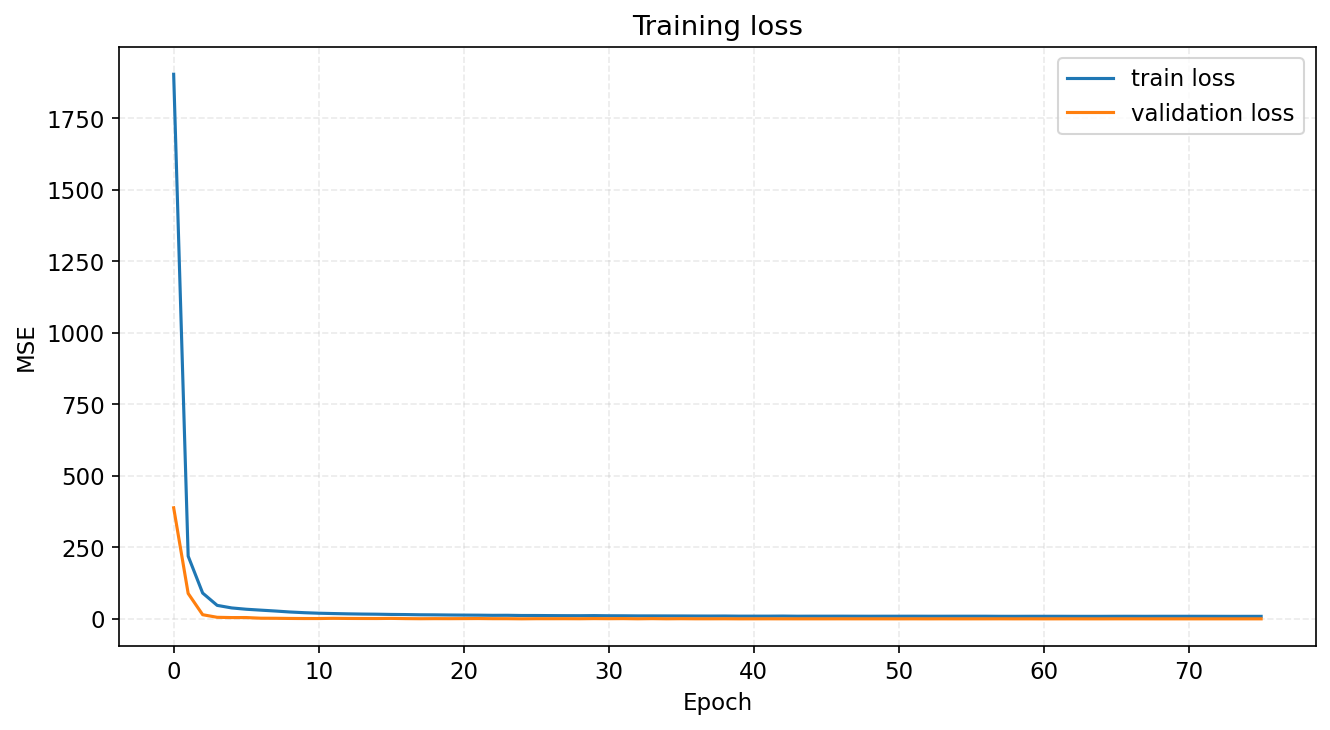

In [13]:
# ============================================================
# PLOT TRAINING LOSS
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="validation loss")
ax.set_title("Training loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "training_loss.png", bbox_inches="tight")
plt.show()


In [14]:
# ============================================================
# AVALUACIÓ
# ============================================================

Y_pred = model.predict(X_test_s)

mae_global = mean_absolute_error(Y_test, Y_pred)
rmse_global = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"MAE global:  {mae_global:.3f} punts sobre 0–100")
print(f"RMSE global: {rmse_global:.3f} punts sobre 0–100")

rows = []
for j, joint in enumerate(robot_joint_order):
    y_true = Y_test[:, j]
    y_pred = Y_pred[:, j]
    rows.append({
        "joint": joint,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if np.std(y_true) > 0 else np.nan,
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(output_dir / "metrics_by_robot_joint.csv", index=False)
metrics_df.sort_values("MAE", ascending=False)


145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE global:  0.237 punts sobre 0–100
RMSE global: 0.324 punts sobre 0–100


,joint,MAE,RMSE,R2
13,Thumb j1,0.334762,0.437324,0.999864
6,Middle j2,0.330236,0.424430,0.999882
5,Middle j1,0.322397,0.402472,0.999905
2,Index j2,0.300405,0.396391,0.999871
1,Index j1,0.299468,0.472068,0.999868
15,Thumb j3,0.266779,0.290803,0.999912
8,Annular j0,0.266156,0.355459,0.994316
12,Thumb j0,0.263460,0.361225,0.999770
9,Annular j1,0.245854,0.335339,0.999871
14,Thumb j2,0.239915,0.268257,0.999903


In [15]:
# ============================================================
# RESULTATS PER POSICIÓ
# ============================================================

pred_df = meta_test.copy()

for j, joint in enumerate(robot_joint_order):
    pred_df[f"true_{joint}"] = Y_test[:, j]
    pred_df[f"pred_{joint}"] = Y_pred[:, j]
    pred_df[f"error_{joint}"] = Y_pred[:, j] - Y_test[:, j]

position_rows = []

for pos, group in pred_df.groupby("position_code"):
    for joint in robot_joint_order:
        y_true = group[f"true_{joint}"].to_numpy()
        y_pred = group[f"pred_{joint}"].to_numpy()
        position_rows.append({
            "position_code": pos,
            "position_name": static_position_names[pos],
            "joint": joint,
            "true_mean": y_true.mean(),
            "pred_mean": y_pred.mean(),
            "pred_std": y_pred.std(),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        })

position_metrics_df = pd.DataFrame(position_rows)
position_metrics_df.to_csv(output_dir / "metrics_by_position_and_joint.csv", index=False)
position_metrics_df.sort_values(["position_code", "MAE"], ascending=[True, False]).head(30)


,position_code,position_name,joint,true_mean,pred_mean,pred_std,MAE,RMSE
1,BotiStat,Botifarra,Index j1,92.037850,93.124535,0.130719,1.086682,1.094516
13,BotiStat,Botifarra,Thumb j1,98.627074,99.468987,0.098171,0.841911,0.847615
2,BotiStat,Botifarra,Index j2,78.726786,79.567787,0.130663,0.840997,0.851087
9,BotiStat,Botifarra,Annular j1,92.182784,92.847763,0.141383,0.664976,0.679840
12,BotiStat,Botifarra,Thumb j0,40.992126,41.637463,0.044522,0.645340,0.646874
6,BotiStat,Botifarra,Middle j2,16.821270,16.392656,0.106616,0.428613,0.441674
4,BotiStat,Botifarra,Middle j0,54.748358,55.086941,0.088547,0.338582,0.349970
11,BotiStat,Botifarra,Annular j3,10.067434,9.738454,0.084623,0.328980,0.339690
15,BotiStat,Botifarra,Thumb j3,51.338117,51.664974,0.070855,0.326858,0.334450
8,BotiStat,Botifarra,Annular j0,52.785836,53.012058,0.097556,0.226220,0.246359


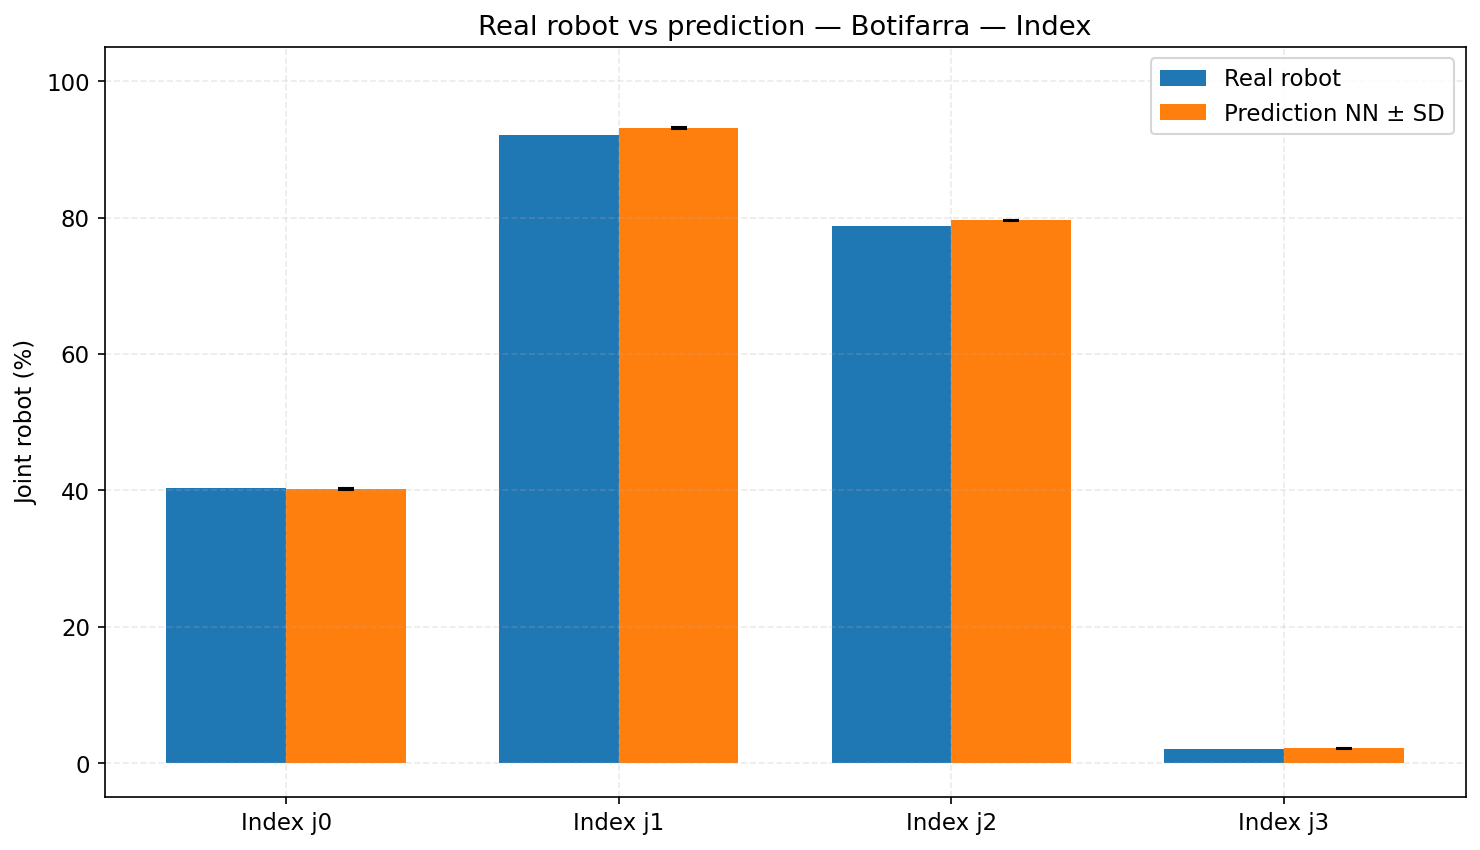

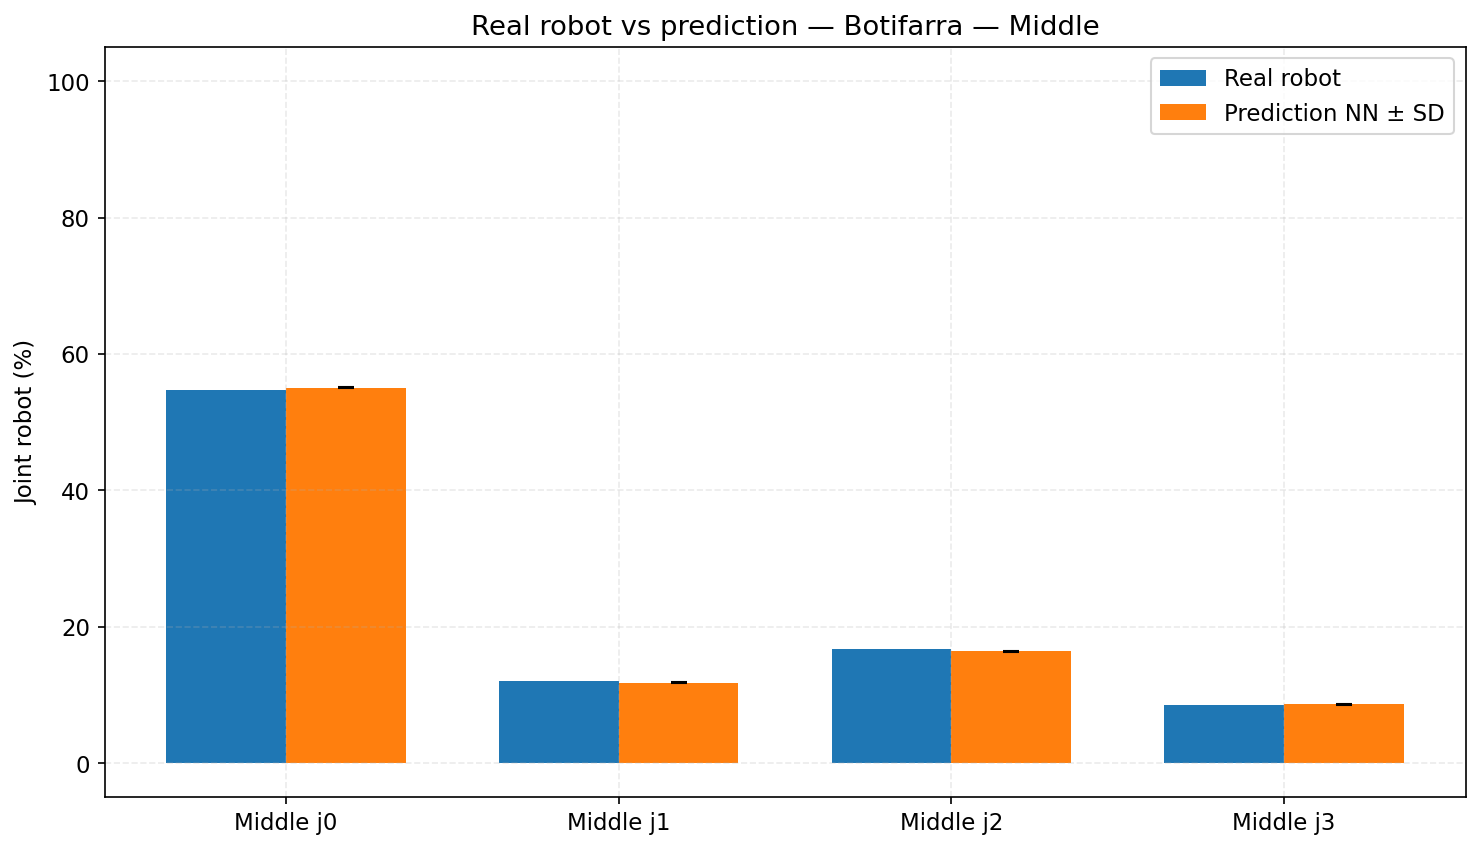

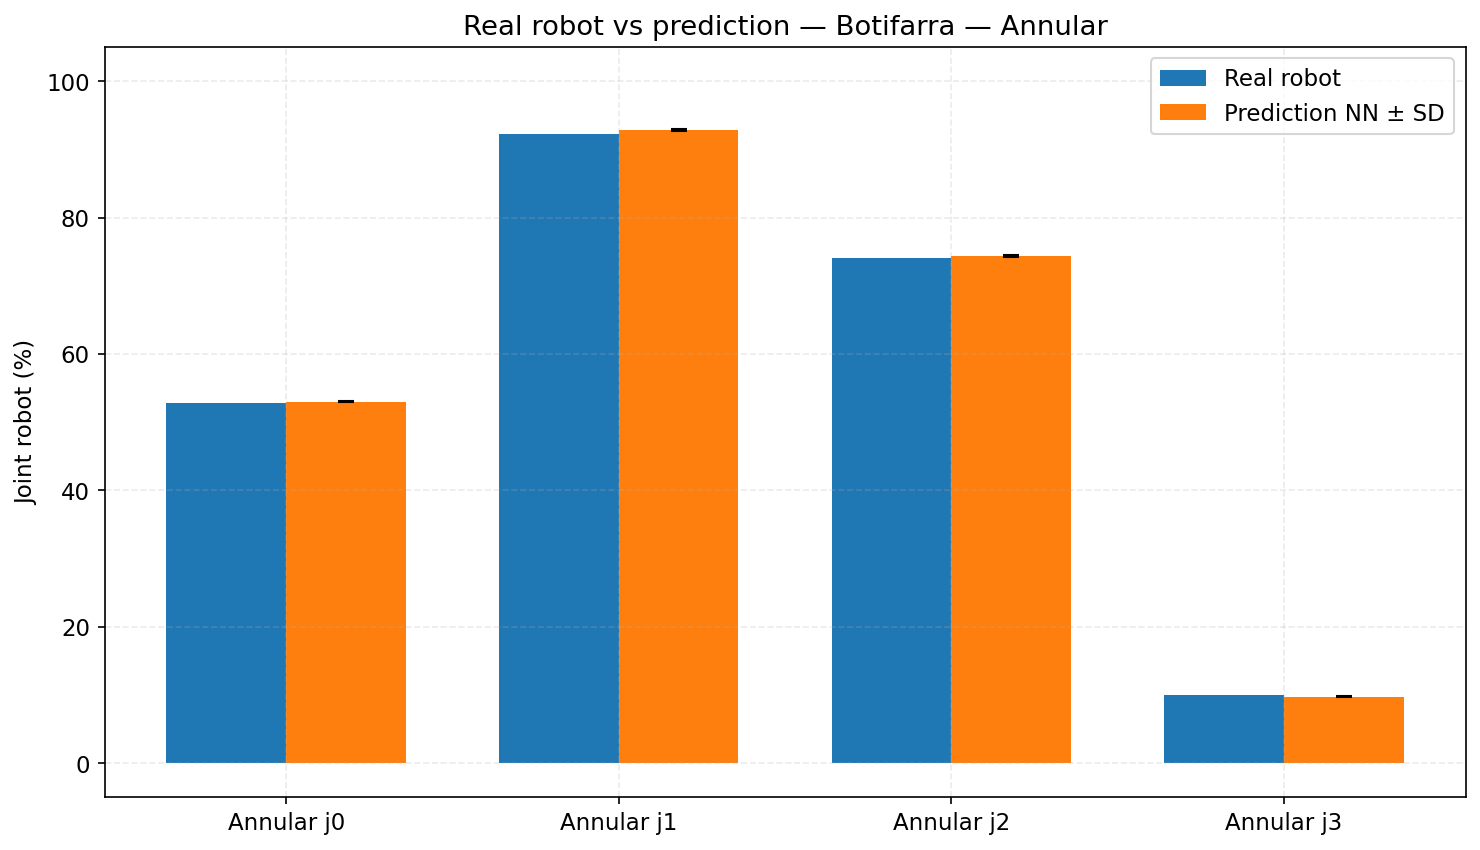

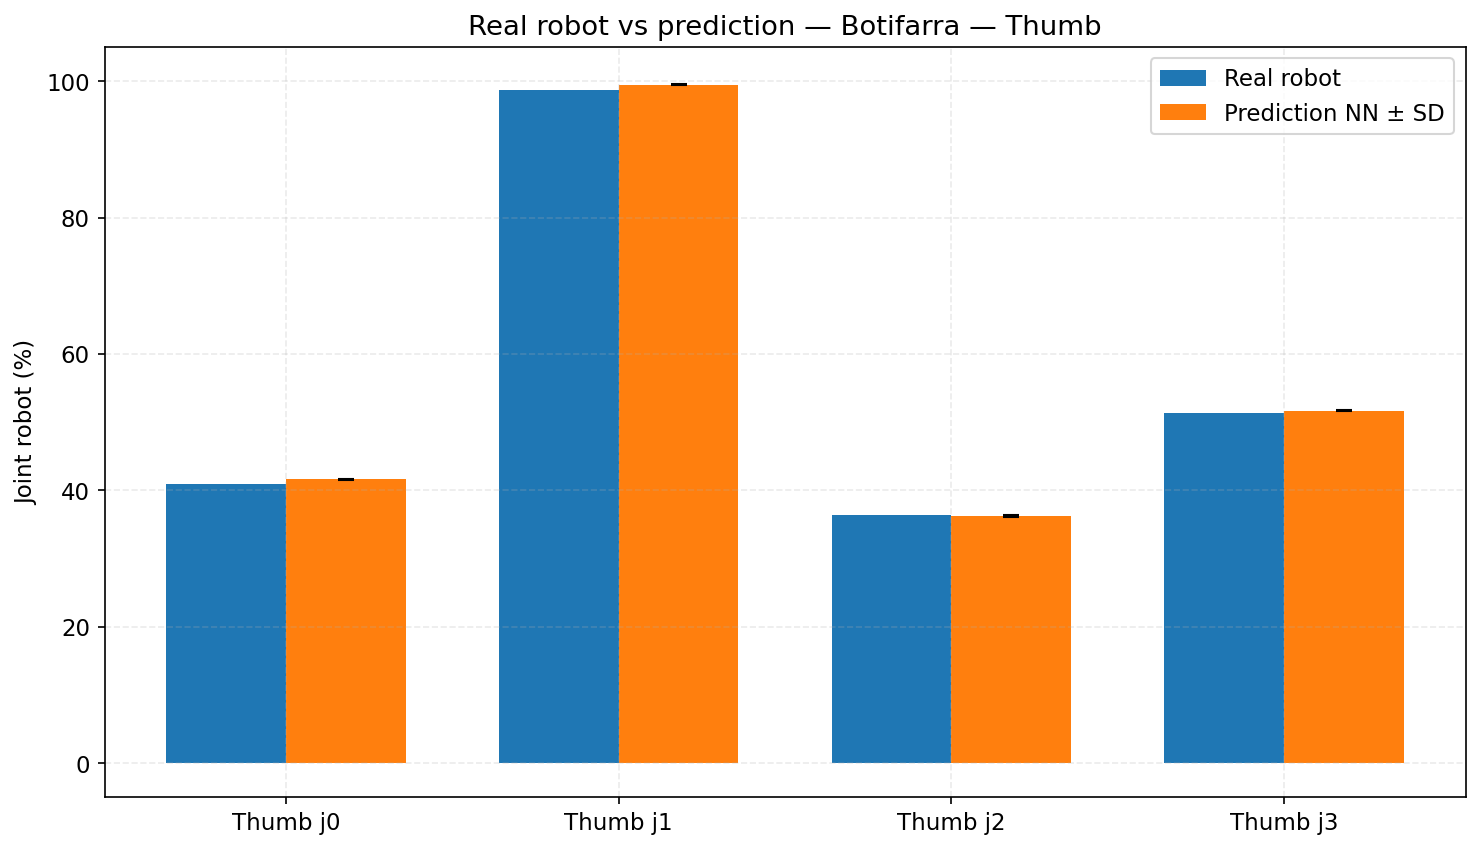

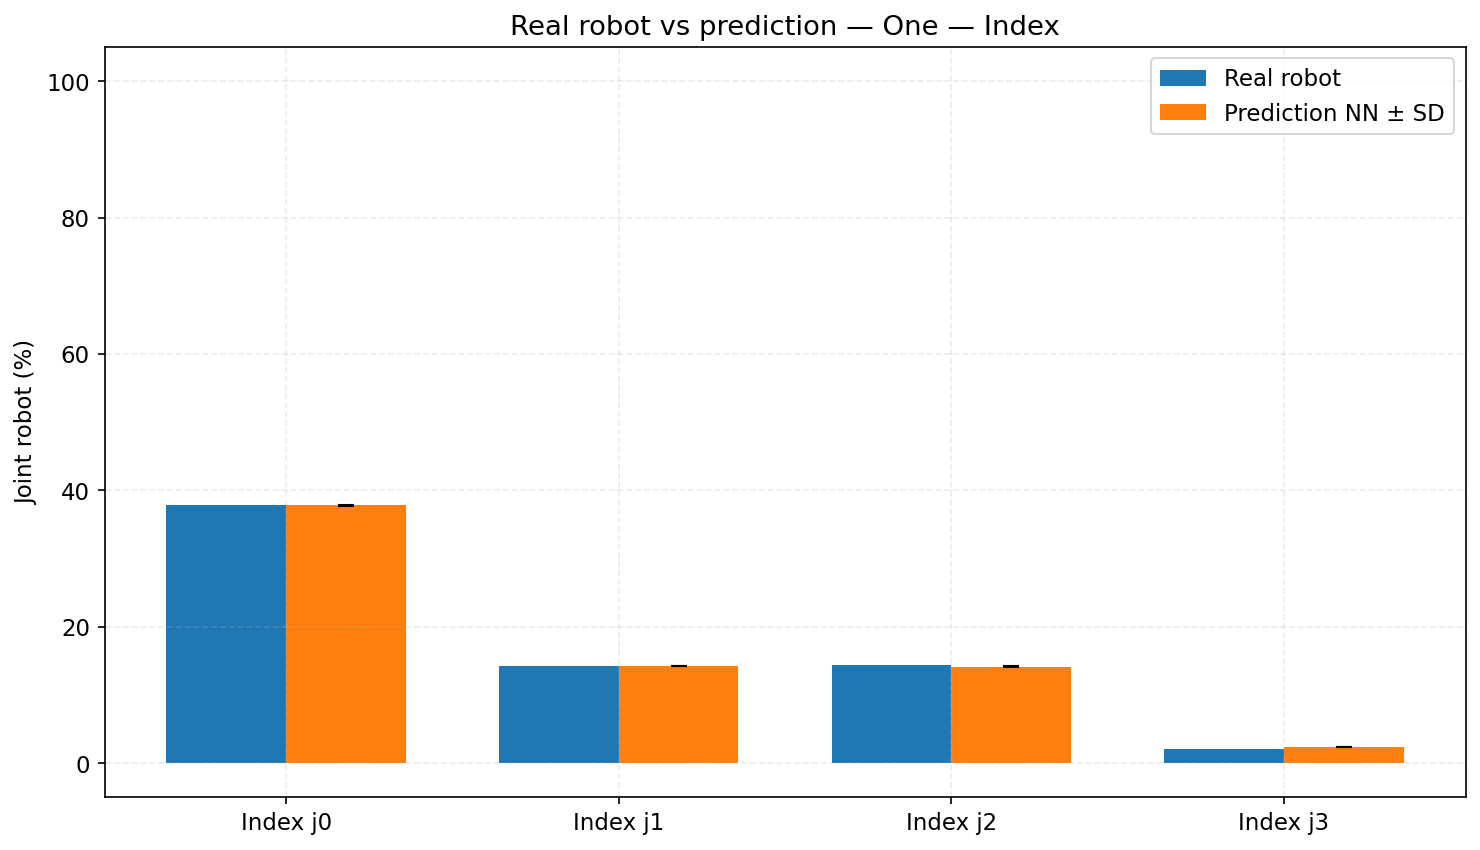

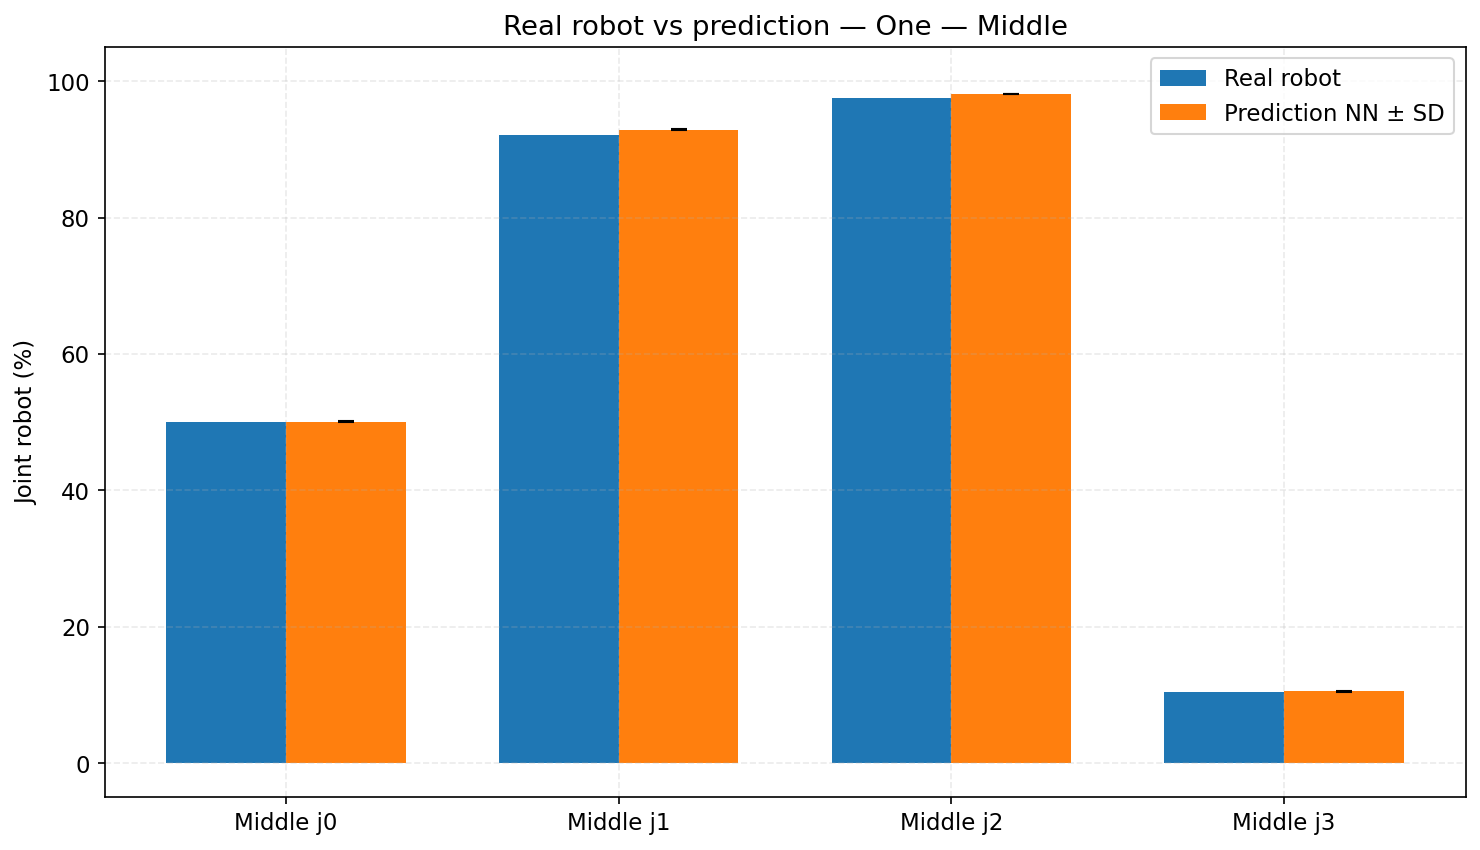

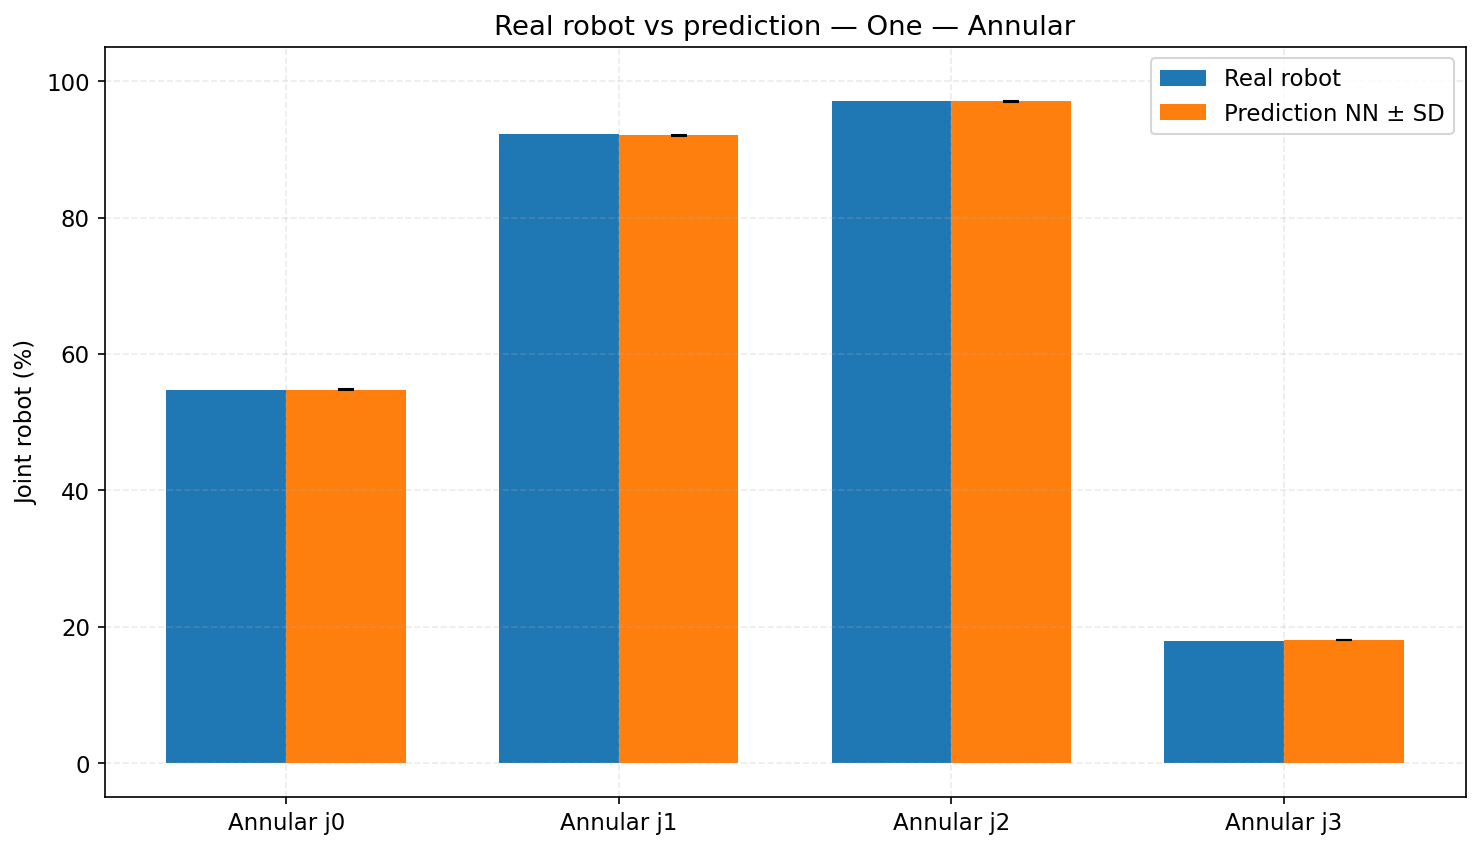

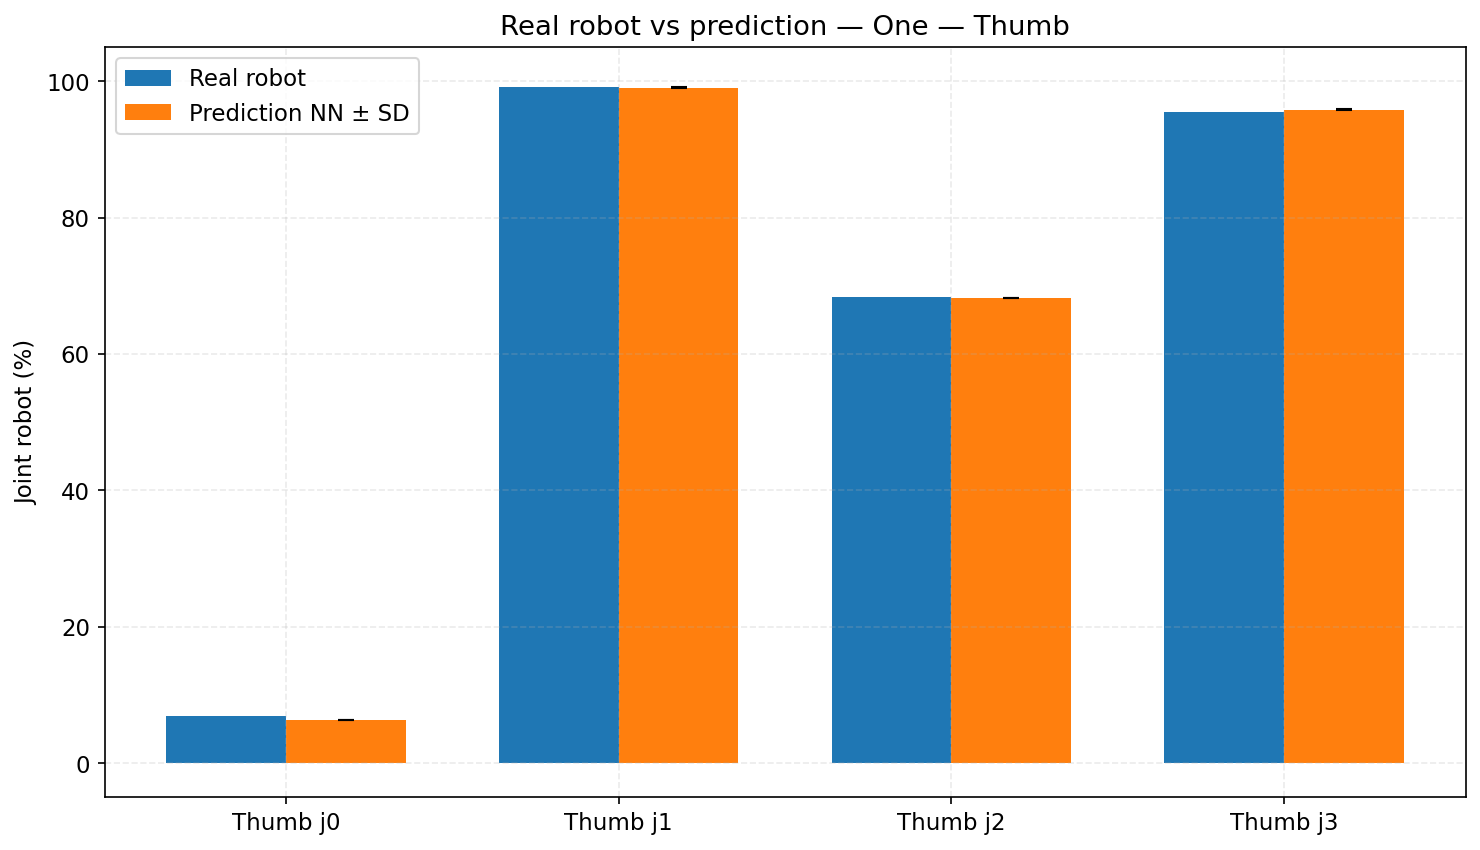

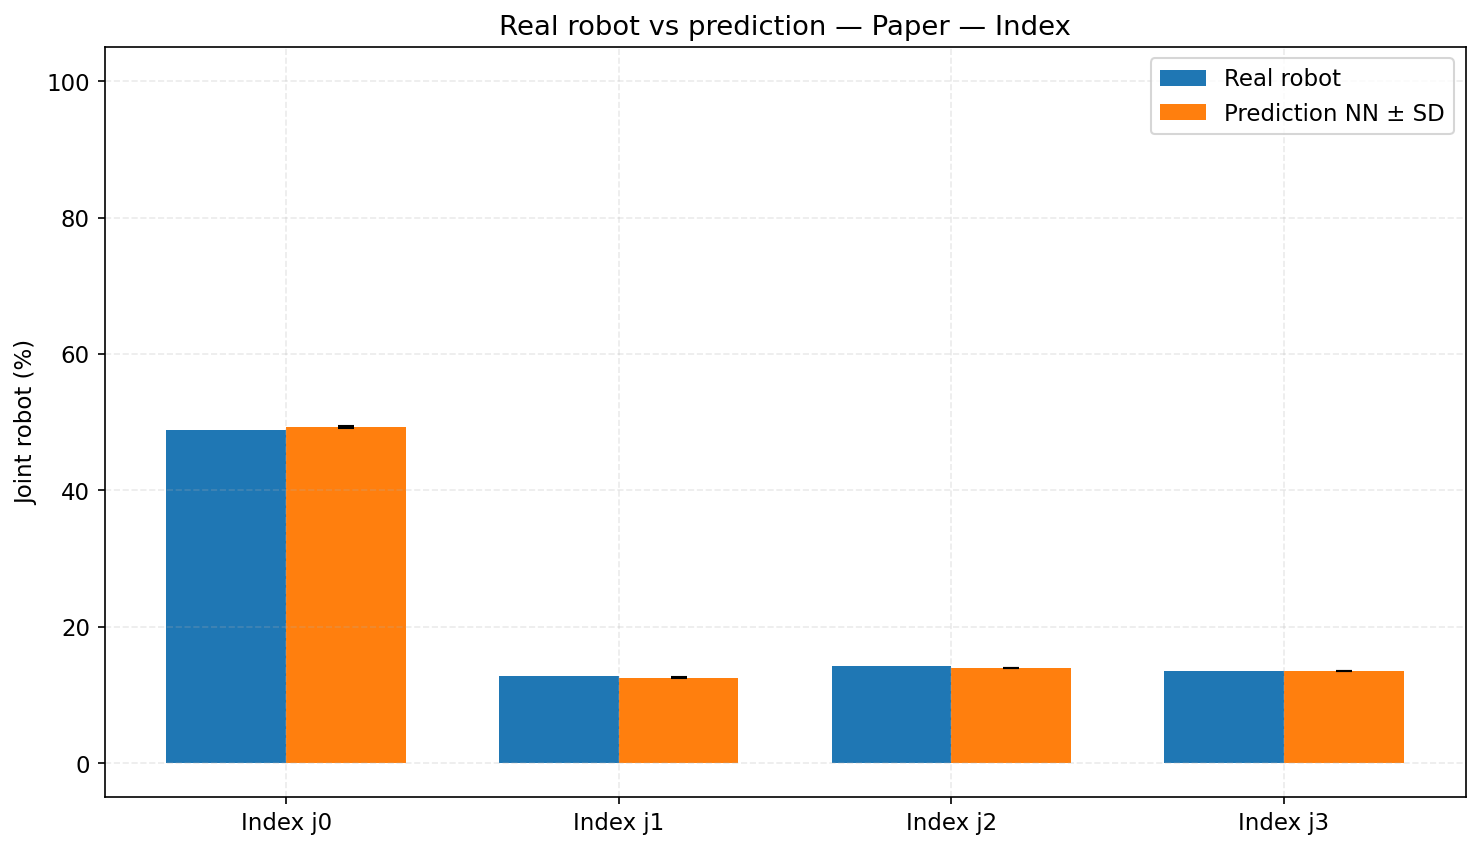

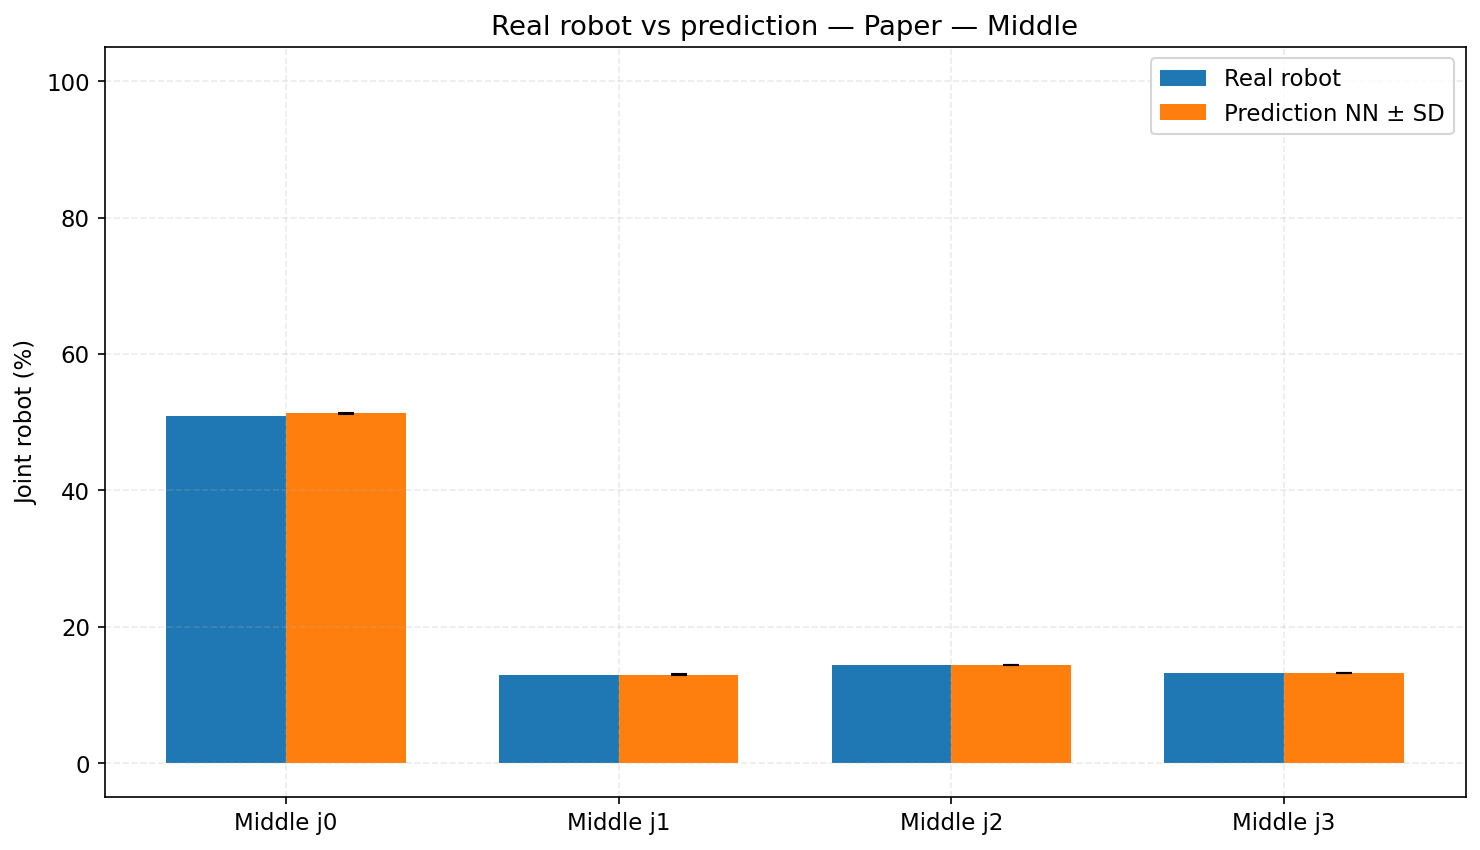

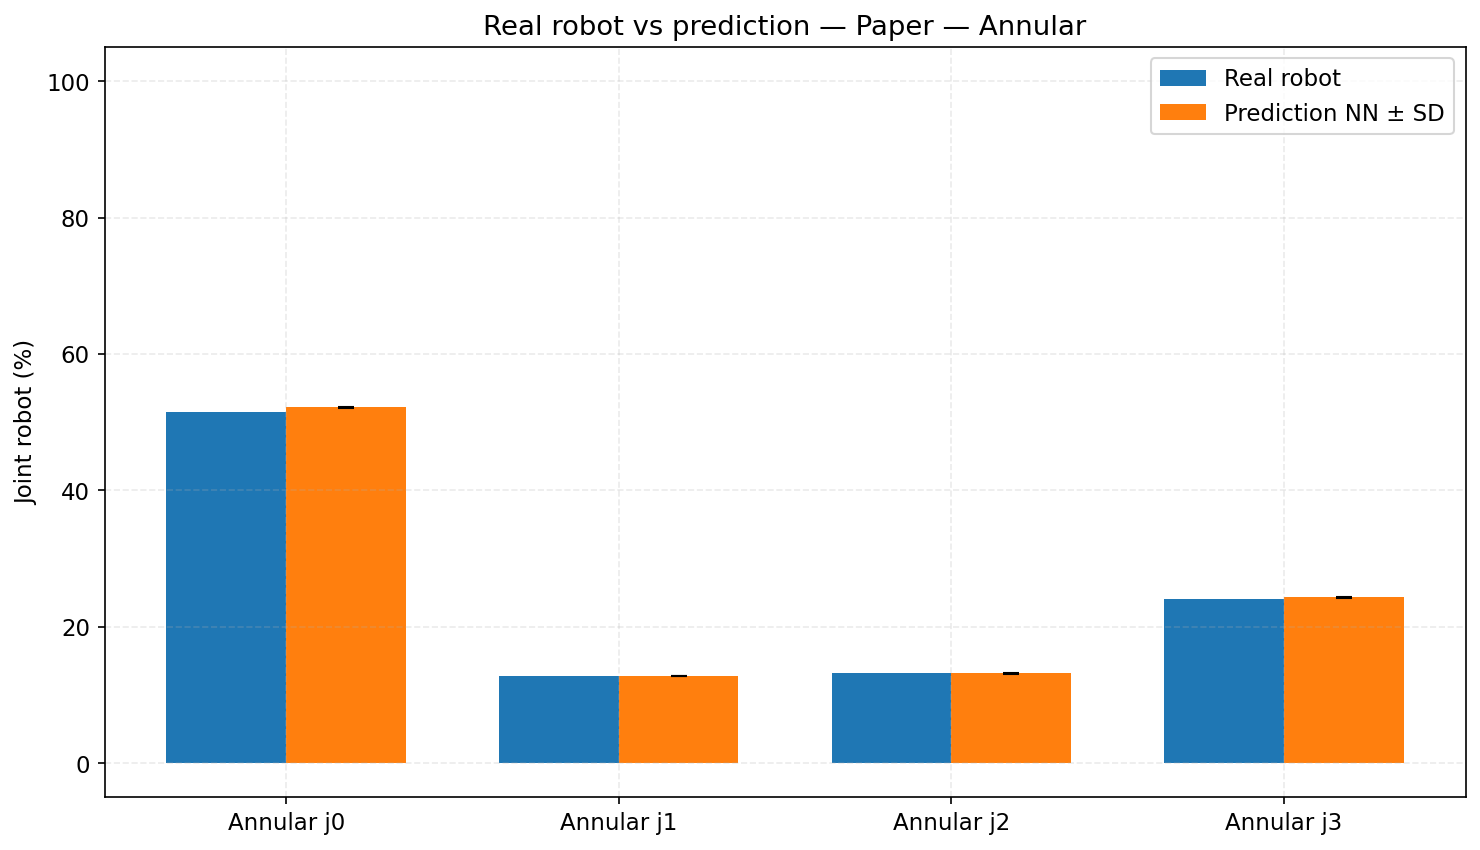

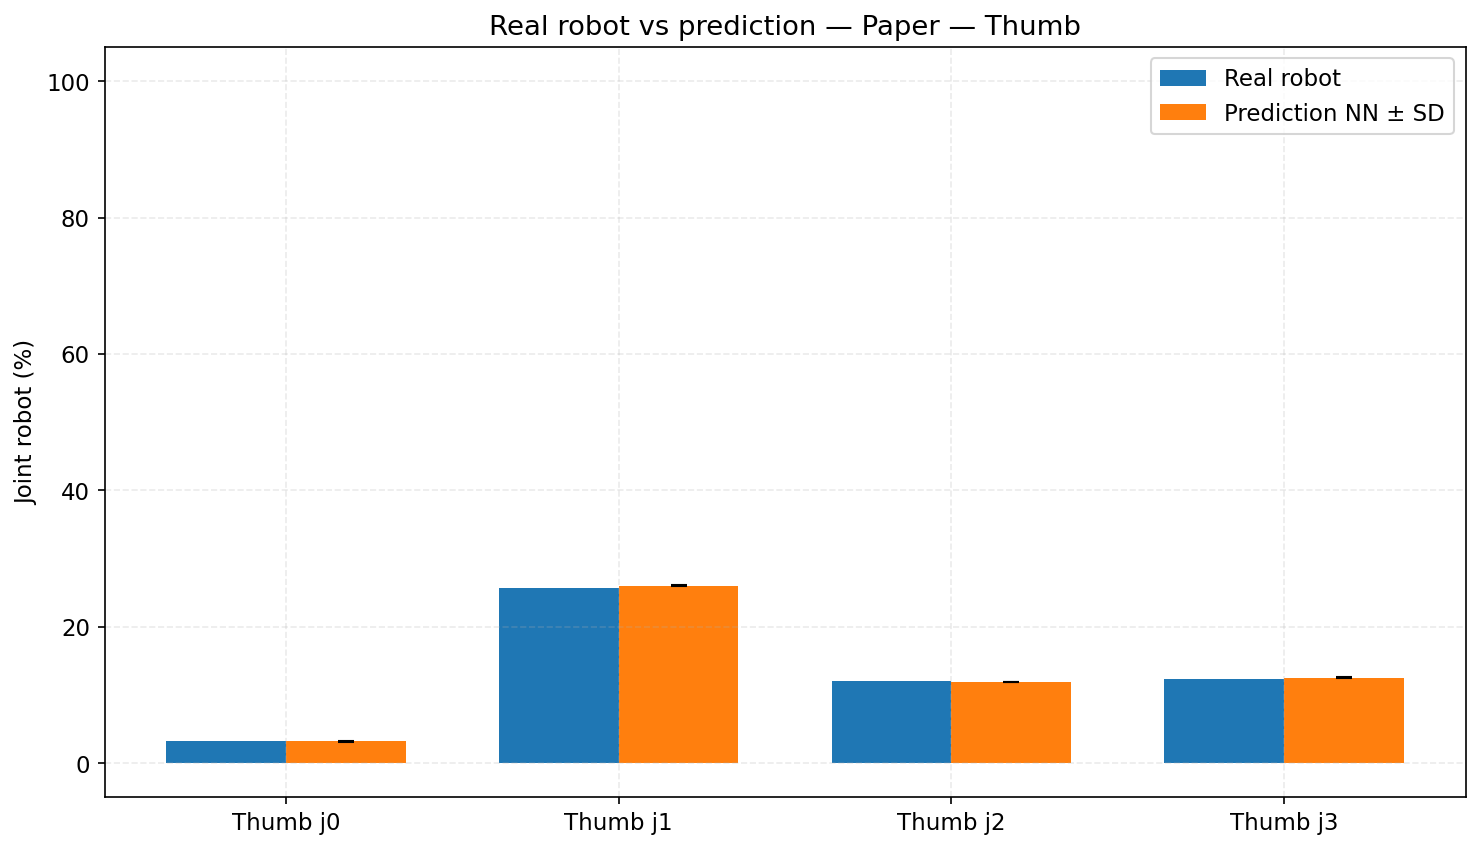

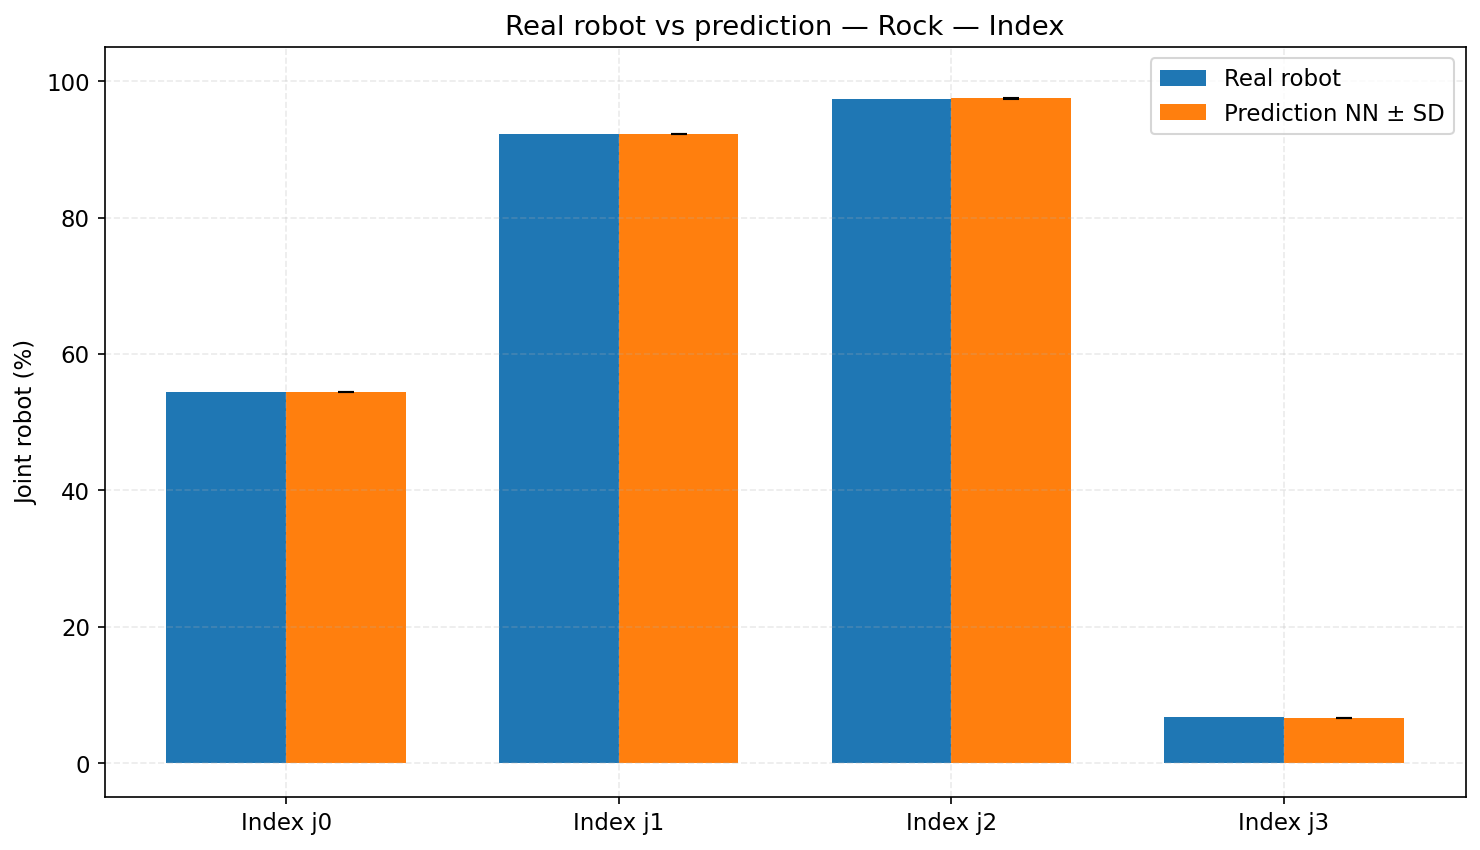

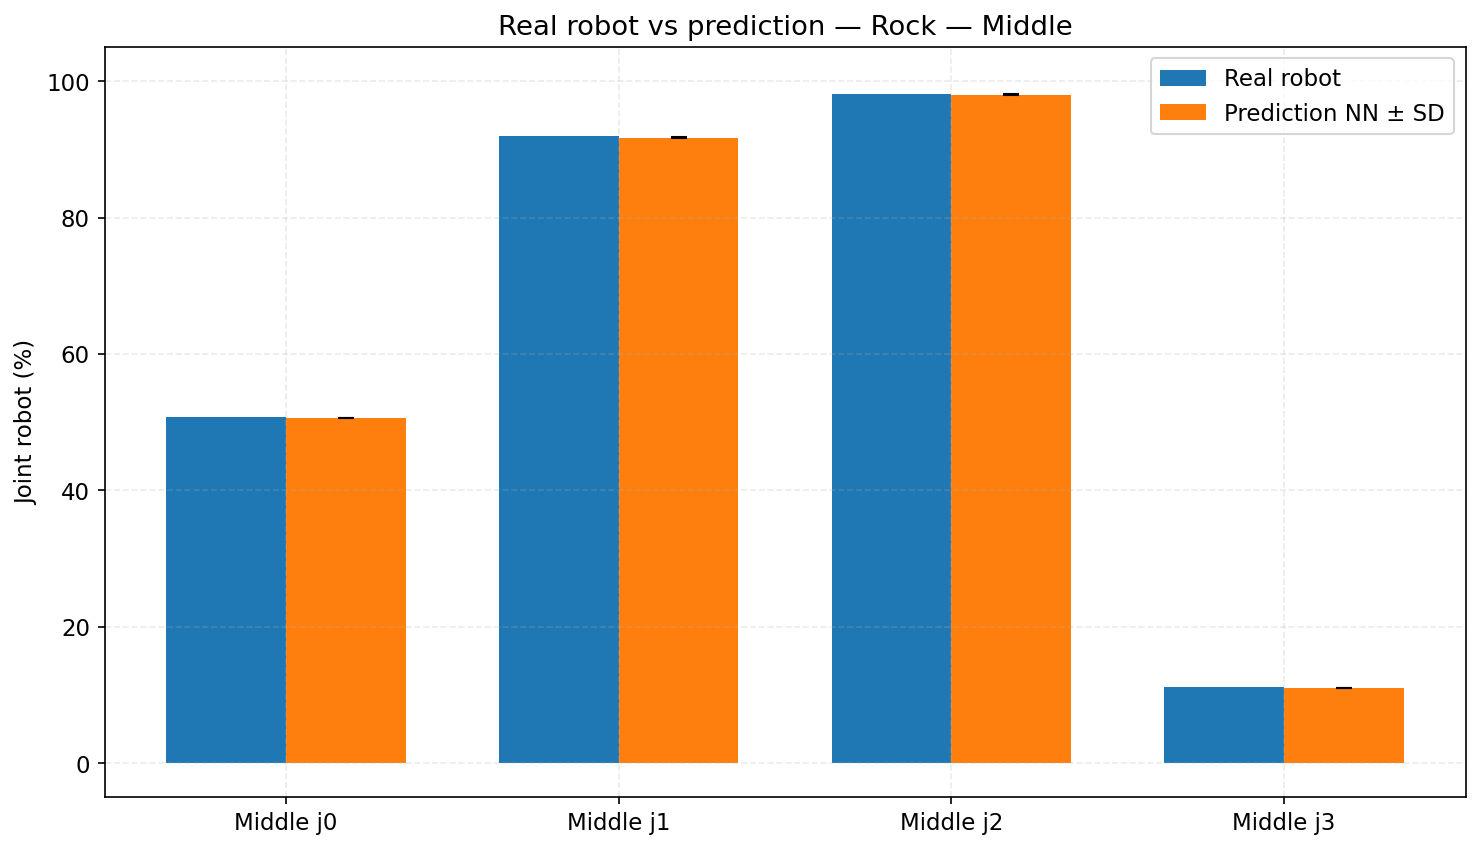

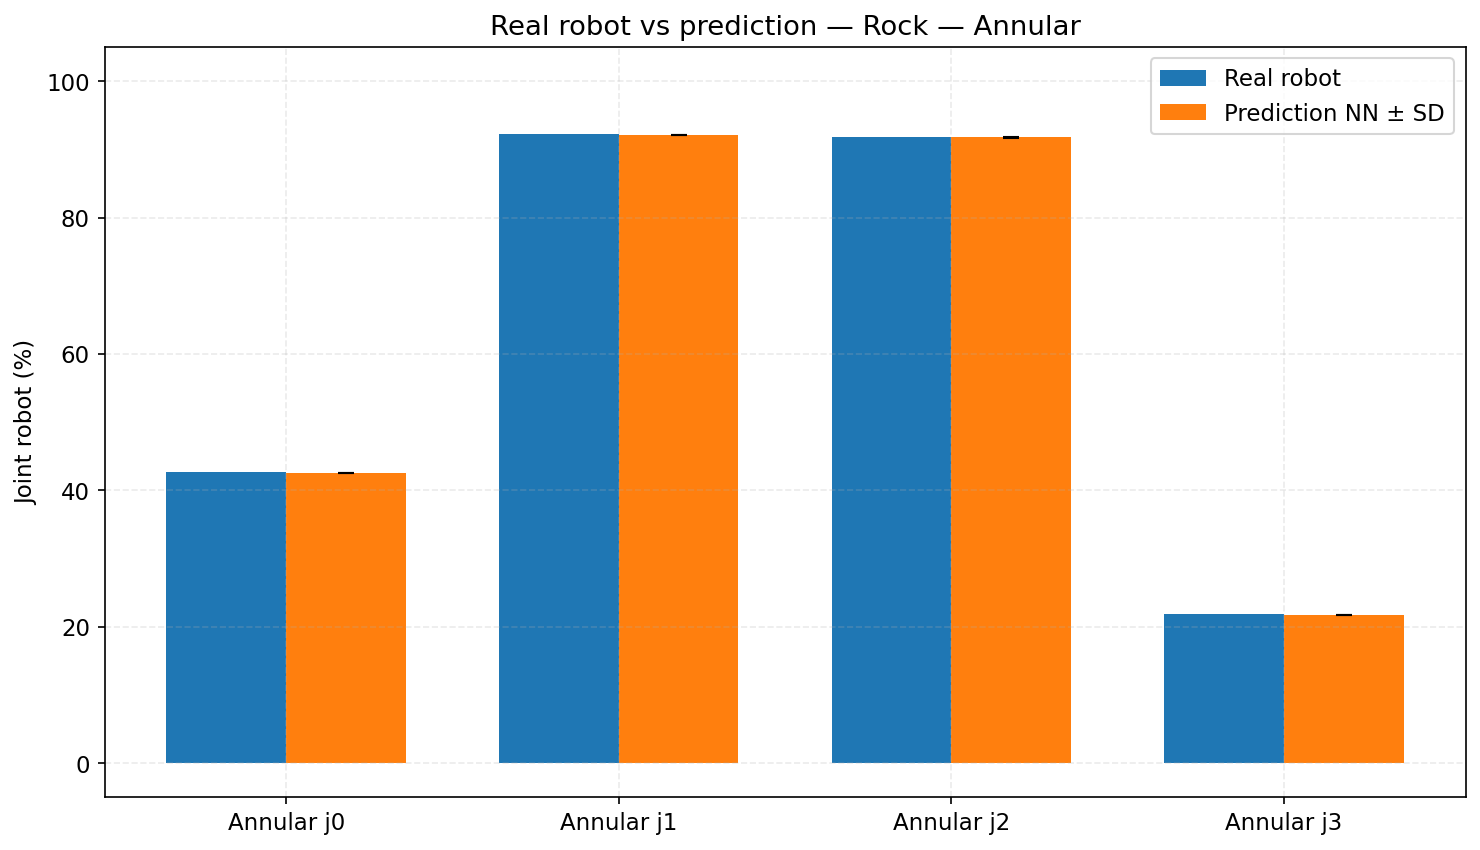

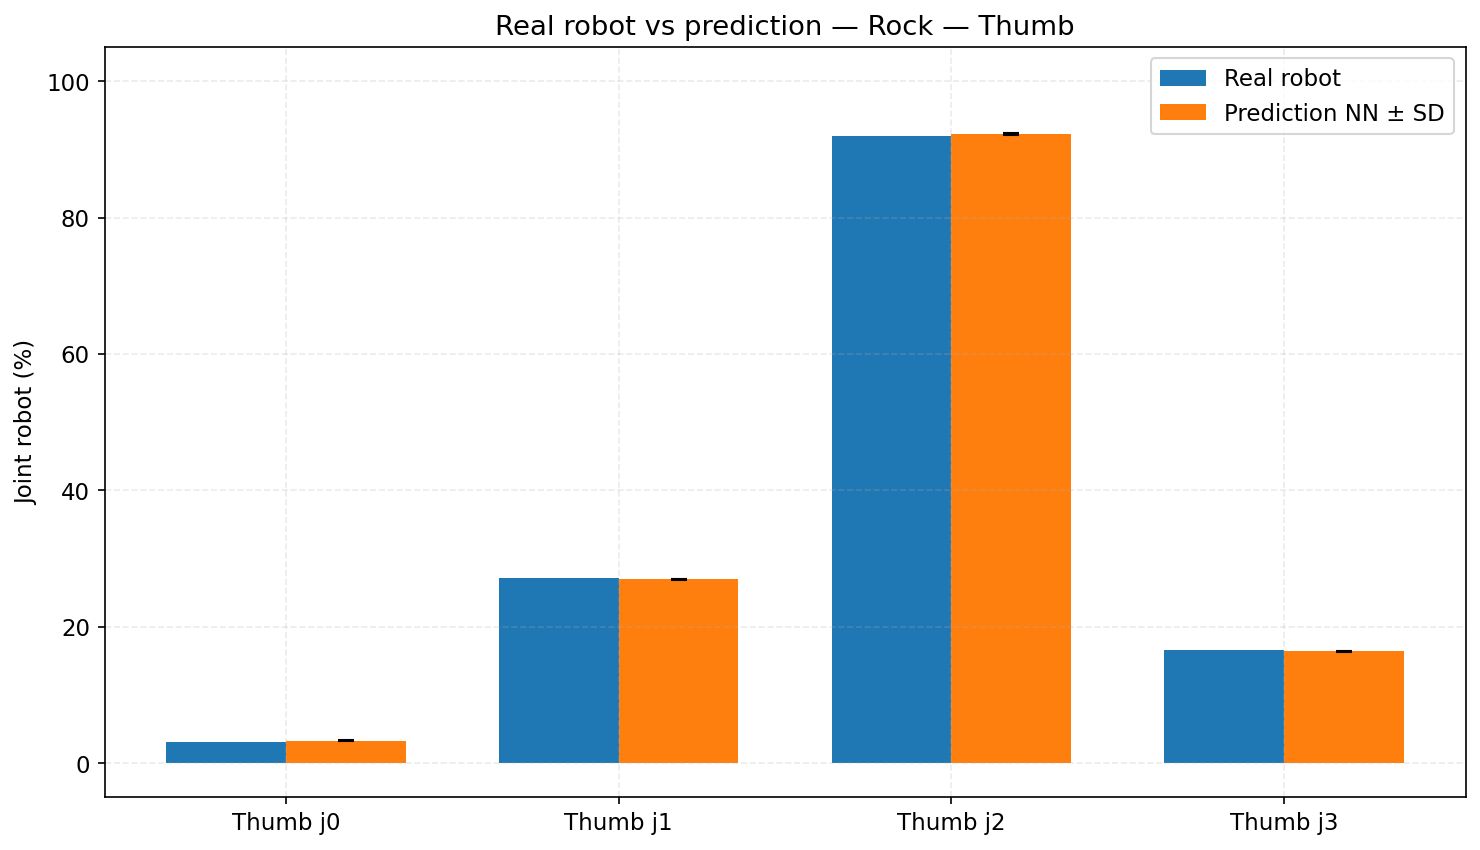

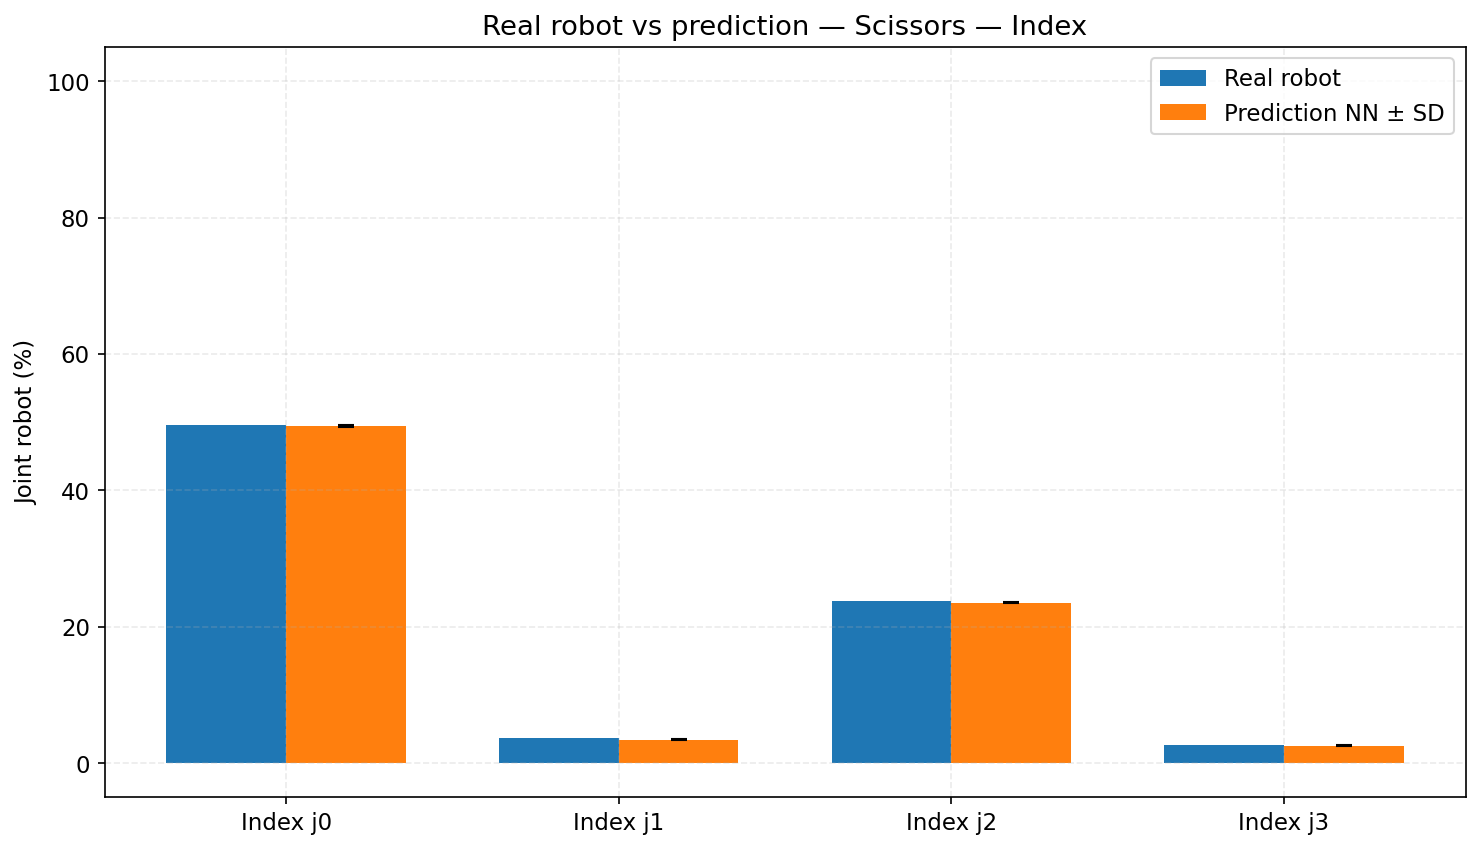

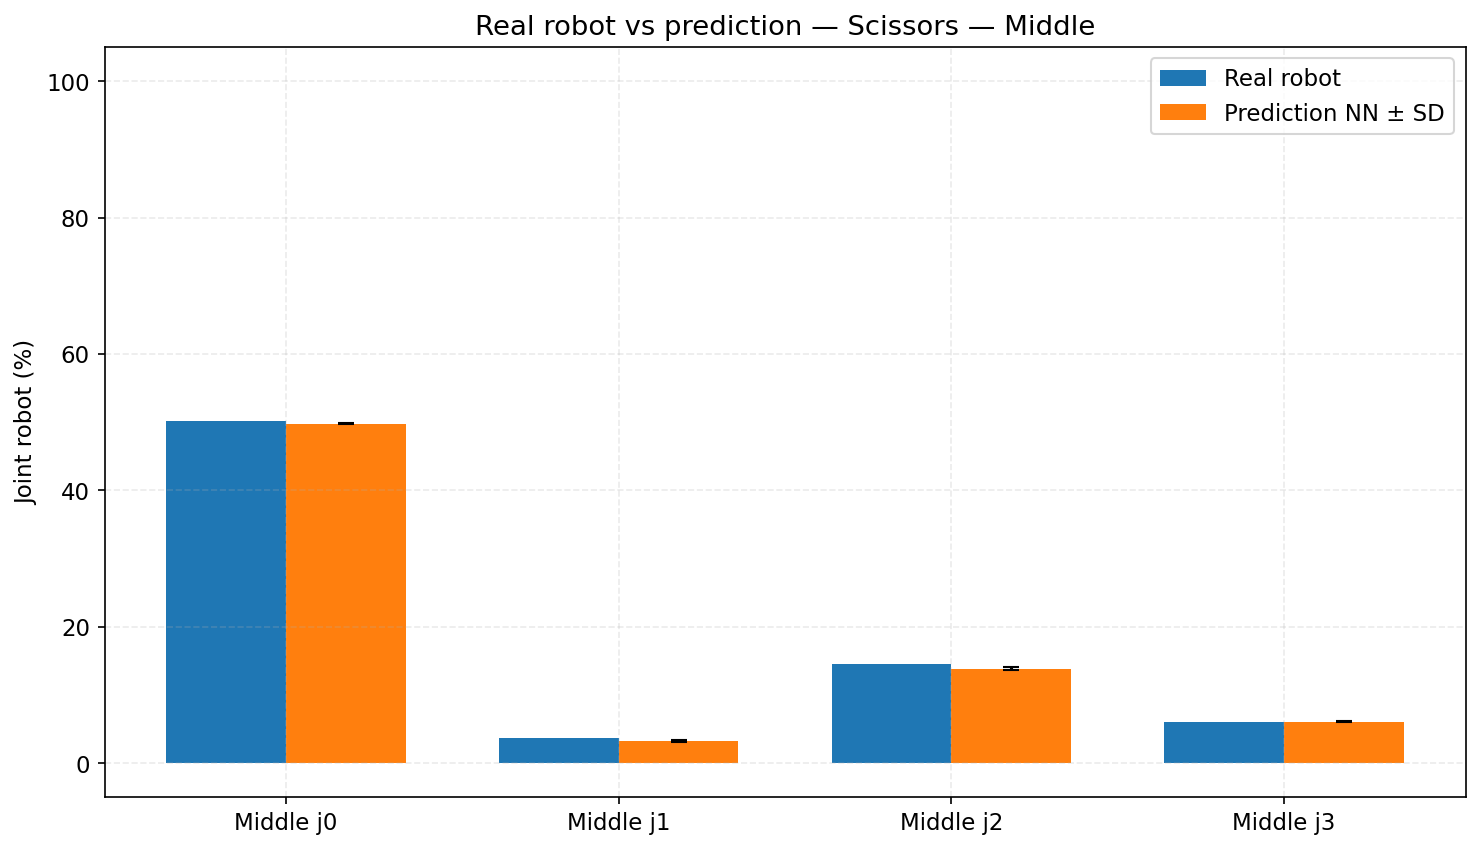

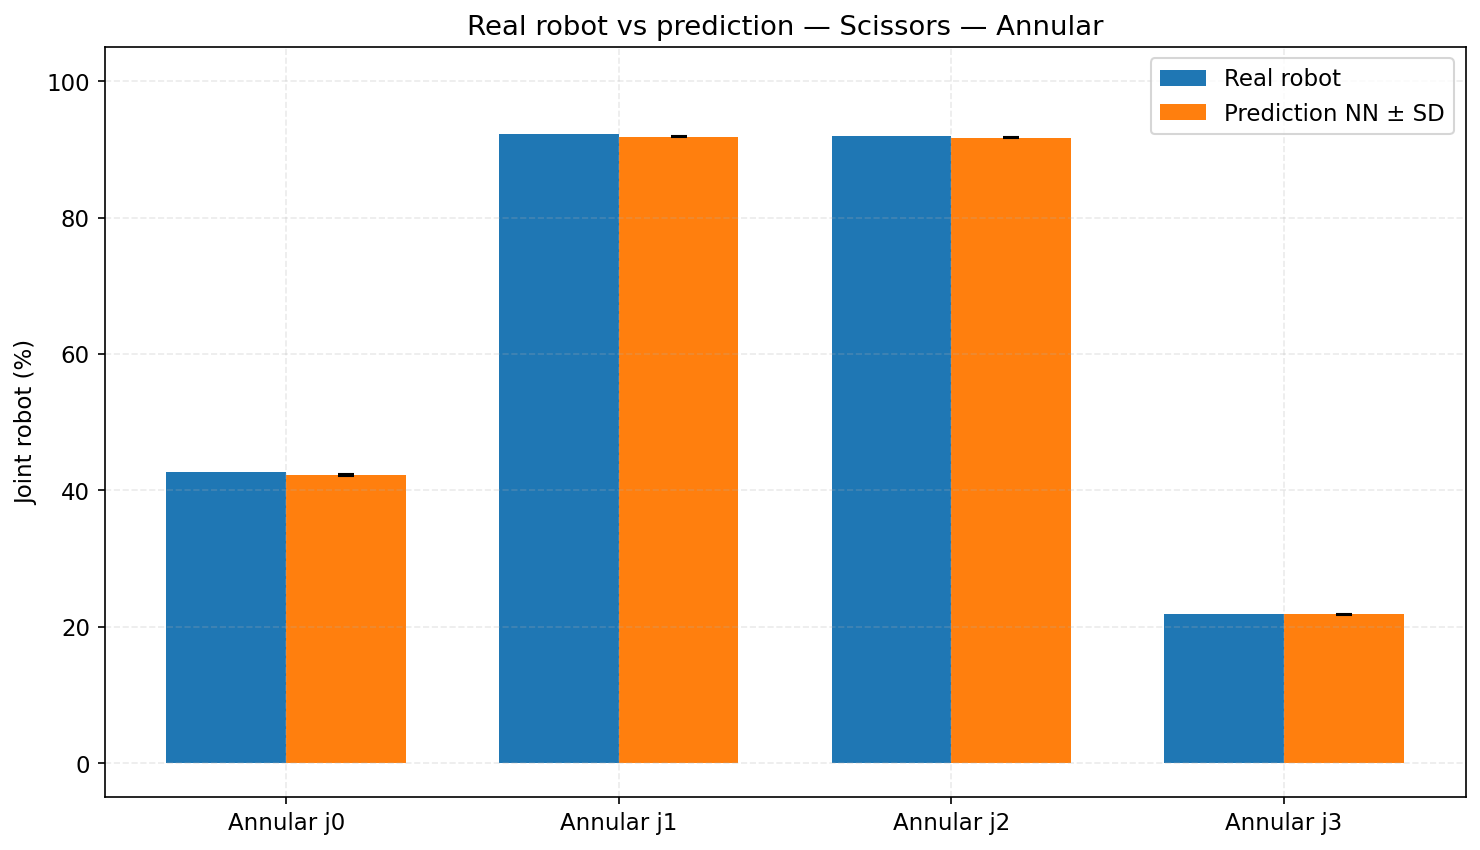

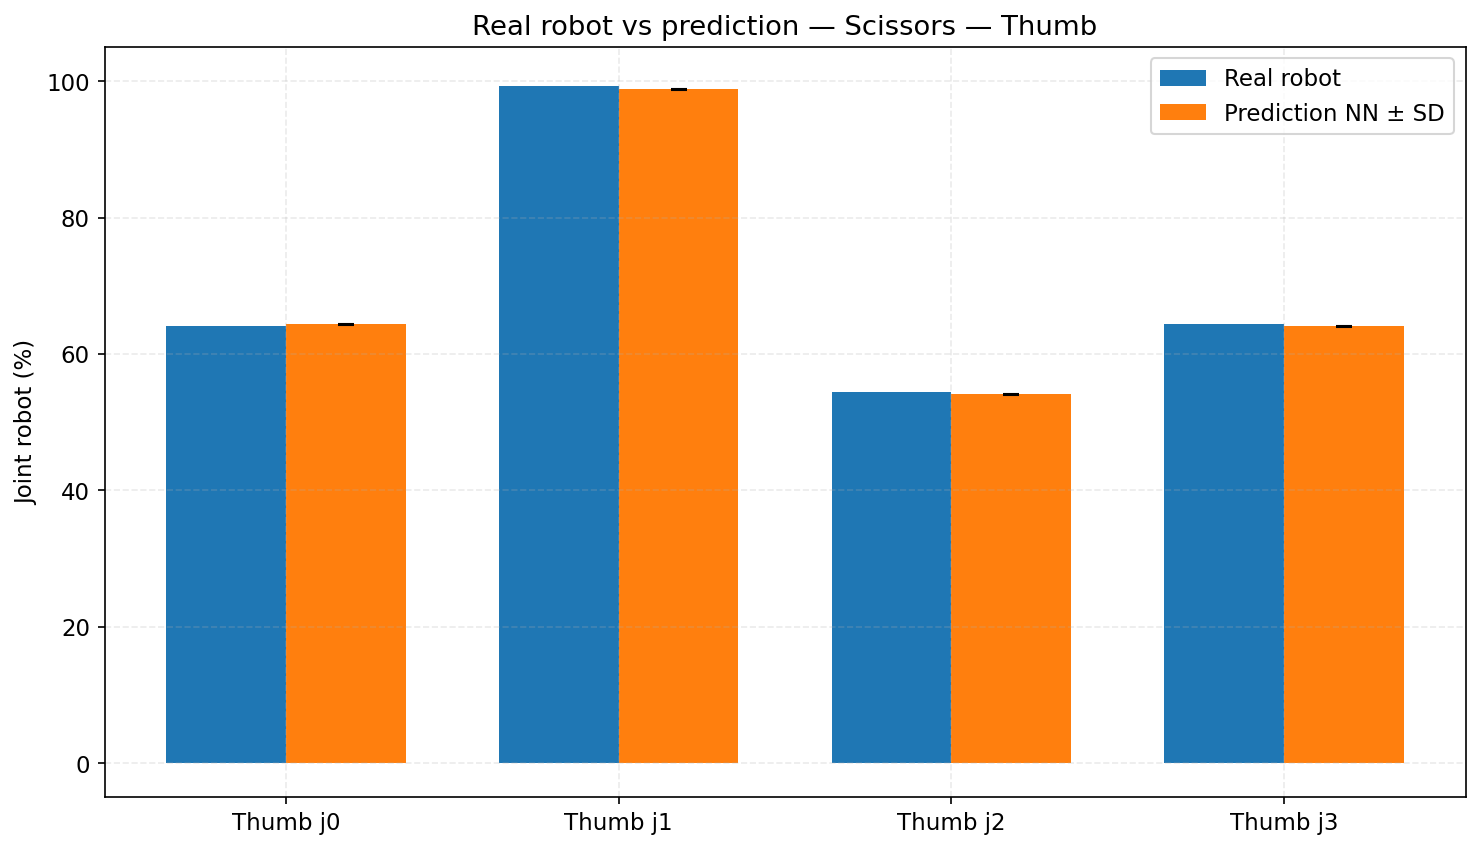

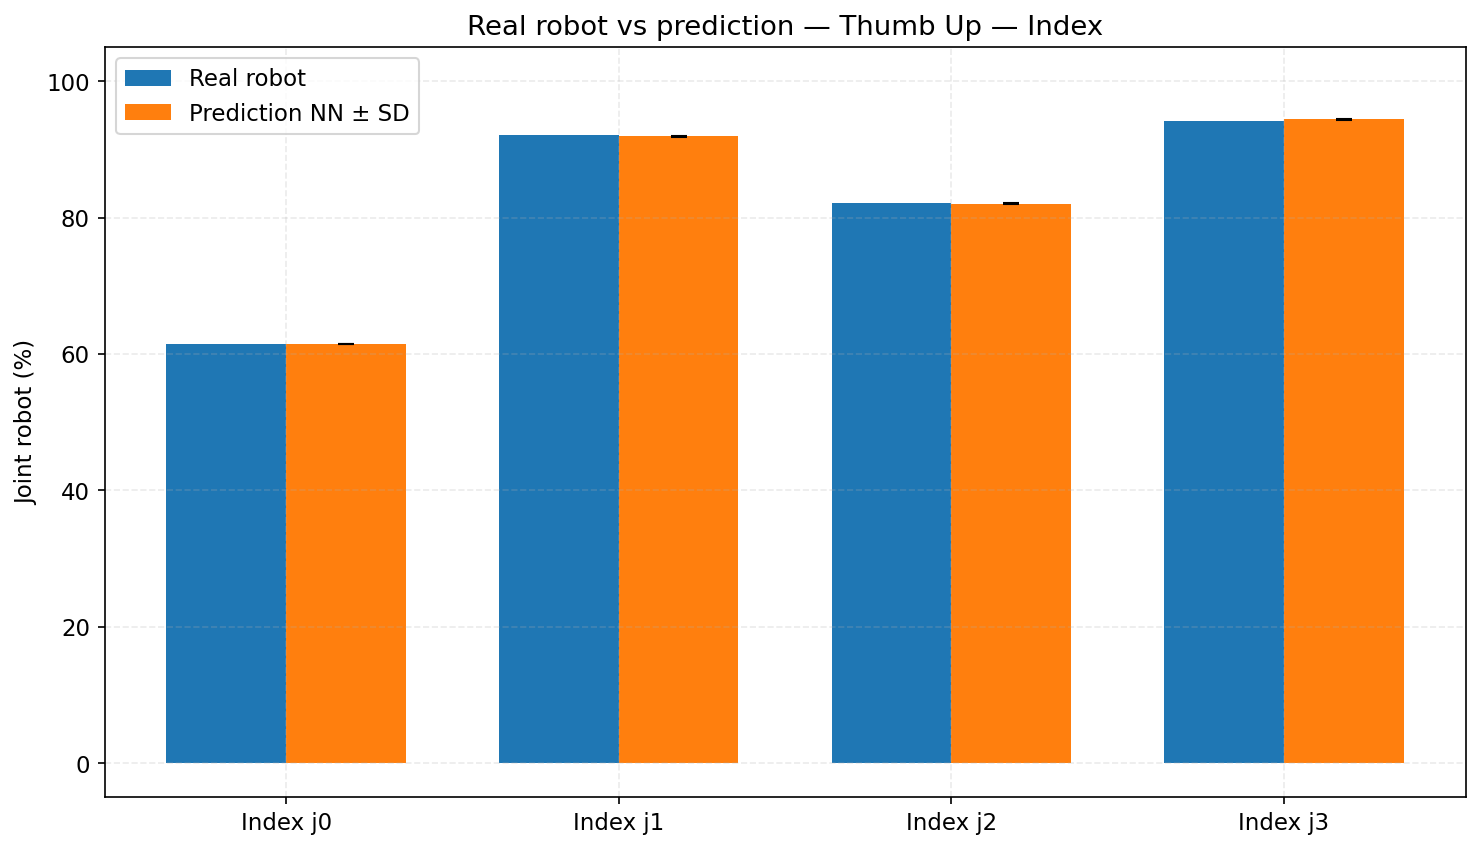

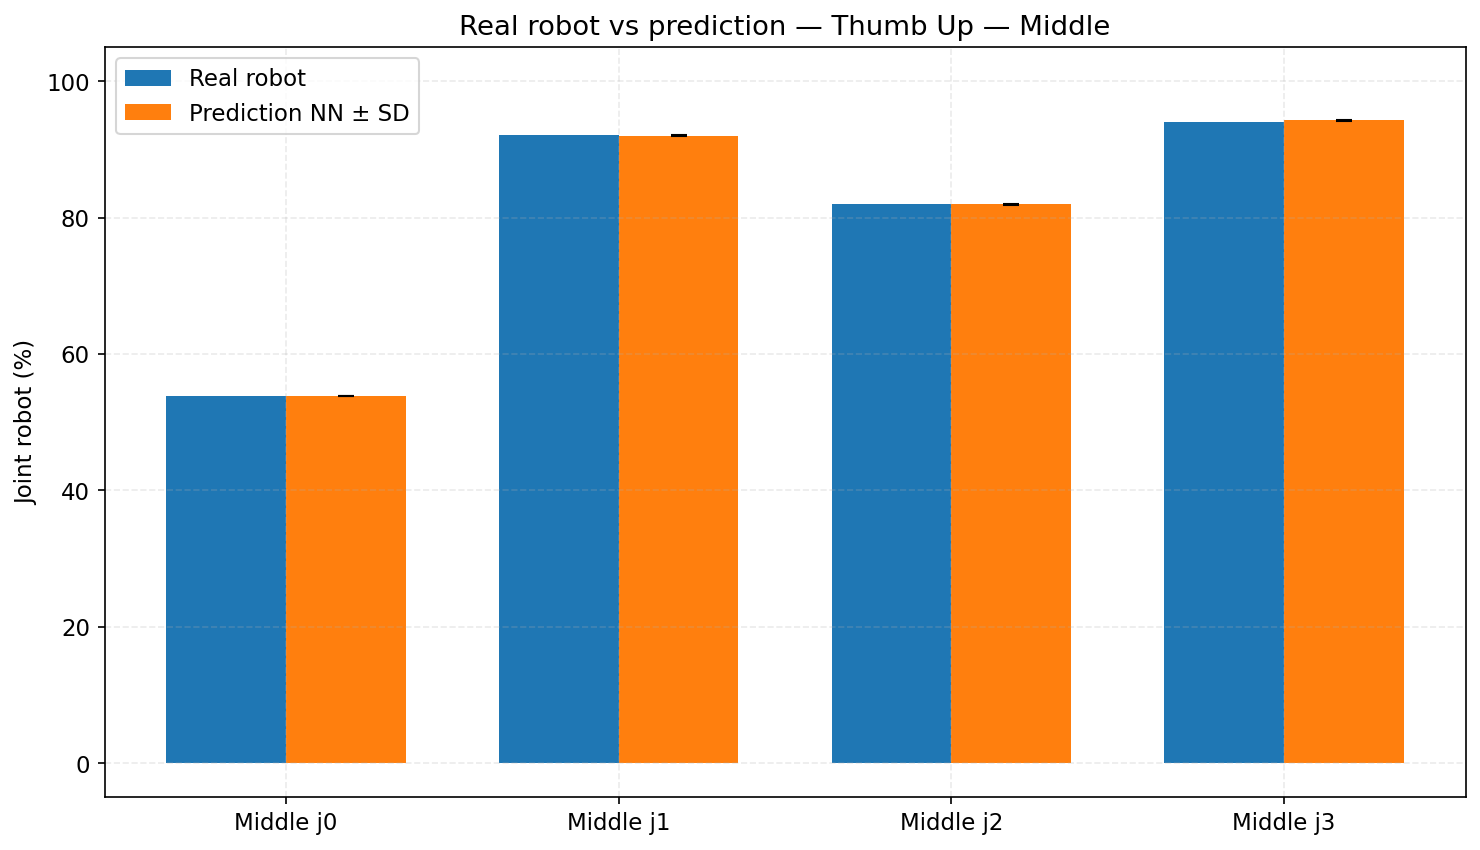

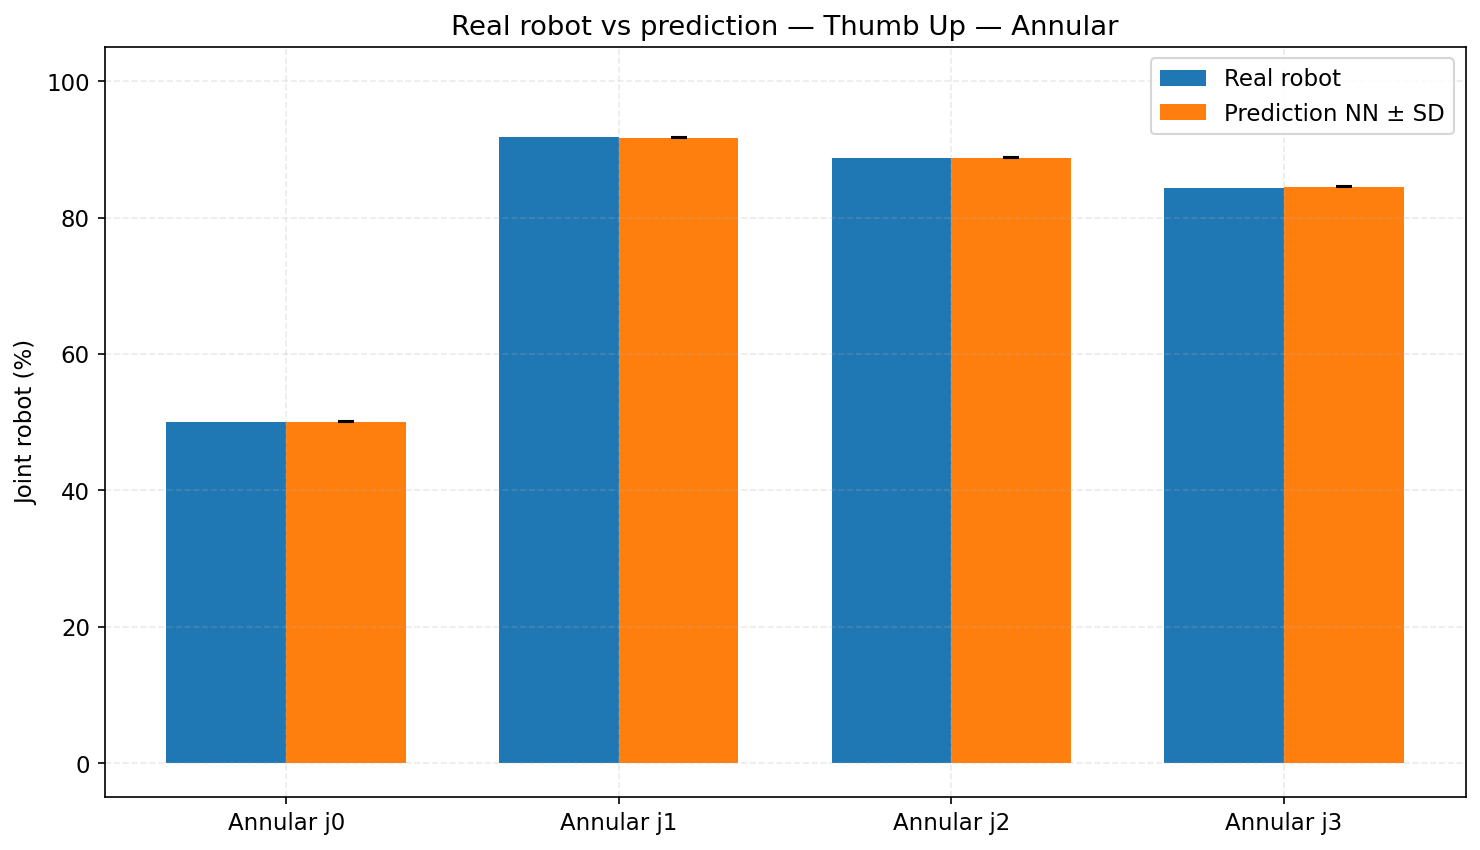

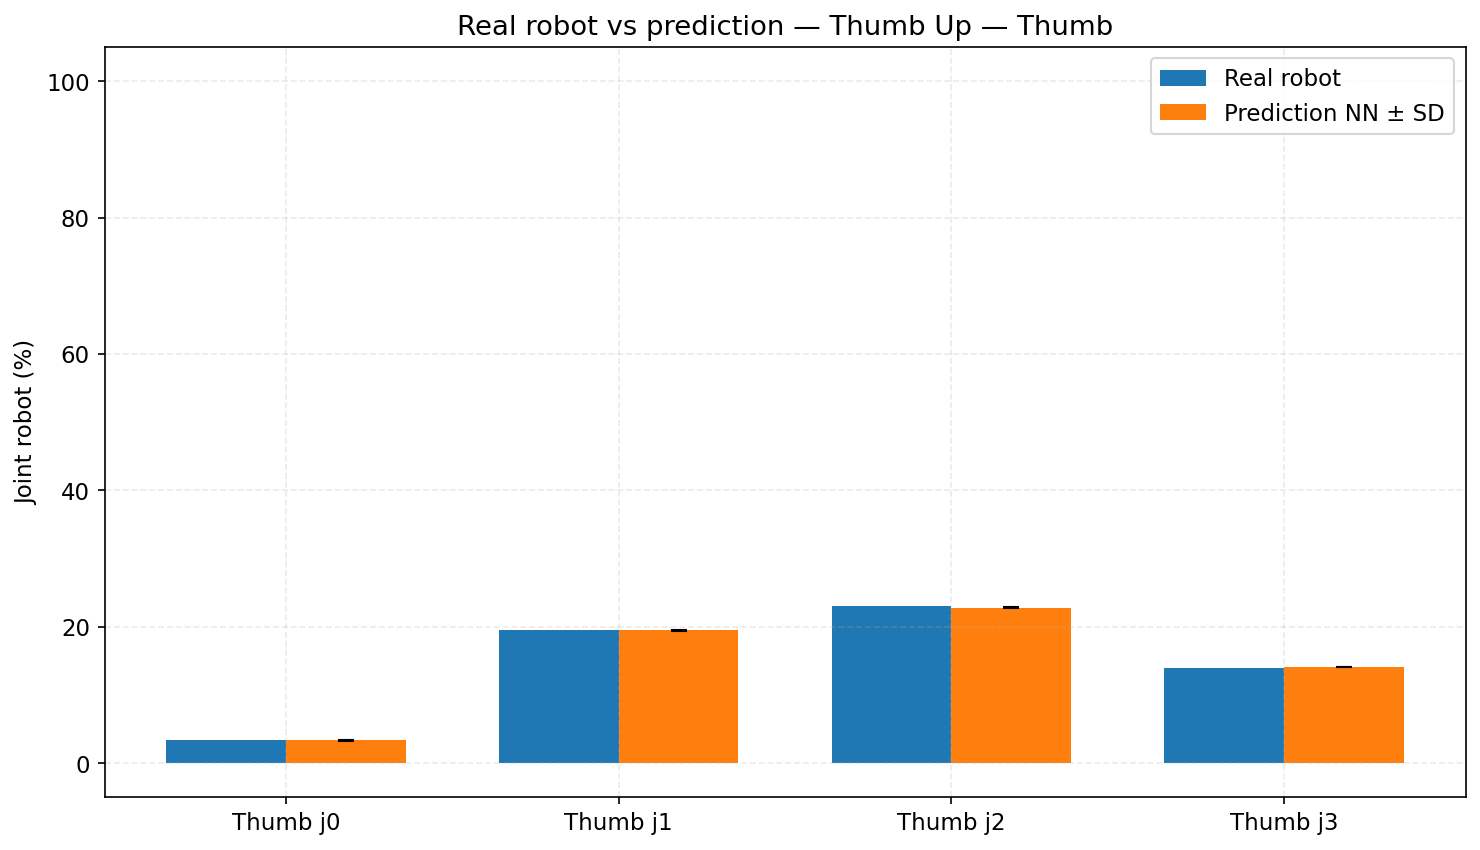

In [22]:
# ============================================================
# PLOTS PER POSICIÓ I DIT
# ============================================================

robot_groups = {
    "Index": ["Index j0", "Index j1", "Index j2", "Index j3"],
    "Middle": ["Middle j0", "Middle j1", "Middle j2", "Middle j3"],
    "Annular": ["Annular j0", "Annular j1", "Annular j2", "Annular j3"],
    "Thumb": ["Thumb j0", "Thumb j1", "Thumb j2", "Thumb j3"],
}

def safe_name(text):
    return (
        text.replace(" ", "_")
        .replace("í", "i")
        .replace("à", "a")
        .replace("è", "e")
        .replace("é", "e")
        .replace("ó", "o")
        .replace("ú", "u")
    )

for pos in sorted(pred_df["position_code"].unique()):
    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos
    pos_folder.mkdir(exist_ok=True)

    subset = position_metrics_df[position_metrics_df["position_code"] == pos].copy()

    for group_name, joints in robot_groups.items():
        s = subset[subset["joint"].isin(joints)].copy()
        s["joint"] = pd.Categorical(s["joint"], categories=joints, ordered=True)
        s = s.sort_values("joint")

        x = np.arange(len(s))
        width = 0.36

        fig, ax = plt.subplots(figsize=(10, 5.8))
        ax.bar(x - width / 2, s["true_mean"], width, label="Real robot")
        ax.bar(x + width / 2, s["pred_mean"], width, yerr=s["pred_std"], capsize=4, label="Prediction NN ± SD")

        ax.set_title(f"Real robot vs prediction — {pos_name} — {group_name}")
        ax.set_xticks(x)
        ax.set_xticklabels(s["joint"])
        ax.set_ylabel("Joint robot (%)")
        ax.set_ylim(-5, 105)
        ax.legend()

        fig.tight_layout()
        fig.savefig(pos_folder / f"{pos}_{safe_name(group_name)}_real_vs_pred.png", bbox_inches="tight")
        plt.show()


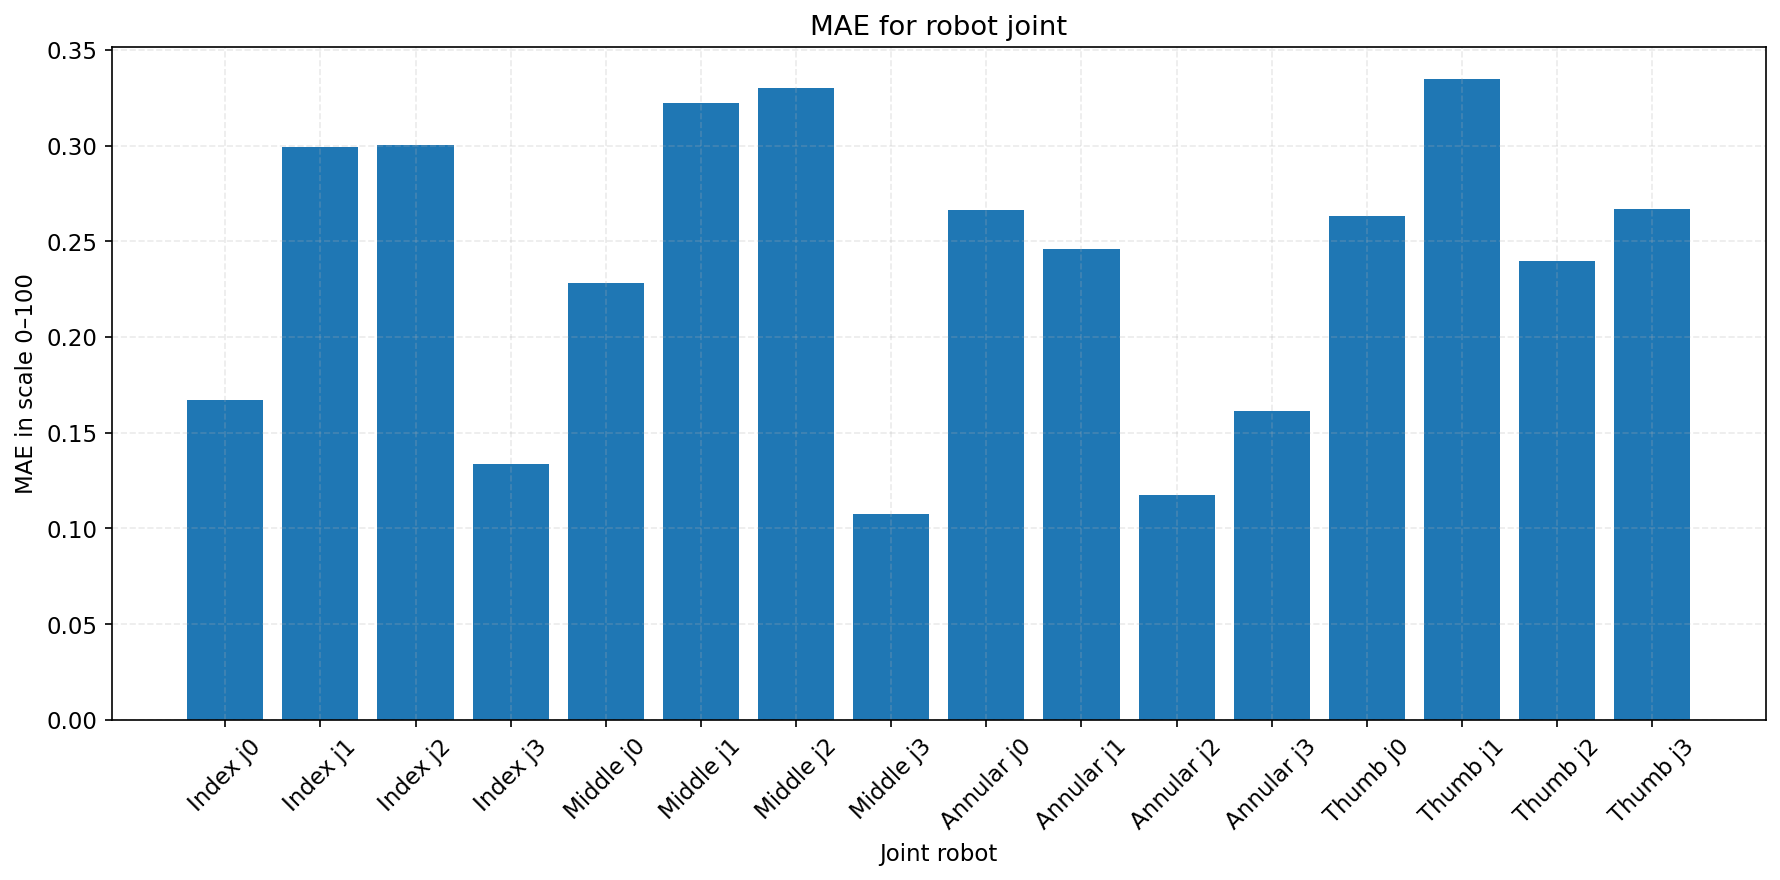

In [21]:
# ============================================================
# ERROR PER JOINT
# ============================================================

plot_df = metrics_df.copy()
plot_df["joint"] = pd.Categorical(plot_df["joint"], categories=robot_joint_order, ordered=True)
plot_df = plot_df.sort_values("joint")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["joint"].astype(str), plot_df["MAE"])
ax.set_title("MAE for robot joint")
ax.set_xlabel("Joint robot")
ax.set_ylabel("MAE in scale 0–100")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(output_dir / "mae_by_robot_joint.png", bbox_inches="tight")
plt.show()


In [19]:
# ============================================================
# GUARDAR MODEL
# ============================================================

model.save(output_dir / "glove_to_robot_static_nn.keras")

with open(output_dir / "x_scaler.pkl", "wb") as f:
    pickle.dump(x_scaler, f)

config = {
    "input_joints": input_joints,
    "robot_joint_order": robot_joint_order,
    "glove_value_key": glove_value_key,
    "clip_to_0_100": clip_to_0_100,
}

with open(output_dir / "model_config.pkl", "wb") as f:
    pickle.dump(config, f)

print("Model, scaler i configuració guardats a:", output_dir)


Model, scaler i configuració guardats a: nn_static_glove_to_robot


Generant resum tots els joints: BotiStat — Botifarra


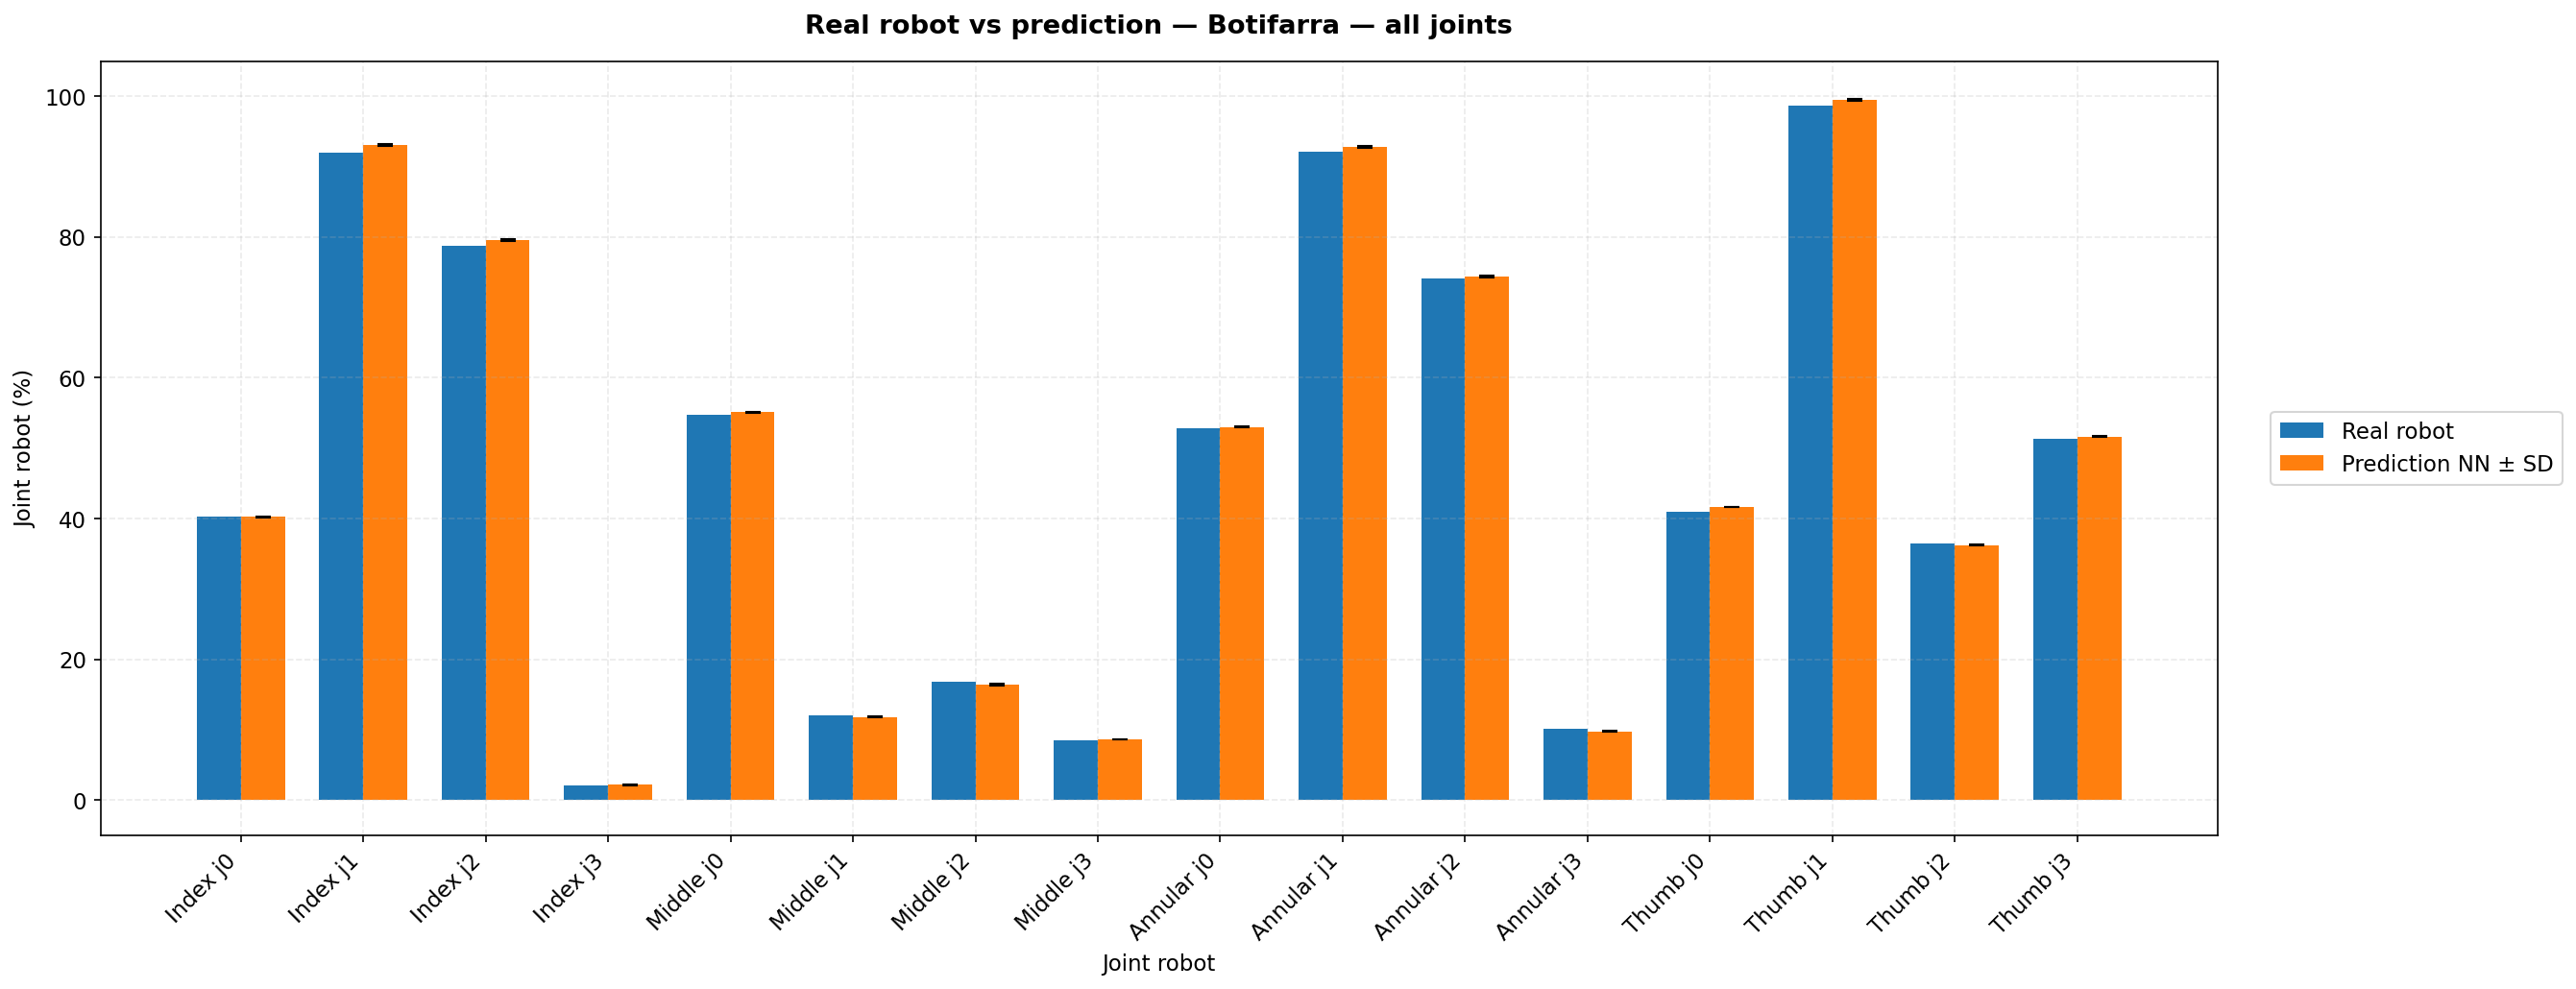

Generant resum tots els joints: OneStat — One


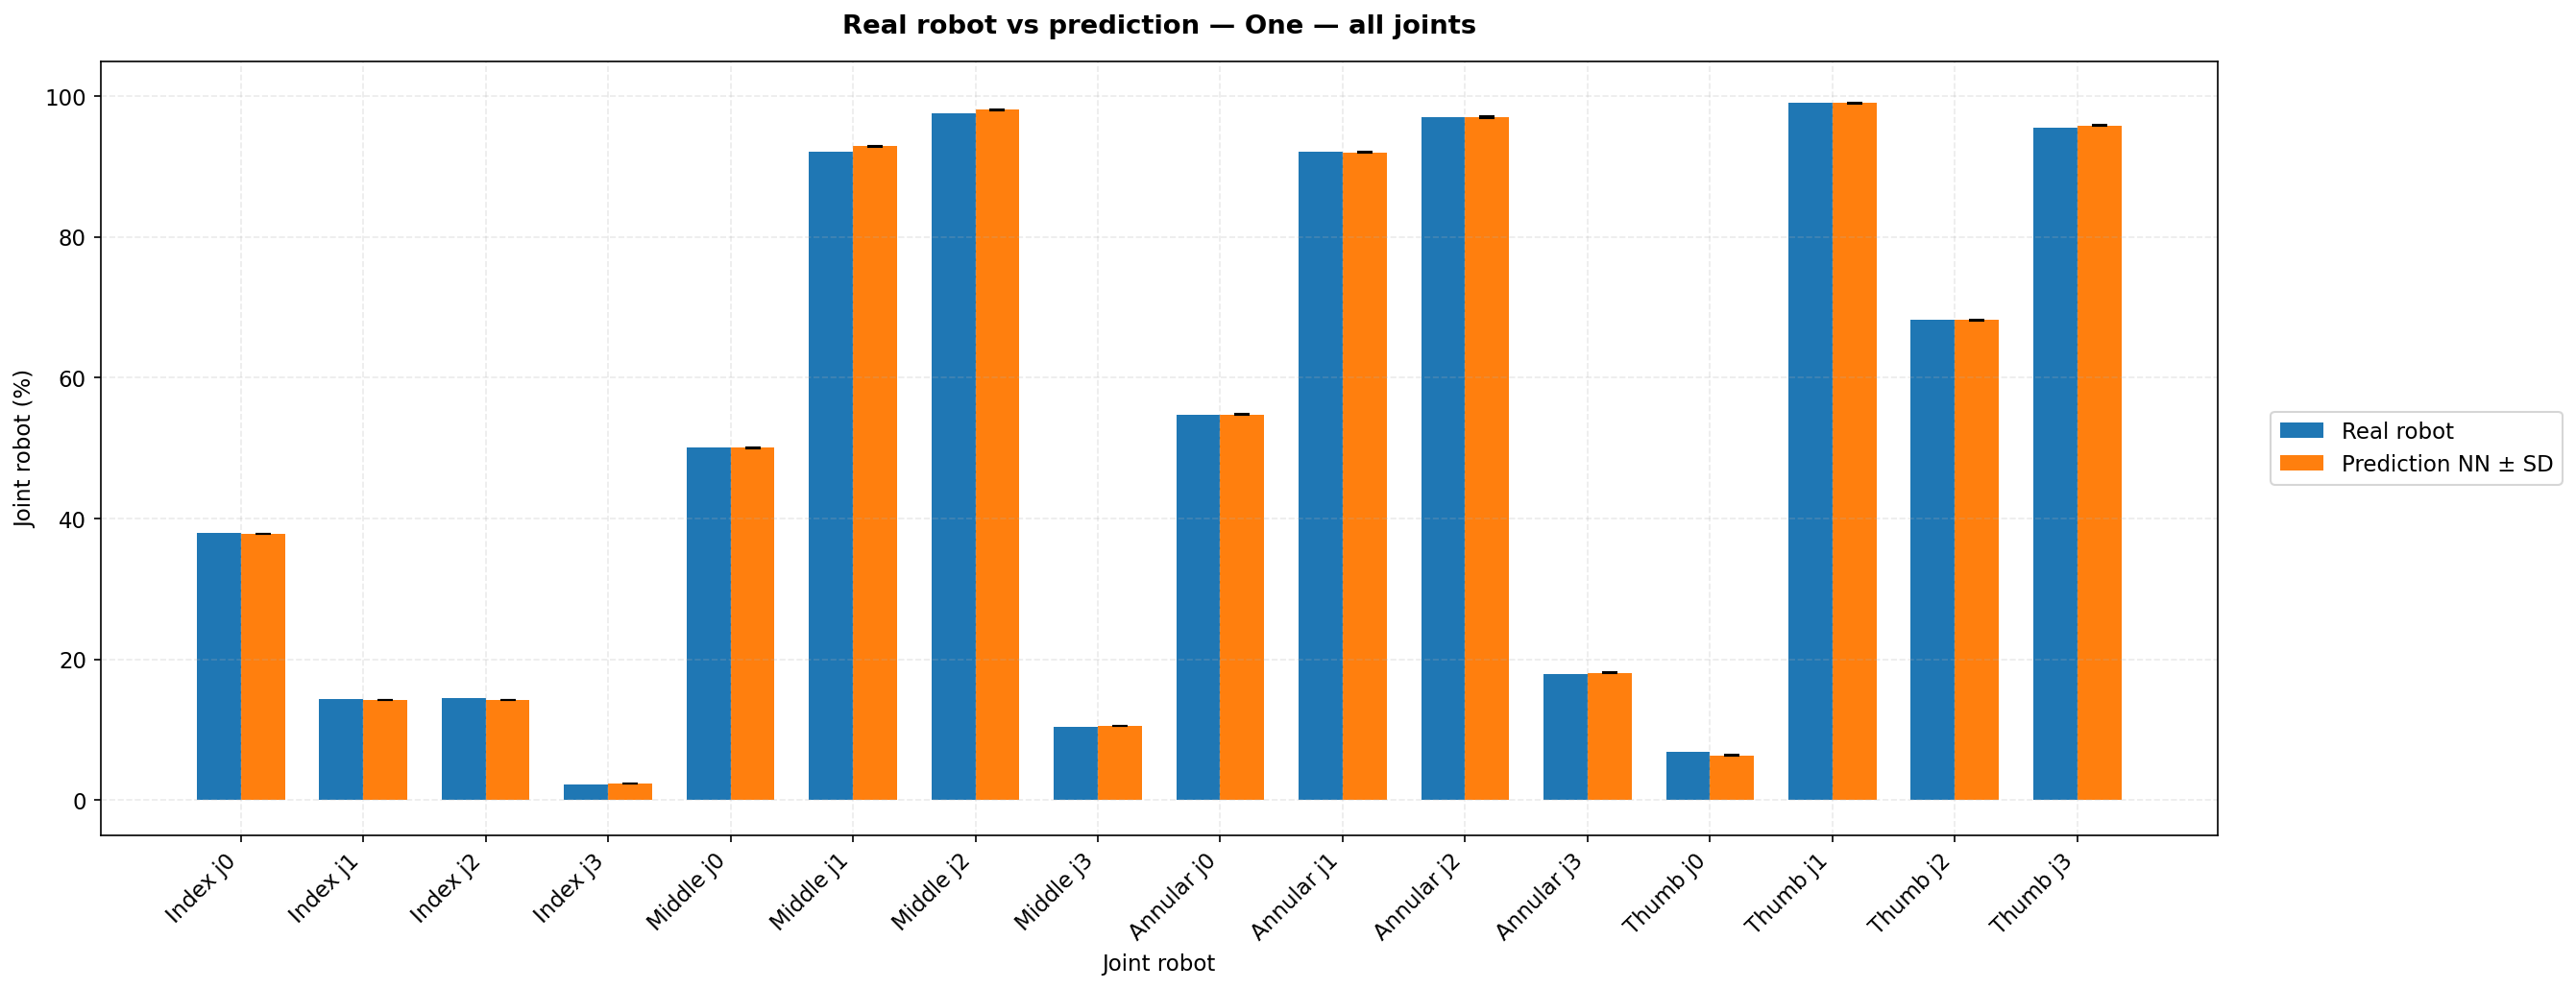

Generant resum tots els joints: PaperStat — Paper


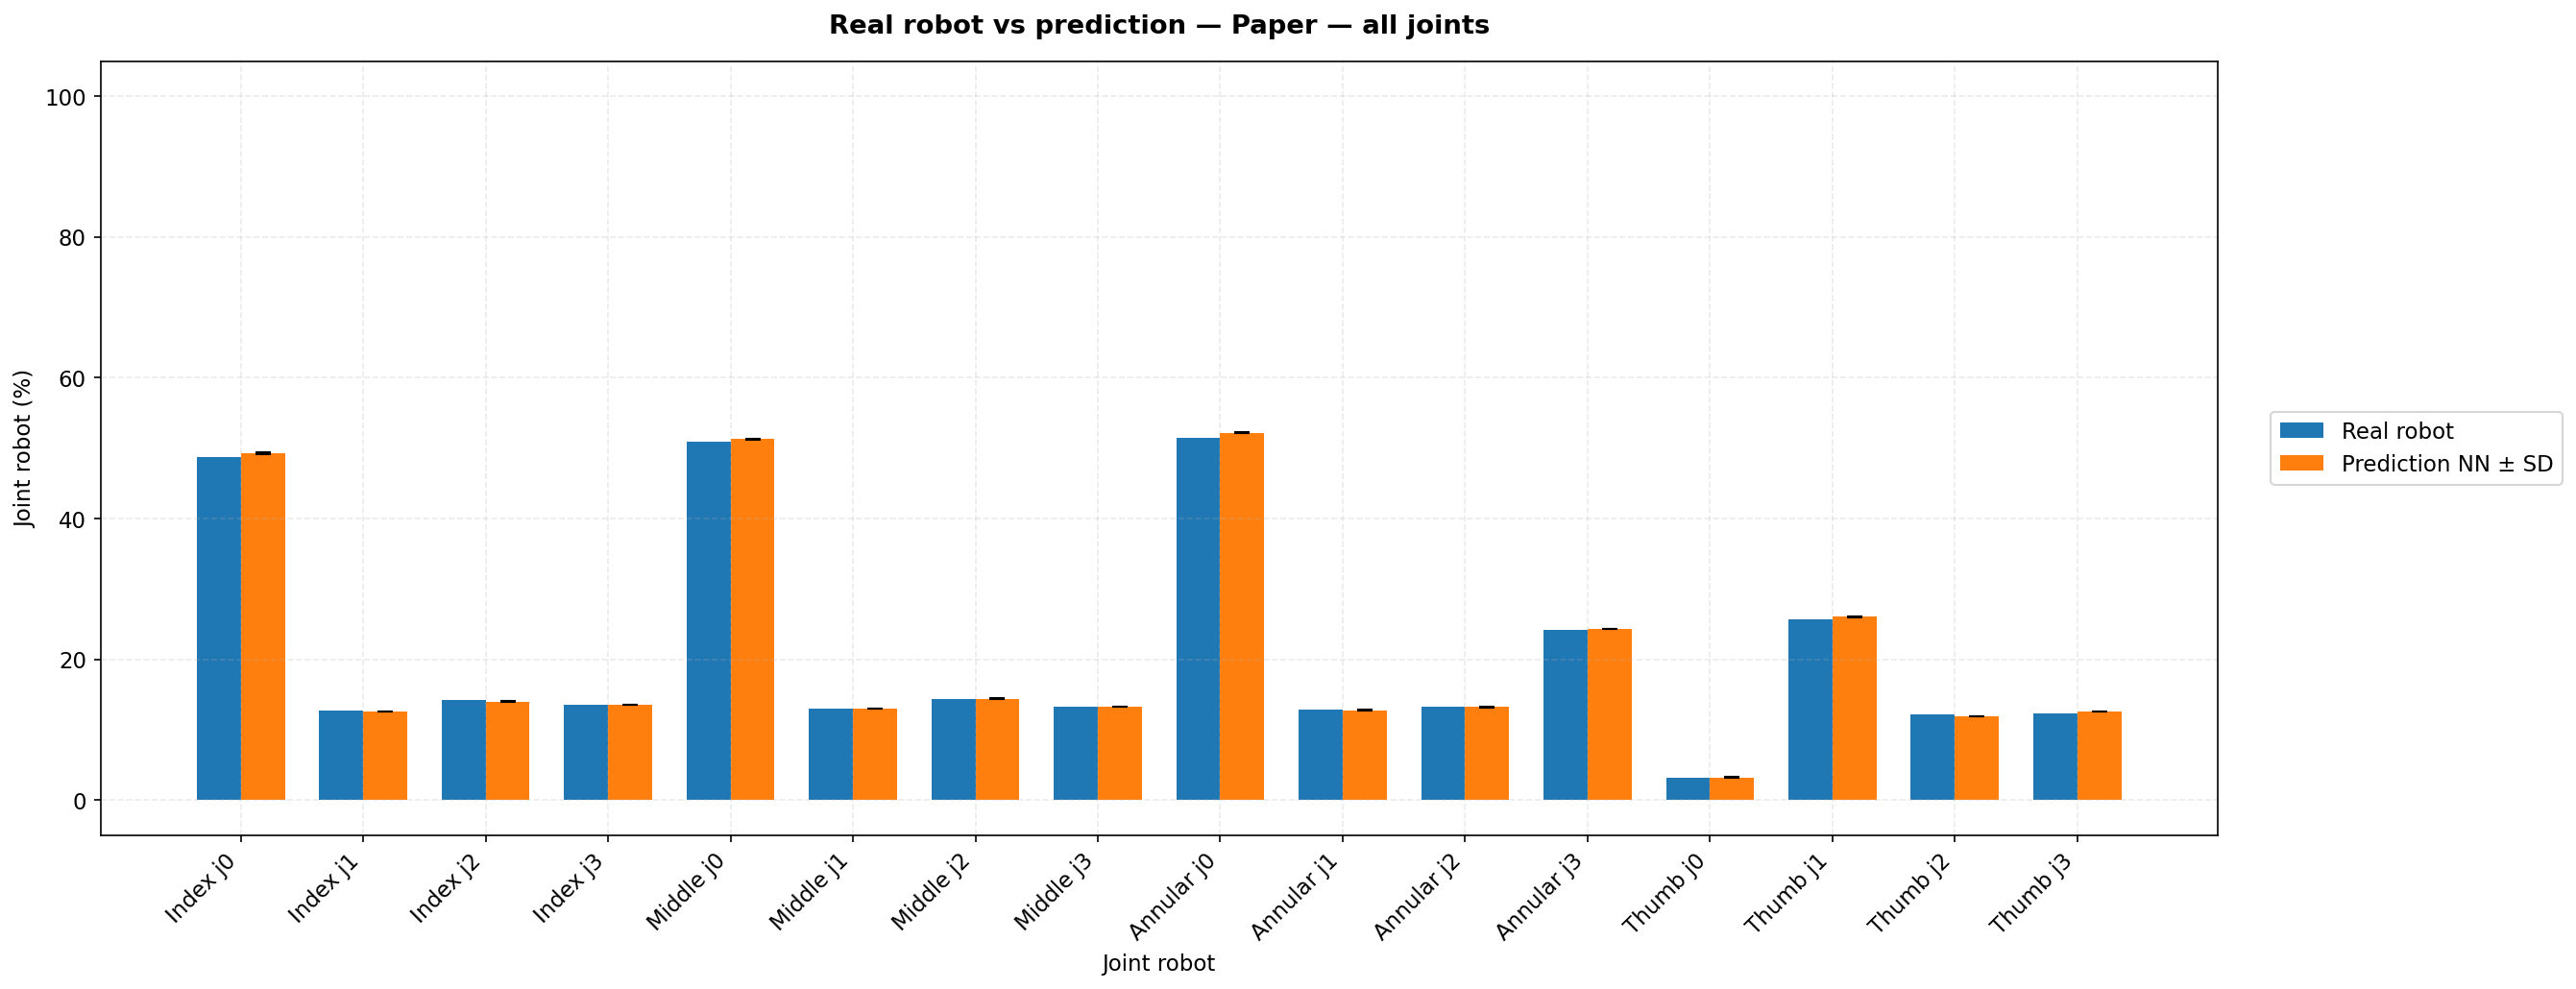

Generant resum tots els joints: RockStat — Rock


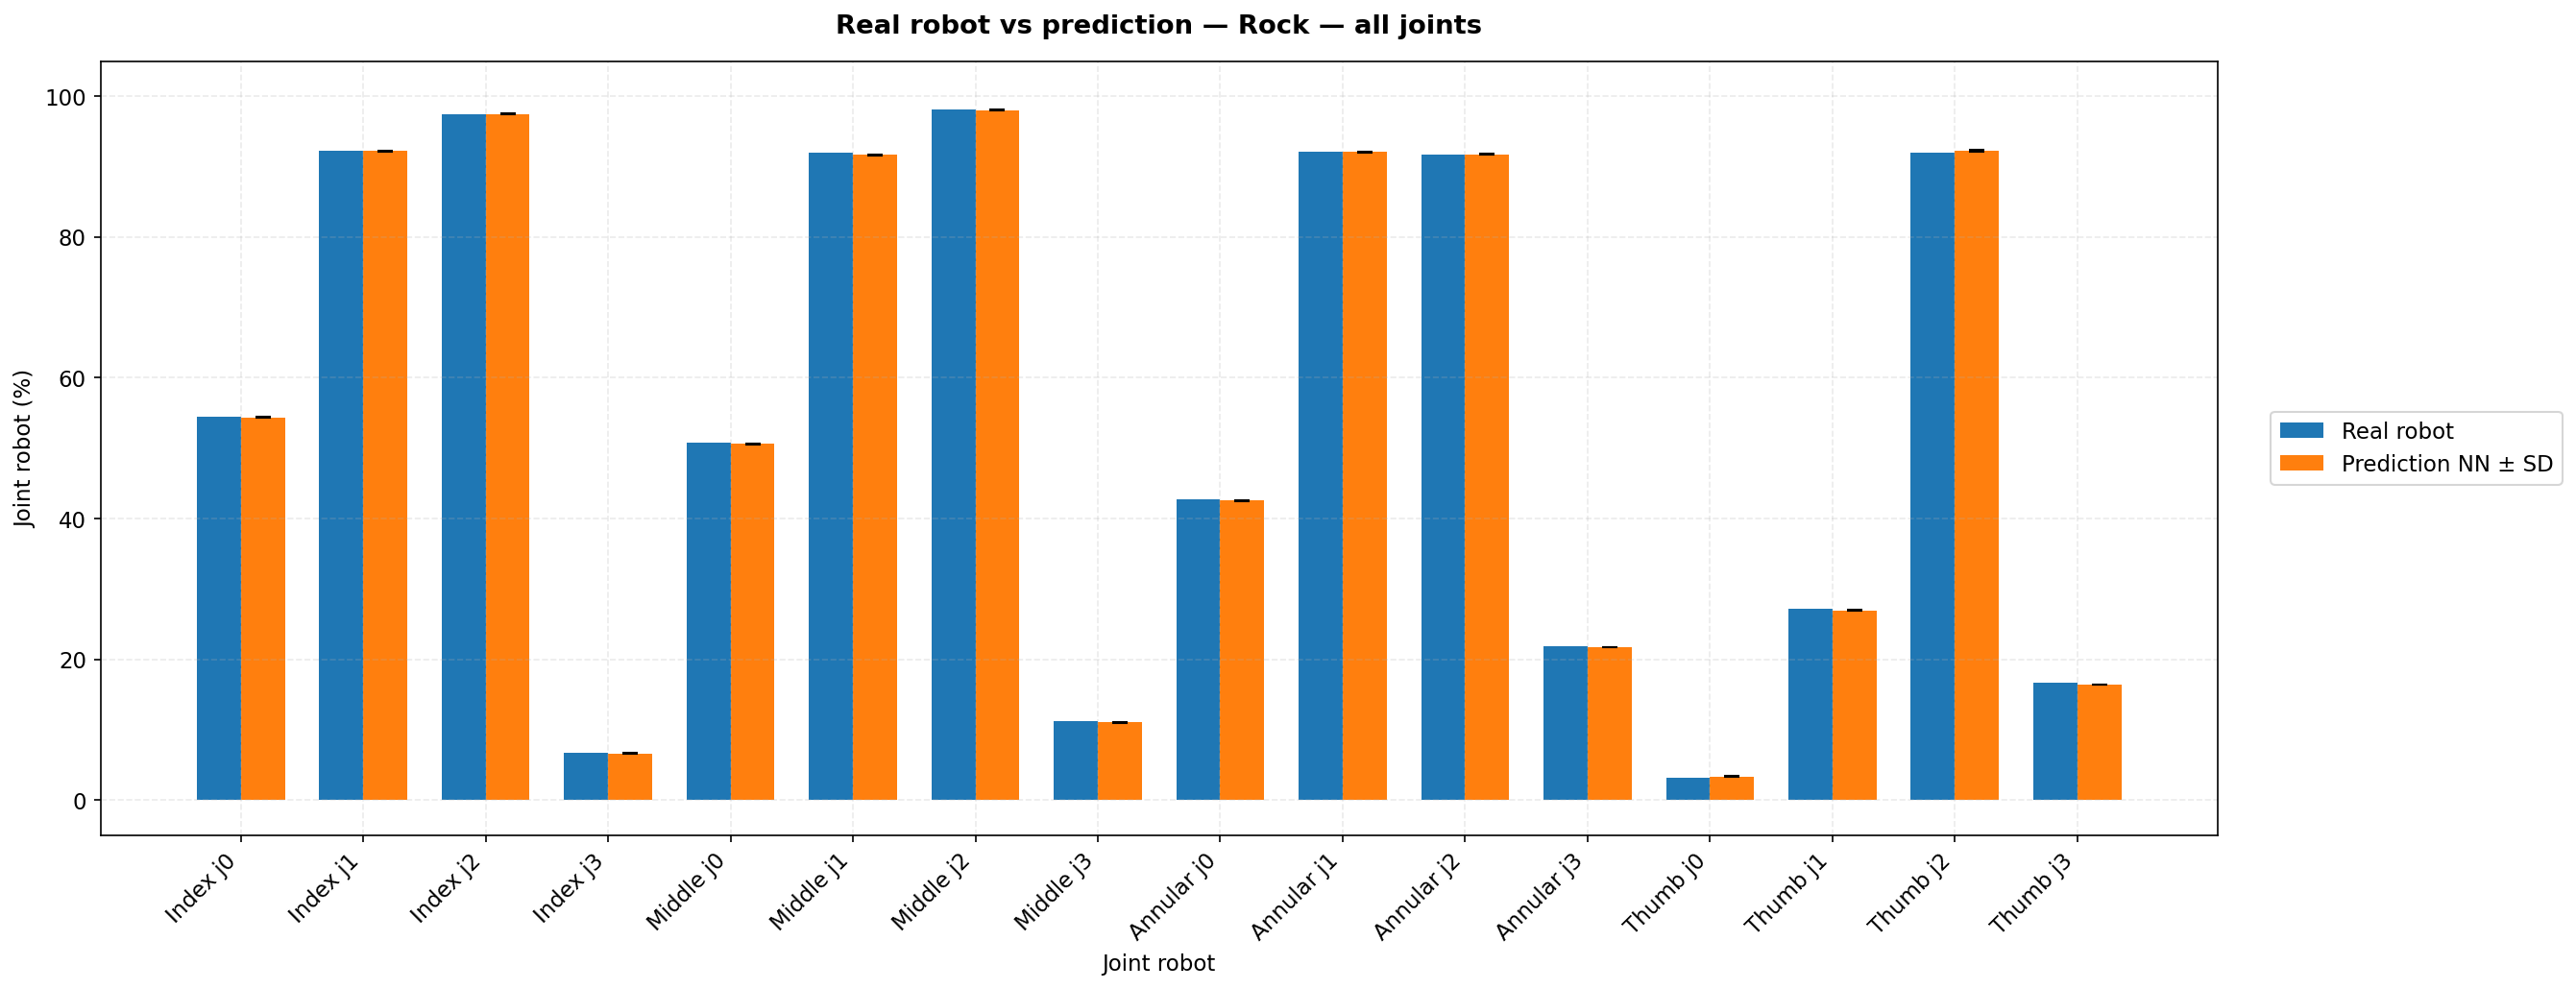

Generant resum tots els joints: ScisStat — Scissors


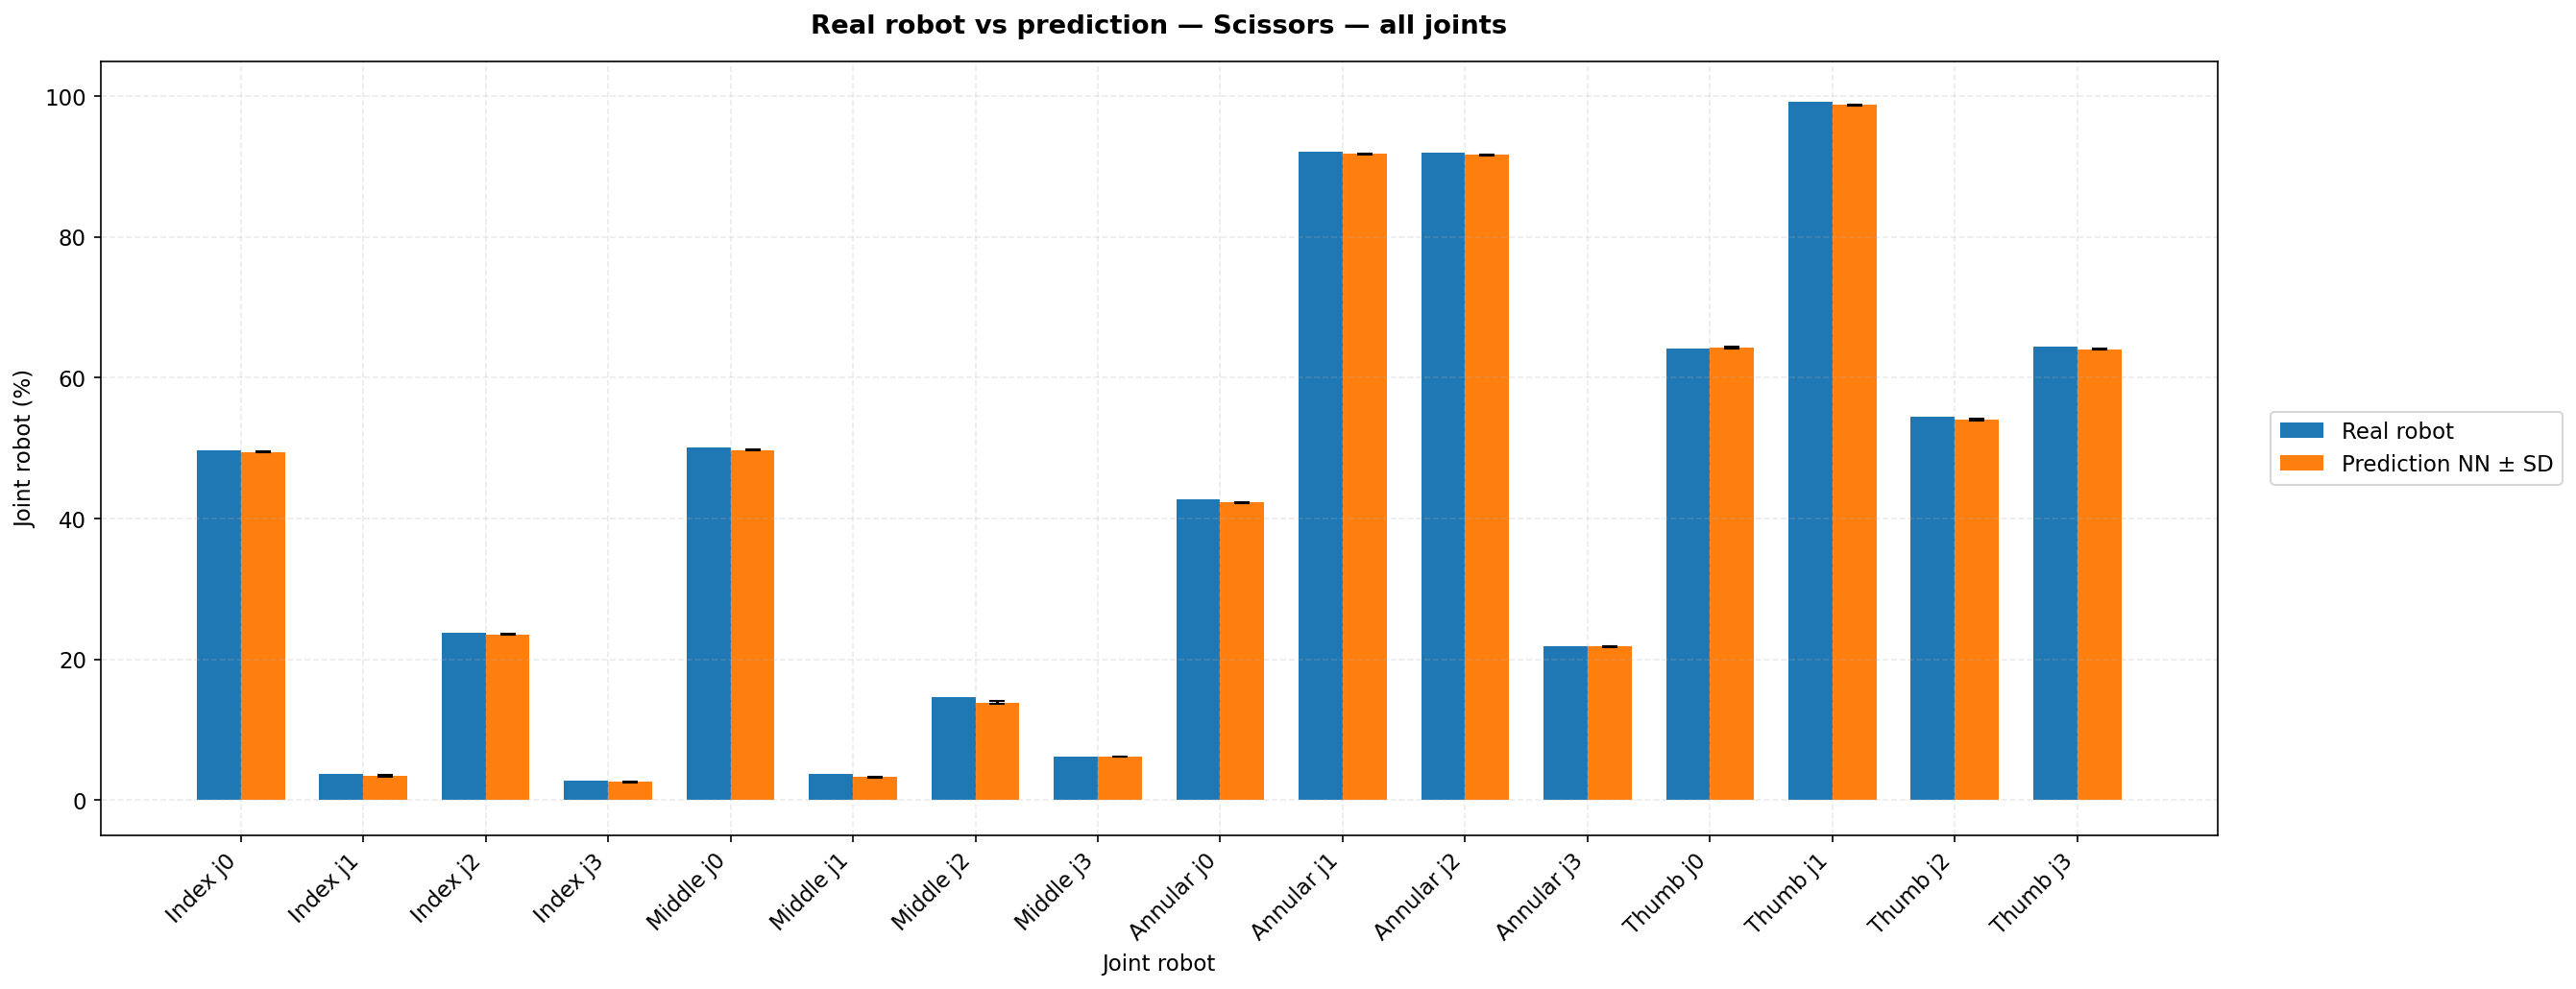

Generant resum tots els joints: ThumbUpStat — Thumb Up


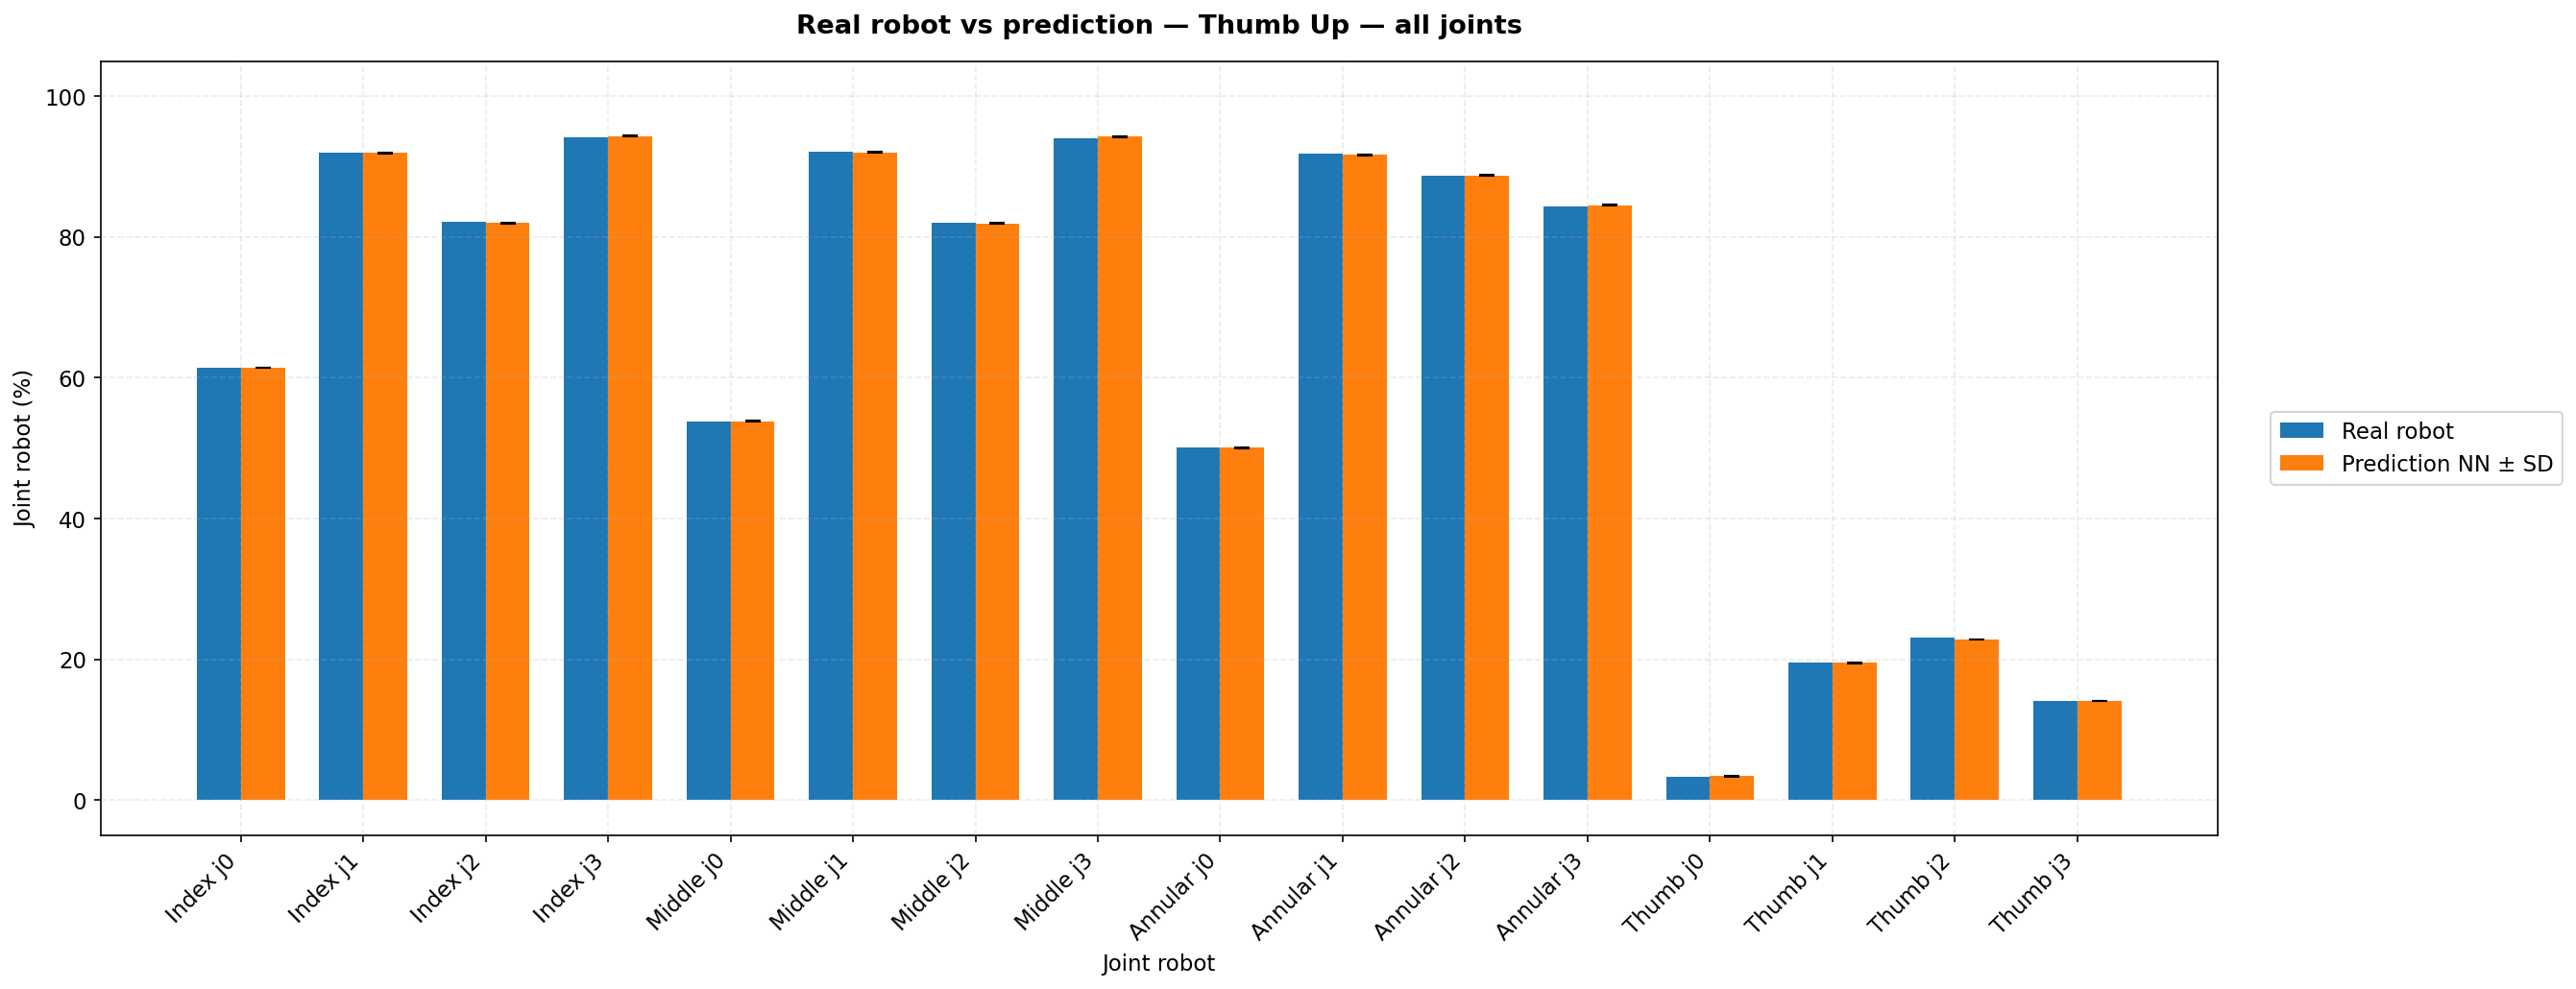

Figures resum amb tots els joints generades.


In [20]:

# ============================================================
# RESUM PER POSICIÓ AMB TOTS ELS JOINTS: REAL VS PREDICCIÓ
# ============================================================

def plot_all_joints_real_vs_prediction_by_position(pos):
    """
    Genera una figura resum per cada posició estàtica amb tots els joints del robot.
    Manté el mateix estil que els plots per grup, però agrupant els 16 joints en una sola figura.
    """

    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos / "summary_all_joints"
    pos_folder.mkdir(parents=True, exist_ok=True)

    subset = position_metrics_df[
        position_metrics_df["position_code"] == pos
    ].copy()

    if subset.empty:
        print(f"No hi ha dades per a {pos}")
        return

    subset["joint"] = pd.Categorical(
        subset["joint"],
        categories=robot_joint_order,
        ordered=True,
    )

    subset = subset.sort_values("joint")

    x = np.arange(len(subset))
    width = 0.36

    fig, ax = plt.subplots(
        figsize=(18, 7),
        dpi=150,
    )

    ax.bar(
        x - width / 2,
        subset["true_mean"],
        width,
        label="Real robot",
    )

    ax.bar(
        x + width / 2,
        subset["pred_mean"],
        width,
        yerr=subset["pred_std"],
        capsize=4,
        label="Prediction NN ± SD",
    )

    ax.set_title(
        f"Real robot vs prediction — {pos_name} — all joints",
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Joint robot")
    ax.set_ylabel("Joint robot (%)")
    ax.set_ylim(-5, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(
        subset["joint"],
        rotation=45,
        ha="right",
    )

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.25,
        linestyle="--",
    )

    fig.tight_layout()

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real_vs_prediction.png",
        bbox_inches="tight",
    )

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real_vs_prediction.pdf",
        bbox_inches="tight",
    )

    subset.to_csv(
        pos_folder / f"{pos}_all_joints_real_vs_prediction_metrics.csv",
        index=False,
    )

    plt.show()


# ============================================================
# GENERAR RESUMS DE TOTES LES POSICIONS
# ============================================================

for pos in sorted(position_metrics_df["position_code"].unique()):
    print(f"Generant resum tots els joints: {pos} — {static_position_names[pos]}")

    plot_all_joints_real_vs_prediction_by_position(pos)

print("Figures resum amb tots els joints generades.")


Generant resum tots els joints: BotiStat — Botifarra


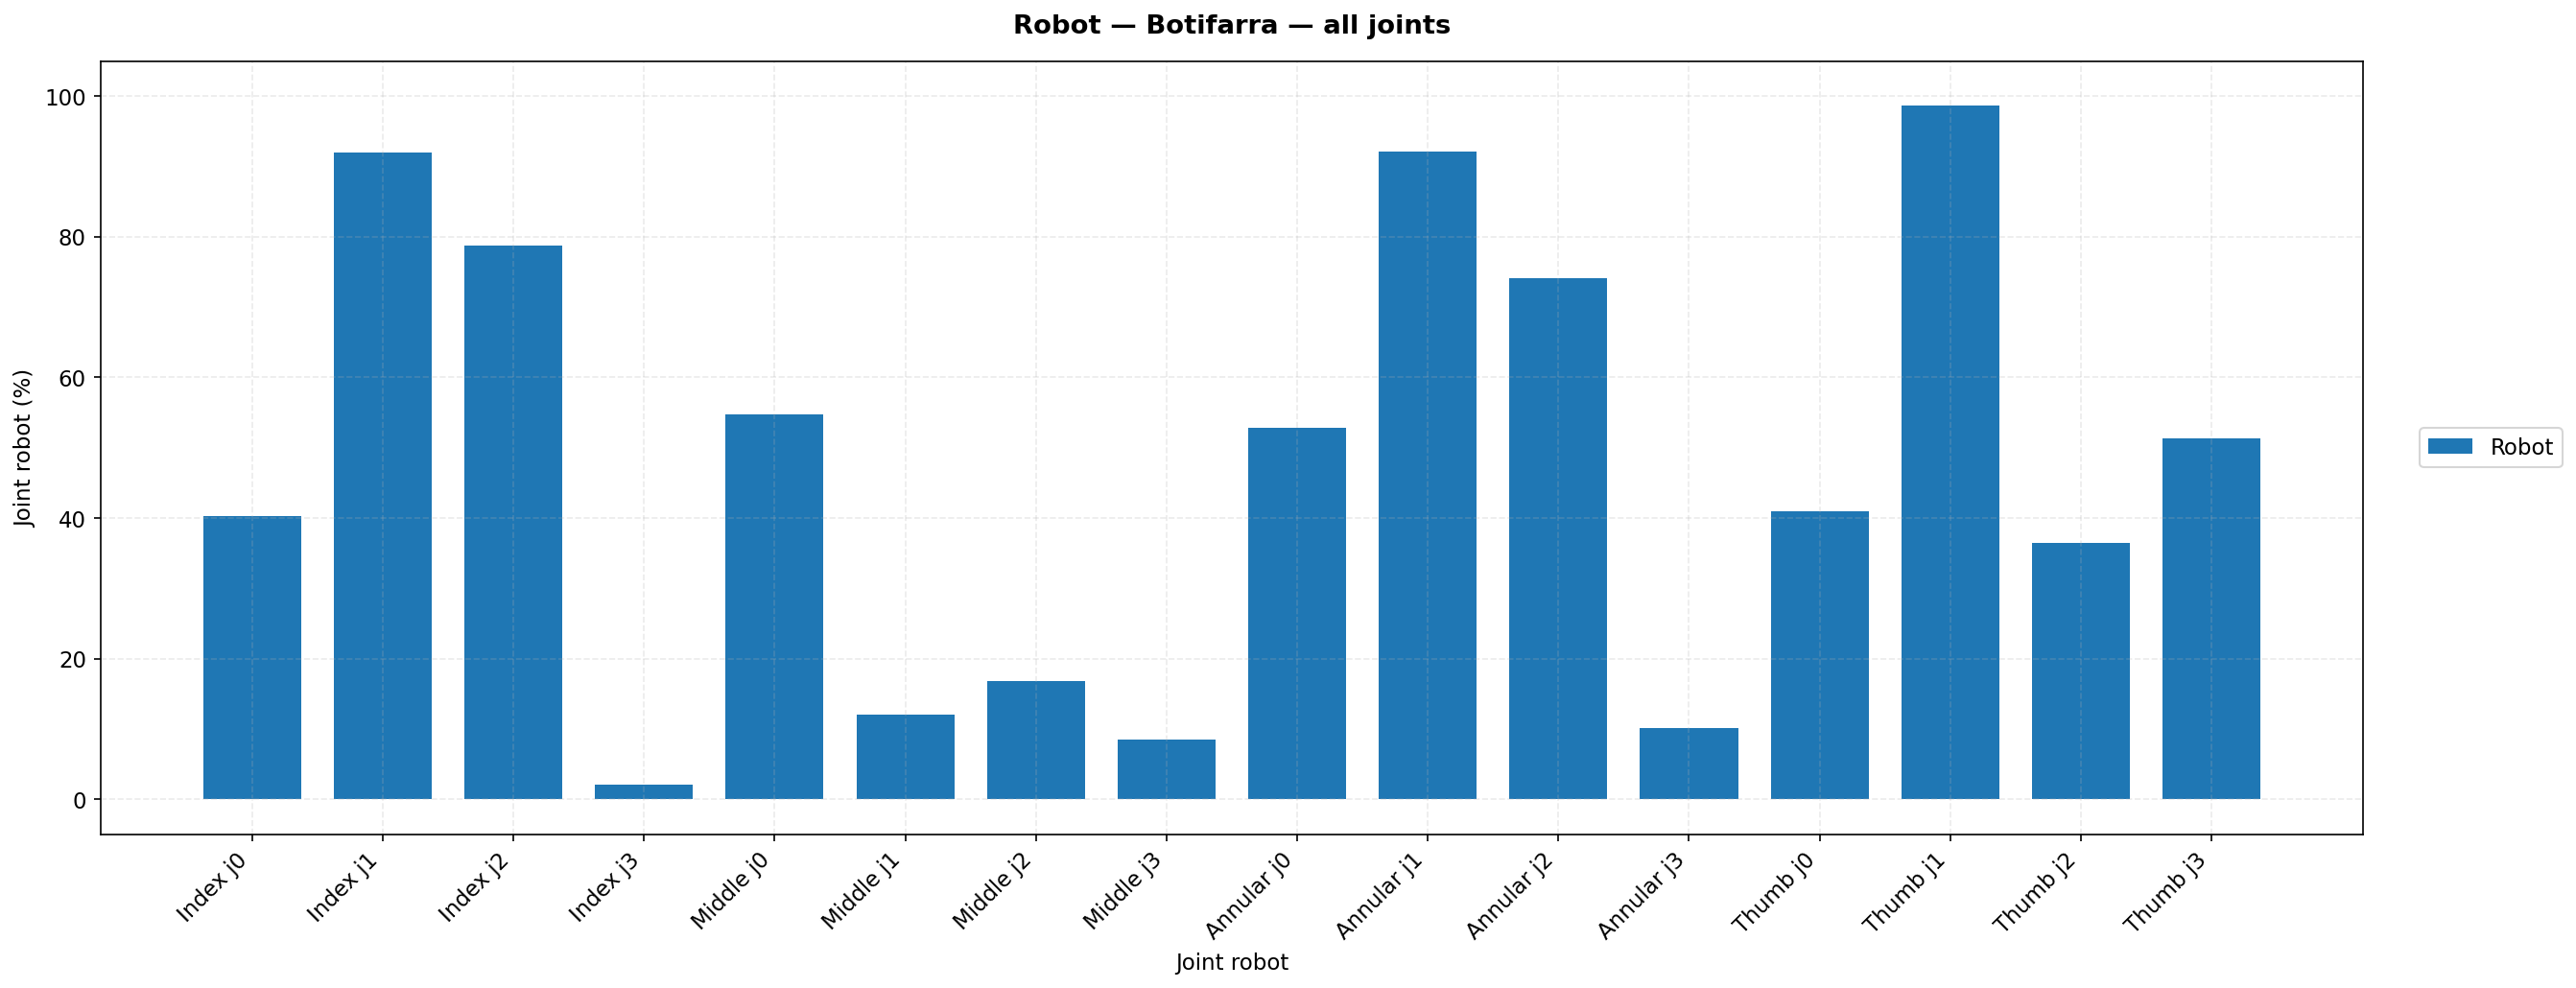

Generant resum tots els joints: OneStat — One


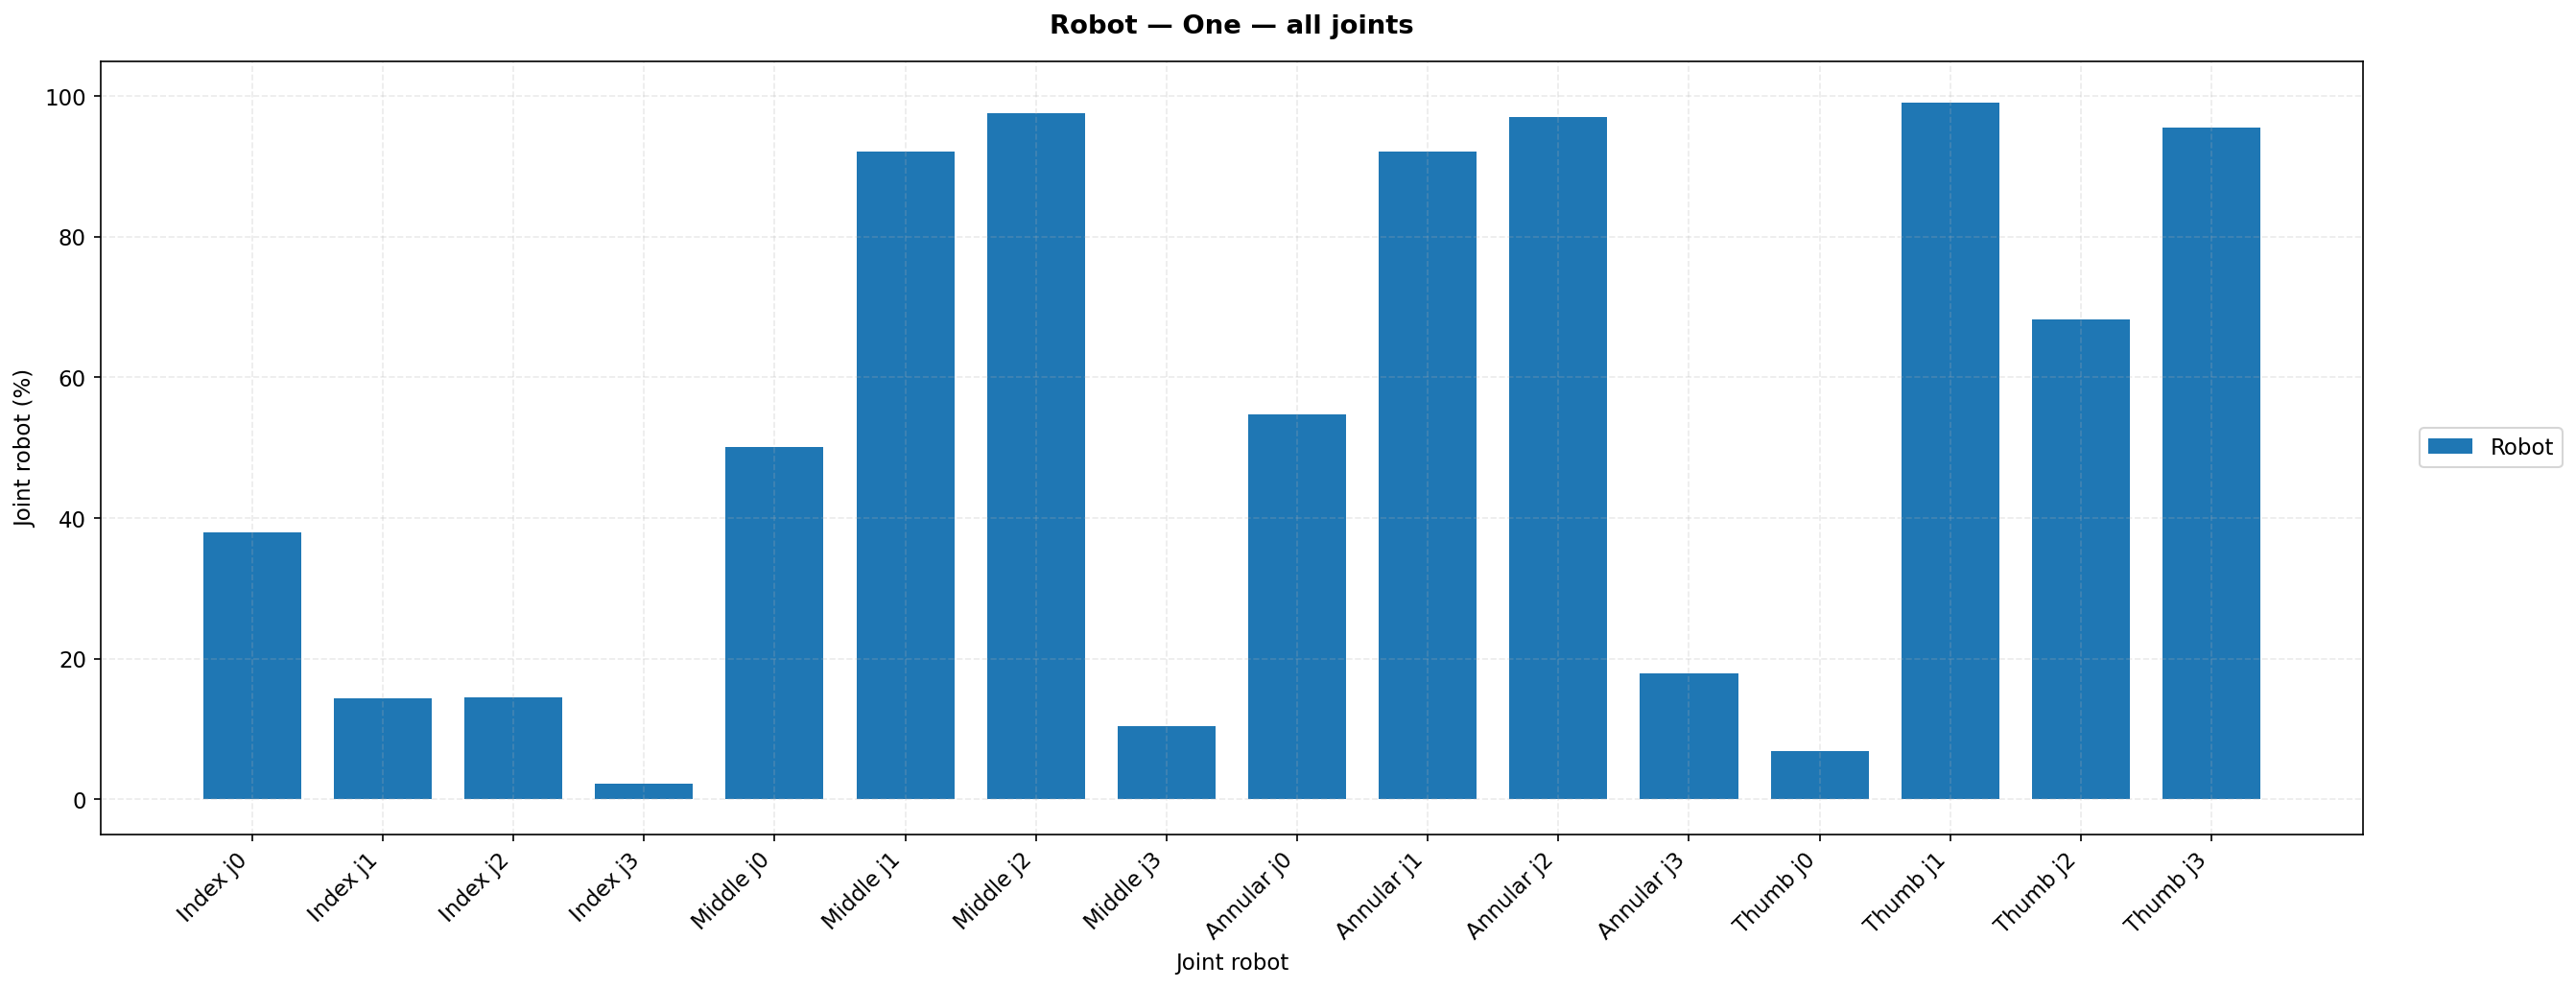

Generant resum tots els joints: PaperStat — Paper


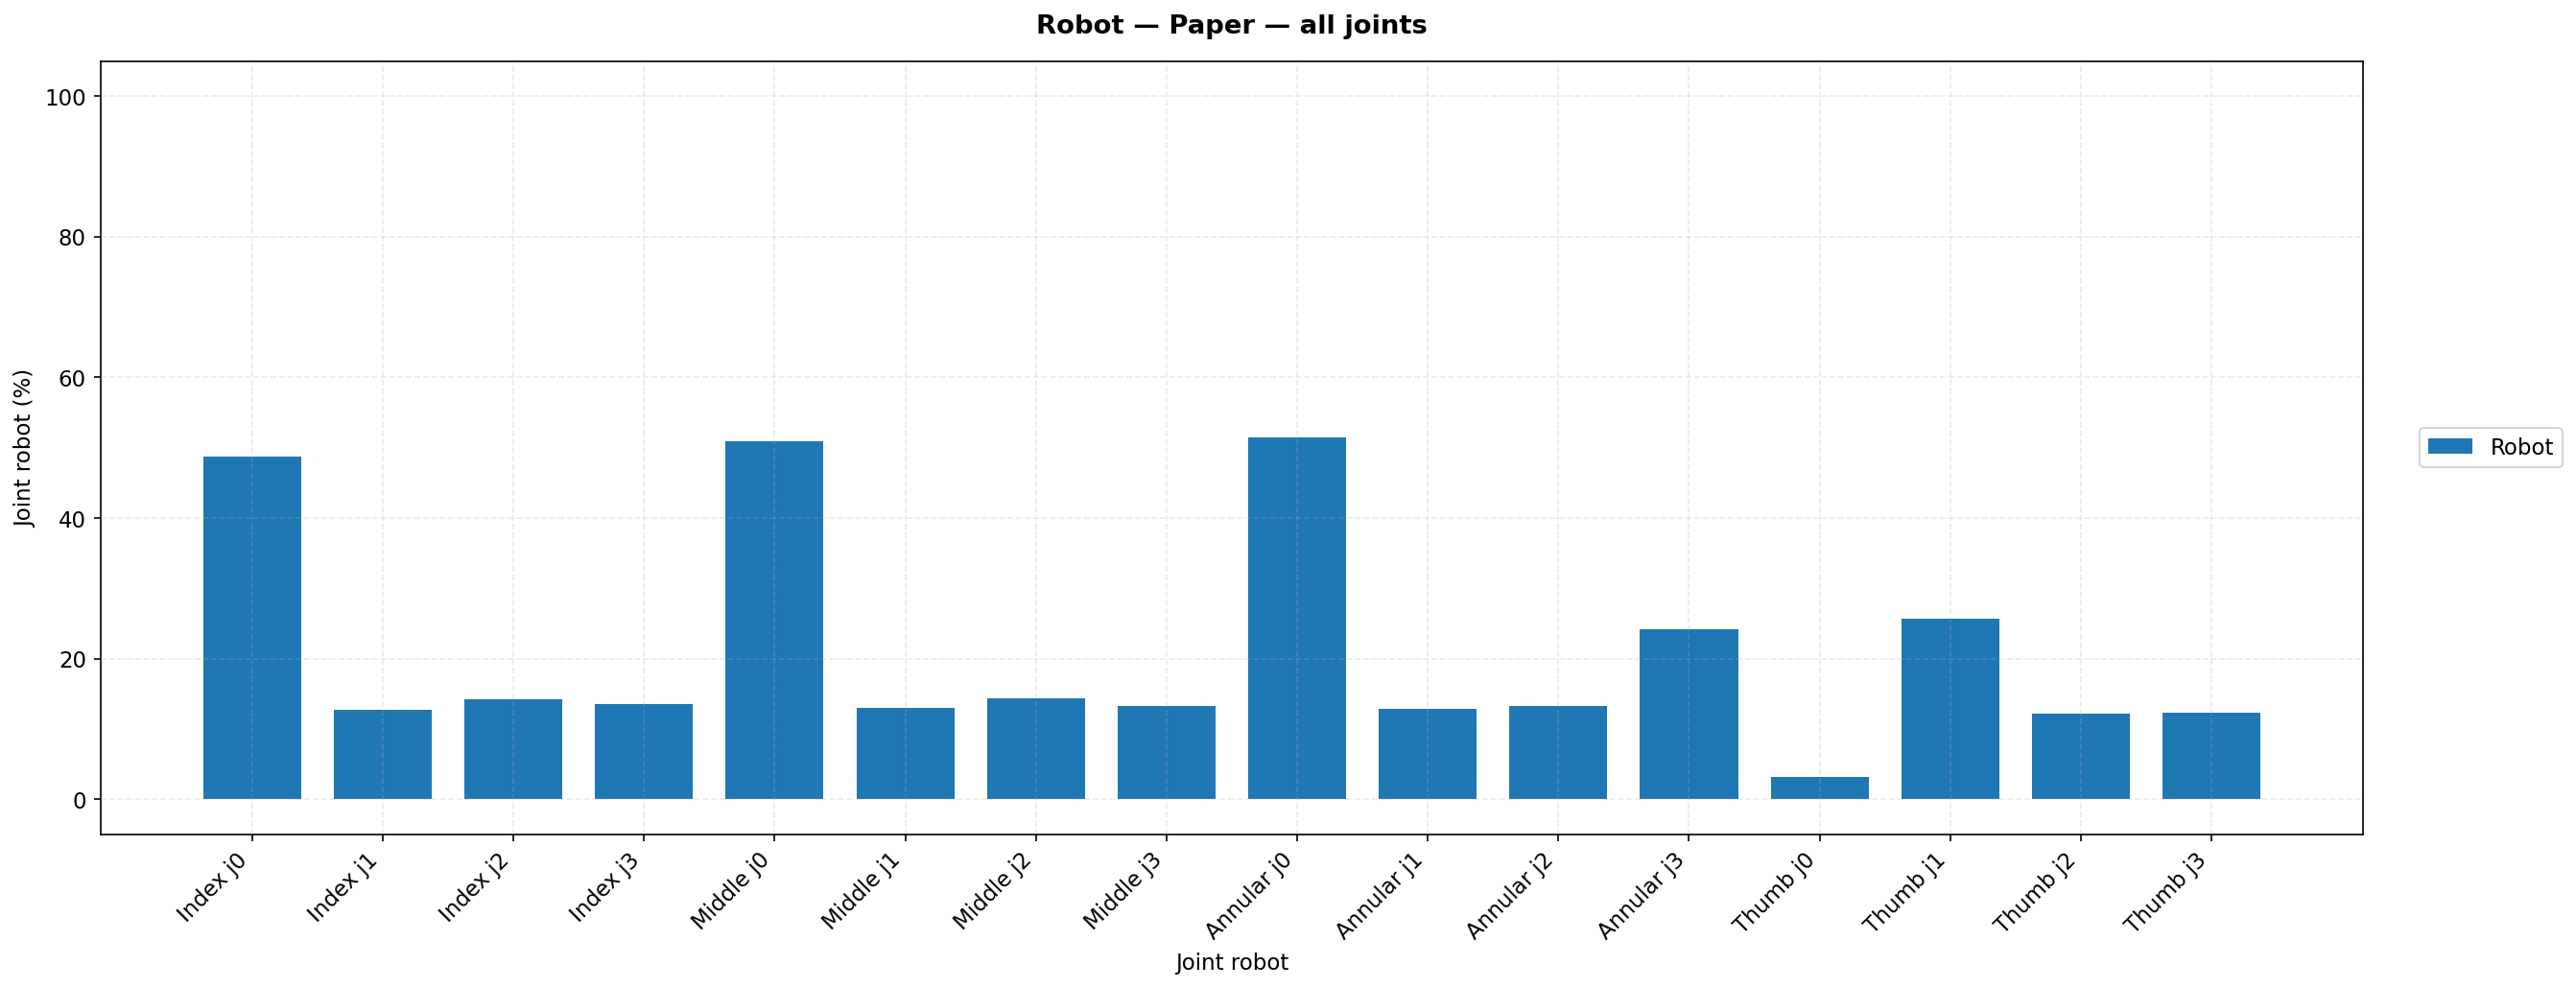

Generant resum tots els joints: RockStat — Rock


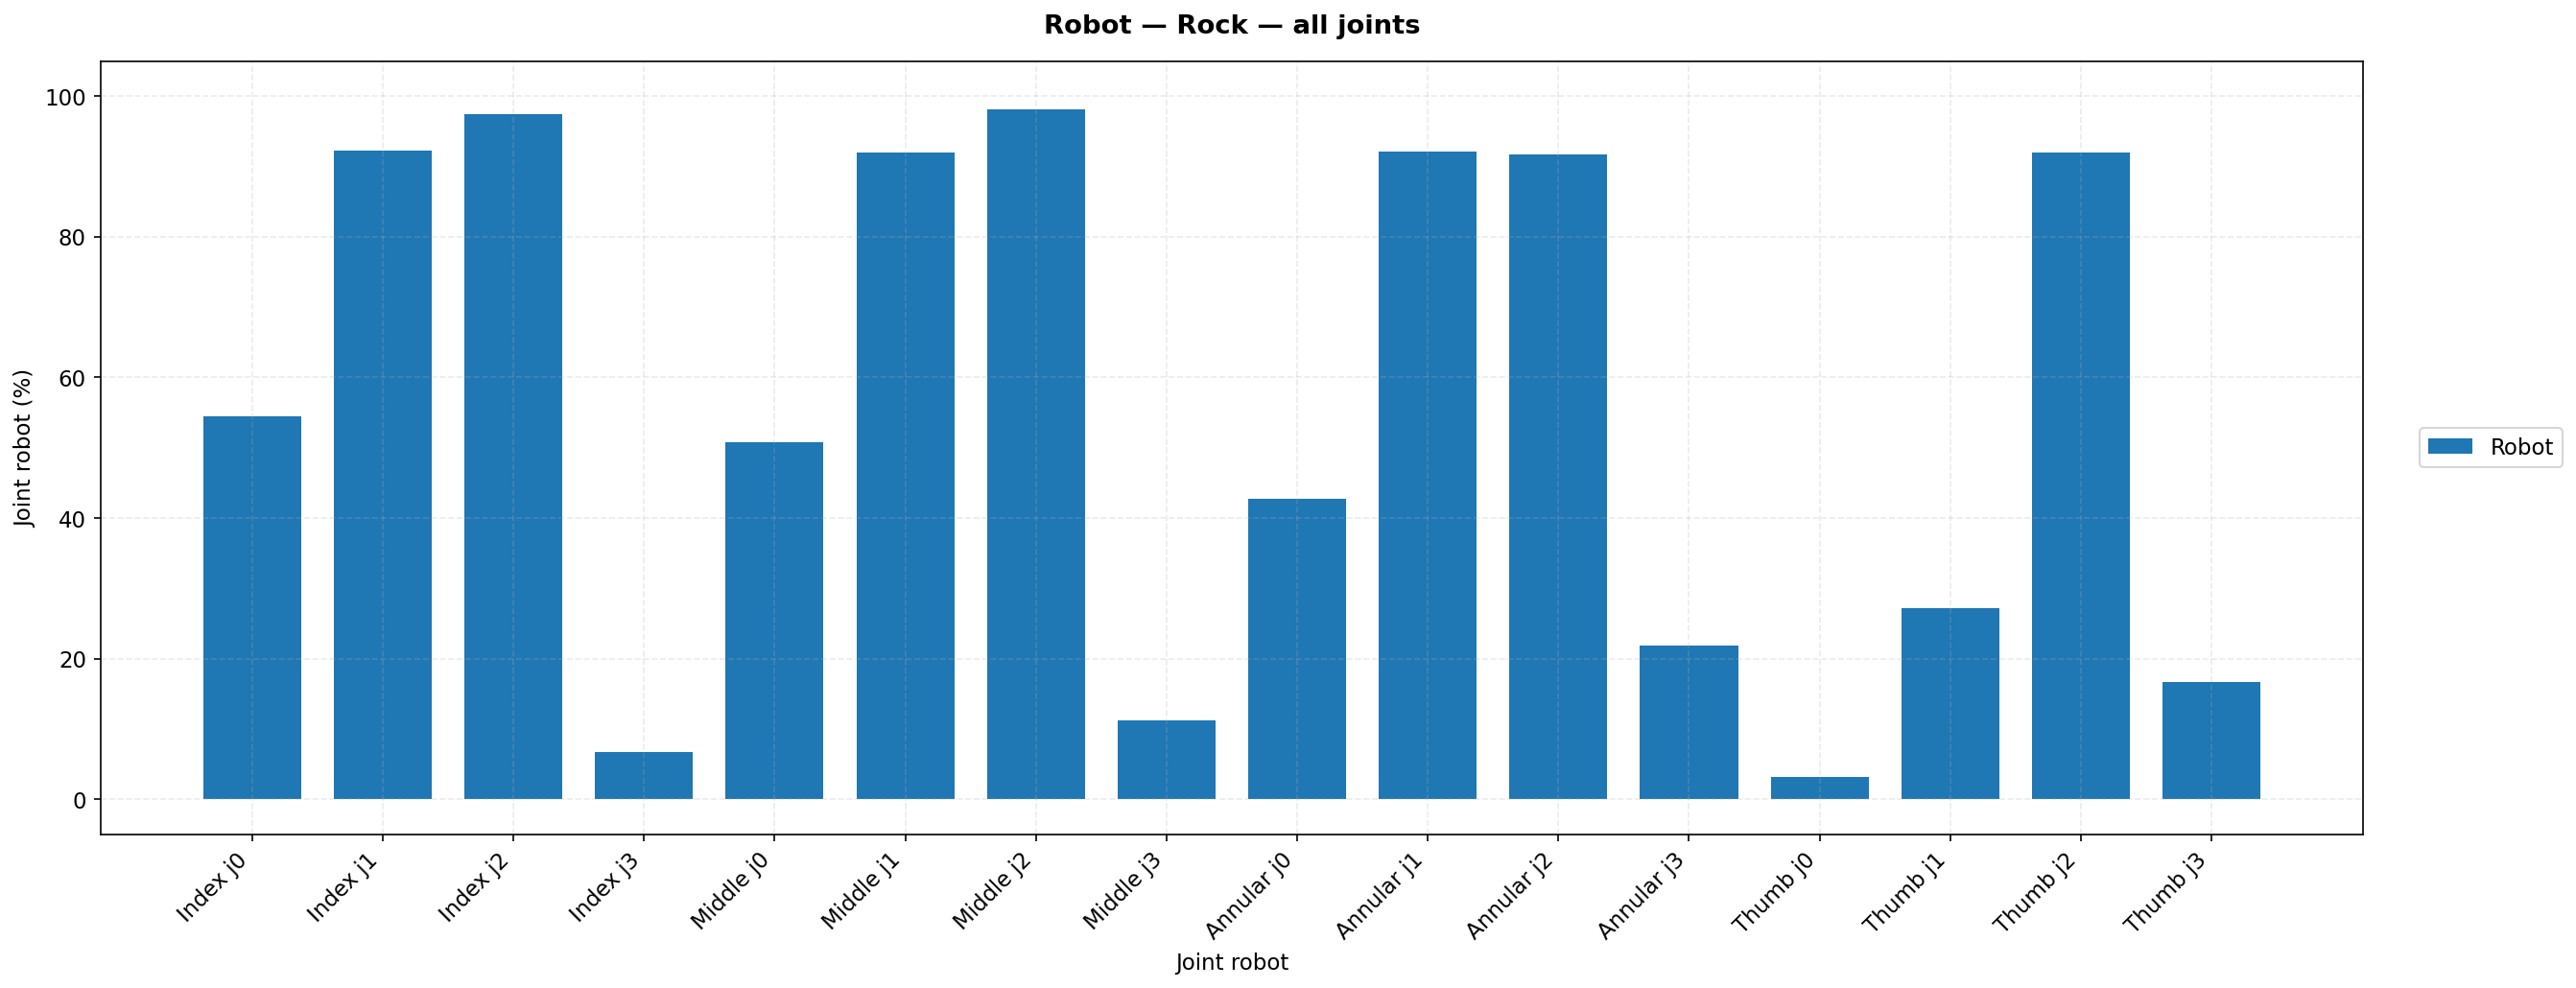

Generant resum tots els joints: ScisStat — Scissors


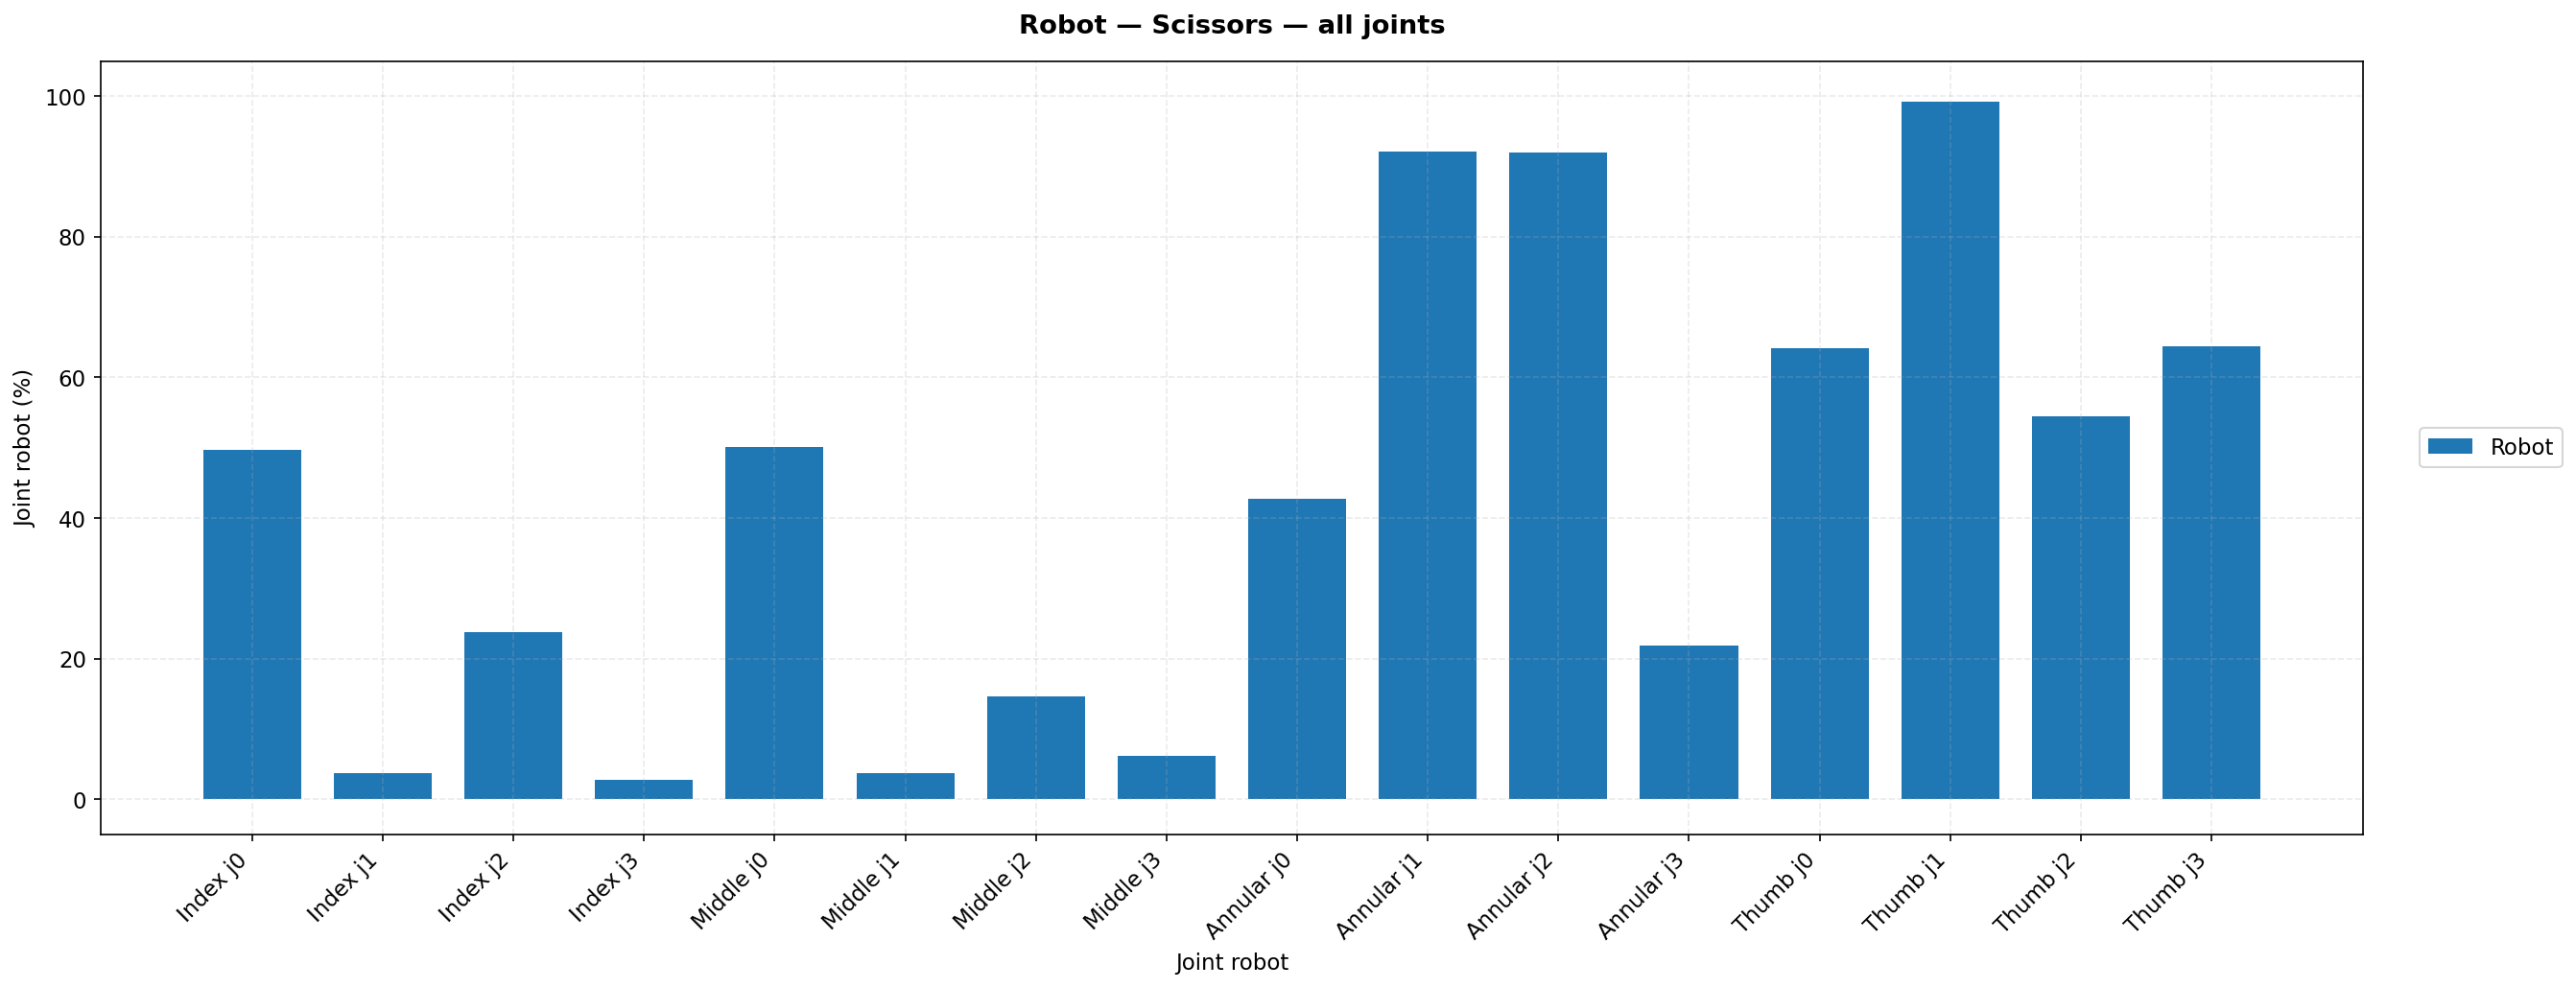

Generant resum tots els joints: ThumbUpStat — Thumb Up


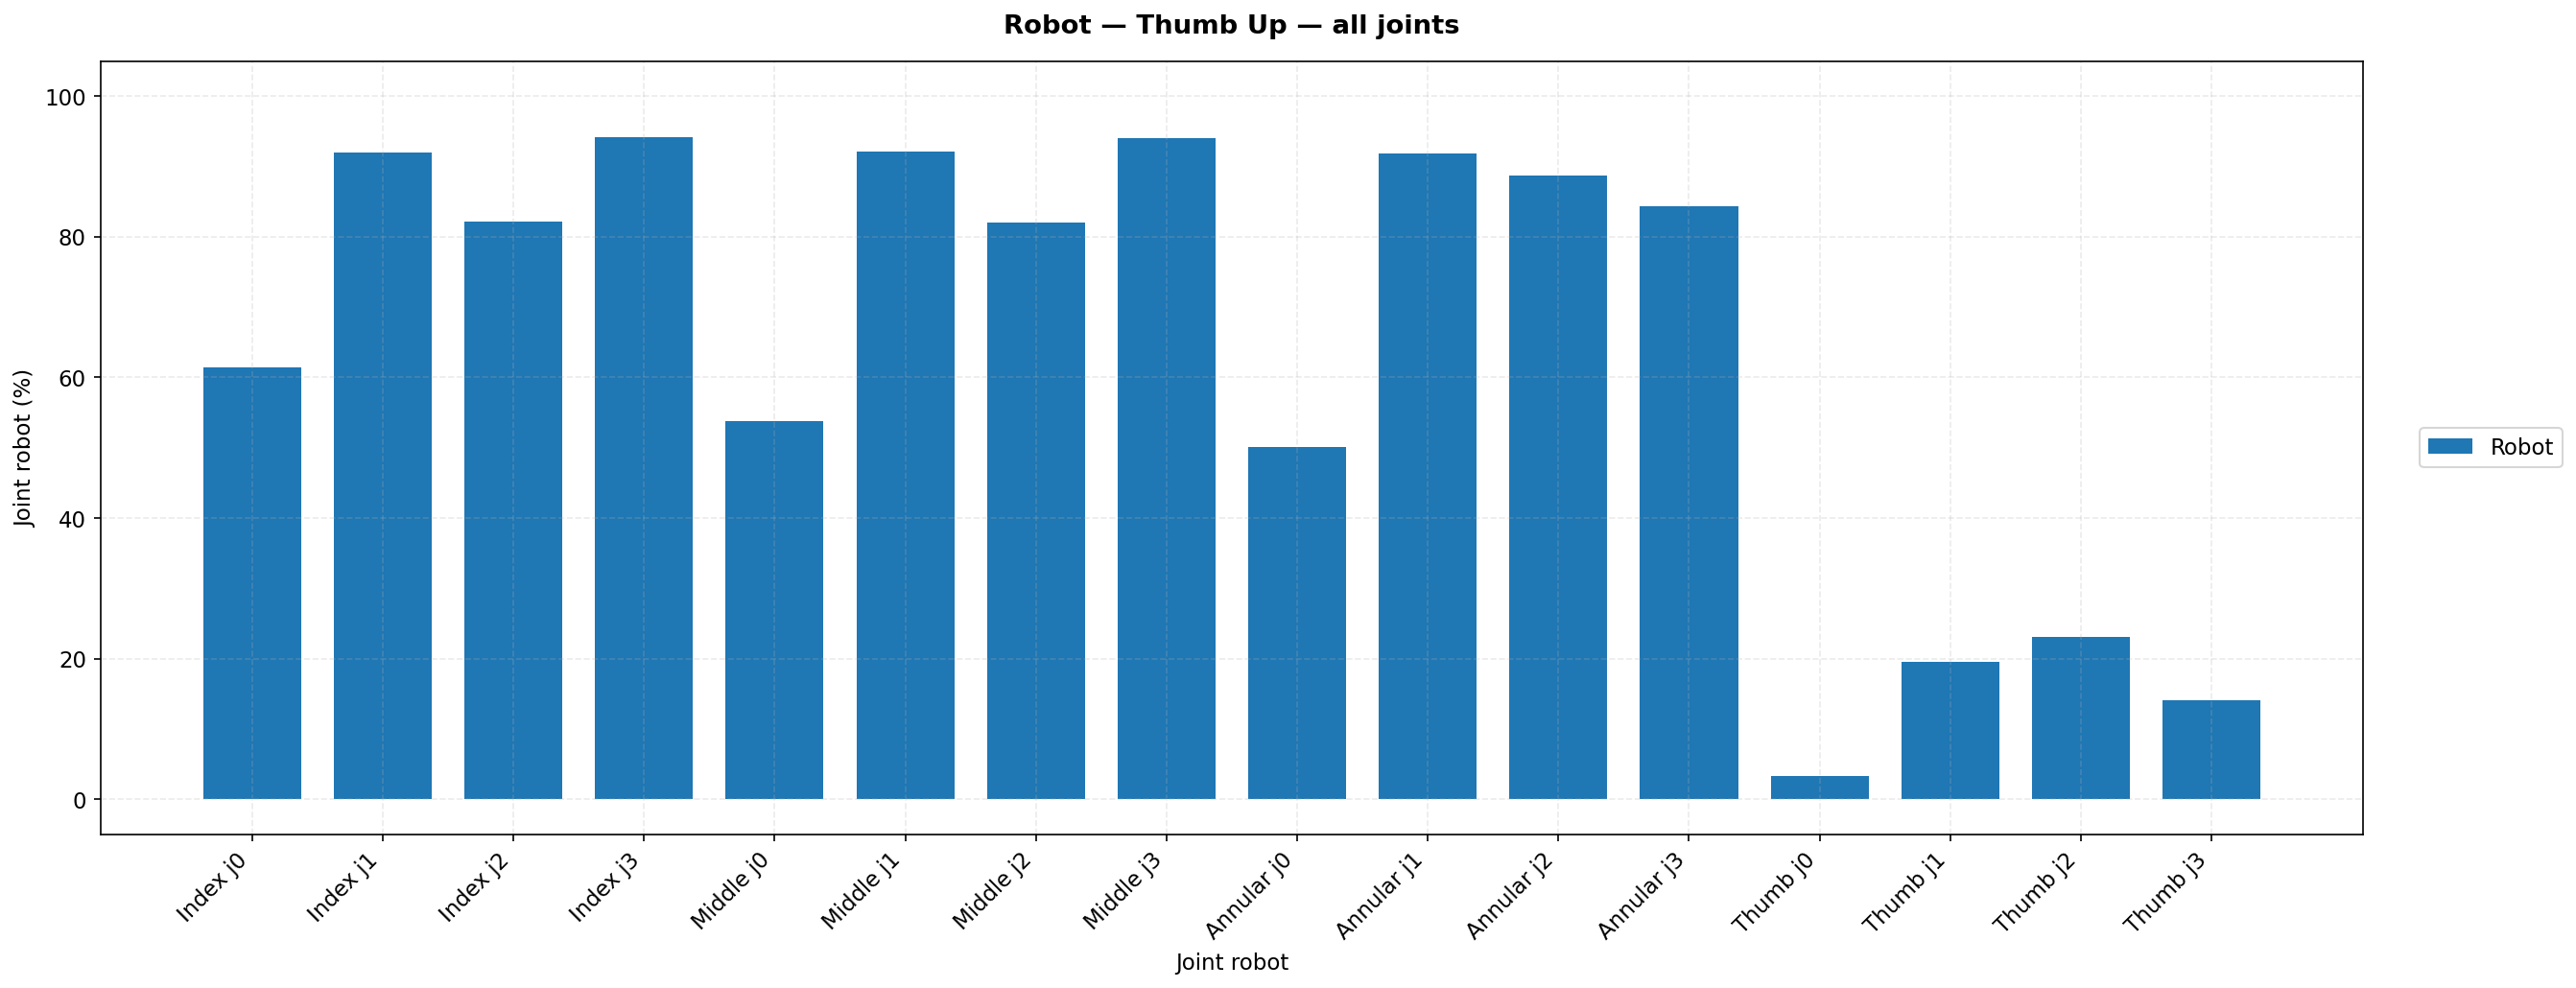

Figures resum amb tots els joints generades.


In [23]:

# ============================================================
# RESUM PER POSICIÓ AMB TOTS ELS JOINTS: REAL VS PREDICCIÓ
# ============================================================

def plot_all_joints_real_vs_prediction_by_position(pos):
    """
    Genera una figura resum per cada posició estàtica amb tots els joints del robot.
    Manté el mateix estil que els plots per grup, però agrupant els 16 joints en una sola figura.
    """

    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos / "summary_all_joints"
    pos_folder.mkdir(parents=True, exist_ok=True)

    subset = position_metrics_df[
        position_metrics_df["position_code"] == pos
    ].copy()

    if subset.empty:
        print(f"No hi ha dades per a {pos}")
        return

    subset["joint"] = pd.Categorical(
        subset["joint"],
        categories=robot_joint_order,
        ordered=True,
    )

    subset = subset.sort_values("joint")

    x = np.arange(len(subset))
    width = 0.75

    fig, ax = plt.subplots(
        figsize=(18, 7),
        dpi=150,
    )

    ax.bar(
        x,
        subset["true_mean"],
        width,
        label="Robot",
    )

    ax.set_title(
        f"Robot — {pos_name} — all joints",
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Joint robot")
    ax.set_ylabel("Joint robot (%)")
    ax.set_ylim(-5, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(
        subset["joint"],
        rotation=45,
        ha="right",
    )

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.25,
        linestyle="--",
    )

    fig.tight_layout()

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real.png",
        bbox_inches="tight",
    )

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real.pdf",
        bbox_inches="tight",
    )

    subset.to_csv(
        pos_folder / f"{pos}_all_joints_real_metrics.csv",
        index=False,
    )

    plt.show()


# ============================================================
# GENERAR RESUMS DE TOTES LES POSICIONS
# ============================================================

for pos in sorted(position_metrics_df["position_code"].unique()):
    print(f"Generant resum tots els joints: {pos} — {static_position_names[pos]}")

    plot_all_joints_real_vs_prediction_by_position(pos)

print("Figures resum amb tots els joints generades.")


In [24]:

# ============================================================
# DESCARREGAR RESULTATS DE COLAB EN ZIP
# ============================================================

import shutil
from pathlib import Path

zip_name = "resultats_estatic_glove_robot"

zip_path = shutil.make_archive(
    zip_name,
    "zip",
    output_dir,
)

print("ZIP creat:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("No s'ha pogut iniciar la descàrrega automàtica.")
    print("Pots descarregar manualment aquest fitxer:")
    print(zip_path)
    print("Error:", e)


ZIP creat: /content/resultats_estatic_glove_robot.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Nota important

Aquest model pot donar errors molt baixos perquè totes les mostres d’una mateixa postura tenen el mateix vector objectiu del robot.  
Per validar generalització real, el següent pas seria fer **leave-one-position-out**: entrenar amb 5 postures i provar amb la postura que queda fora.
